# Week 2：ESP32-S3 開發環境與數位輸入輸出實驗

日期：2026-09-16

本章以ESP32-S3開發板為實驗平台，依序完成開發環境設定、程式編譯與上傳、
Serial Monitor判讀、麵包板與按鈕通斷量測、GPIO按鈕輸入，以及按鈕去抖實驗。
所有外部接線都先在斷電狀態完成並檢查，確認後才接回USB。

**完整備課版（含參考答案）**：第10.7～10.10節集中放置Discussion與課中判讀的
預期回答。先保留自己的預測、原始log及答案，再閱讀解析；示意數據不能填成實測紀錄。
本版依教師要求包含完整解答，不是無答案學生版。


## 一、單元概覽

### 教學目標

完成本單元後，學生應能：

1. 辨認開發板的USB接頭、電源與訊號腳位，以及啟動、重設按鈕。
2. 使用Arduino IDE完成編譯與上傳，從序列監控視窗（Serial Monitor）確認程式版本與輸出。
3. 在斷電狀態使用萬用電表，判斷麵包板哪些孔相通，以及按鈕按下、放開的差異。
4. 完成內部上拉（`INPUT_PULLUP`）按鈕線路，解釋輸入讀值與輸出命令的關係。
5. 解釋按鈕去抖（debounce），追蹤判斷流程，並以紀錄比較不同等待時間的效果。

### 教學內容

本單元先完成開發環境設定與程式上傳，再透過序列紀錄確認板子正在執行哪一版程式。
接著以電表、麵包板與按鈕理解接線，建立按下與放開能產生不同輸入的線路。
最後觀察一次按壓可能出現的多次變化，學習如何用去抖程式接受穩定狀態，
並區分程式回報、實際量測與尚未確認的結果。

### 核心實驗流程

| 階段 | 開始狀態 | 實驗內容 | 完成條件 |
|---:|---|---|---|
| 1 | 板子未接USB | [安裝環境與辨認板卡](#w2-install) | 找到COM USB、BOOT、RST、GPIO與GND |
| 2 | 只接USB | [Board、Port、Verify、Upload與Serial](#w2-settings) | log顯示自己的組別與`version=2` |
| 3 | USB已拔除 | [麵包板、按鈕與萬用電表通斷](#w2-meter) | 能解釋同列、跨槽、按下與放開結果 |
| 4 | USB仍拔除 | [依課程profile完成GPIO與GND接線](#w2-wiring) | 逐線檢查且TPO與TPG沒有低阻抗短接 |
| 5 | 接線檢查完成 | [按鈕輸入與測試輸出命令](#w2-gpio) | 五次按下／放開事件依序正確 |
| 6 | 前五階段完成 | [按鈕去抖Discussion](#w2-discussion) | 能區分raw／stable並用資料比較四種設定 |

各階段依序完成。結果不符時先執行該節的第一個安全檢查，不同時改動多個設定。

### 章節定位

[器材](#w2-materials)｜[安全](#w2-safety)｜[安裝與板卡](#w2-install)｜[Board與Port](#w2-settings)｜[第一支程式與Serial](#w2-serial)

[電表與電學例子](#w2-meter)｜[麵包板與按鈕](#w2-breadboard)｜[GPIO實驗](#w2-gpio)｜[去抖Discussion](#w2-discussion)

[Discussion參考答案](#w2-answers)｜[紀錄](#w2-records)｜[完成與復原](#w2-finish)｜[上拉與發熱補充](#w2-further)｜[板卡參數補充](#w2-board-details)

第一次閱讀依上方流程逐段完成；章節連結供中斷後回到所在位置。紙上範例是解釋，
不是新增接線指令；先做自己的預測與紀錄，再核對Discussion答案。


<a id="w2-materials"></a>

## 二、實驗器材與分組

每組1～3人，每組必須有一台萬用電表。1人組可以向其他組共用萬用電表，但
程式、量測結果與學習證據仍各組保存。三人組可輪替「表筆操作」、「線路或
按鈕操作」與「讀值、記錄及安全檢查」三個角色，讓每位學生都實際完成量測。

每組準備：

| 器材 | 數量 | 本週用途 |
|---|---:|---|
| ESP32-S3開發板 | 每組1片 | Upload、Serial、GPIO輸入與輸出命令 |
| 可傳輸資料的USB線 | 每組1條 | 供電、Upload與Serial |
| 400孔麵包板 | 每組1片 | 按鈕與安全測試點 |
| 四腳輕觸按鈕 | 每組本週使用1顆 | 數位輸入與去抖實驗；另一顆留供後續使用 |
| 公對母及公對公杜邦線 | 每組本週至少各4條 | 板外接線與延伸測點 |
| 數位萬用電表 | 每組1台 | 完全斷電時進行通斷與低阻抗檢查 |
| 筆電與充電器 | 每人1套 | Arduino IDE與實驗紀錄 |

馬達、舵機、電池盒及其他高耗電設備不進入Week 2工作區。

<!-- hardware-gallery:start -->
<a id="equipment-photos"></a>

### 本週器材外觀

認識電表與麵包板，測按鈕通斷，再由 GPIO 讀取按下／放開事件。另備筆電與 USB 資料線。

照片下方標示拍攝角度與來源。先辨認零件，再依本週器材表與接線步驟操作；照片本身不是接線指令，也不表示已完成電氣驗證。

[ESP32-S3 開發板](#equipment-esp32s3) · [400 孔麵包板](#equipment-breadboard400) · [杜邦線](#equipment-jumperwire) · [四腳輕觸按鈕](#equipment-pushbutton) · [萬用電表](#equipment-a830l)

<a id="equipment-esp32s3"></a>

#### ESP32-S3 開發板（Development Board）

照片中的板卡為 YD-ESP32-S3 Type-A V1.5，搭載 N16R8 模組。正反面白底圖是既有後製展示圖；小字與腳位須核對本人實物及本週接線資料。

| 實物後製展示圖：正面：模組、按鈕與 USB 接頭 | 實物後製展示圖：背面：板身與排針 |
| --- | --- |
| ![ESP32-S3 開發板（Development Board）；實物後製展示圖；正面：模組、按鈕與 USB 接頭](../docs/images/hardware/actual/ESP32S3_1.png) | ![ESP32-S3 開發板（Development Board）；實物後製展示圖；背面：板身與排針](../docs/images/hardware/actual/ESP32S3_2.png) |

其他留存角度：[麵包板對孔紀錄；不是建議的實驗安裝方式，右側接線空間不足](../docs/images/hardware/actual/ESP32S3_3.jpg)。

<a id="equipment-breadboard400"></a>

#### 400 孔麵包板（Breadboard）

辨認中央溝槽、a～j 字母與列號。外觀照片不表示所有孔都相通，連通關係依本週圖解與斷電量測確認。

| 實物照片：俯視：中央溝槽、五孔組與側邊電源軌 |
| --- |
| ![400 孔麵包板（Breadboard）；實物照片；俯視：中央溝槽、五孔組與側邊電源軌](../docs/images/hardware/actual/Breadboard400_1.jpg) |

<a id="equipment-jumperwire"></a>

#### 杜邦線（Jumper Wire）

露出金屬針的是公頭（Male），有插孔的是母頭（Female）；線色不會自行決定電壓或功能。所需接頭種類依當週器材表，不是每週都用完三種。商品參考卡上的數量與金額是歷史資料，不是學生應買數量或目前售價。

| 實物照片：成排導線與接頭全貌 | 蝦皮商品參考：公對公：兩端皆為金屬針 |
| --- | --- |
| ![杜邦線（Jumper Wire）；實物照片；成排導線與接頭全貌](../docs/images/hardware/actual/JumperWire_1.jpg) | ![杜邦線（Jumper Wire）；蝦皮商品參考；公對公：兩端皆為金屬針](../docs/images/hardware/product-cards/JumperWire_MM_1.png) |

| 蝦皮商品參考：公對母：金屬針與插孔各一端 |
| --- |
| ![杜邦線（Jumper Wire）；蝦皮商品參考；公對母：金屬針與插孔各一端](../docs/images/hardware/product-cards/JumperWire_MF_1.png) |

<a id="equipment-pushbutton"></a>

#### 四腳輕觸按鈕（Tactile Pushbutton）

上方黑色部分是按壓位置，四支金屬腳用來連接電路。照片不能單獨證明哪一對腳常通；先斷電，依 Week 2 的方法辨認。

| 實物照片：俯視：按鍵與金屬上蓋 | 實物照片：側面：四支接腳 |
| --- | --- |
| ![四腳輕觸按鈕（Tactile Pushbutton）；實物照片；俯視：按鍵與金屬上蓋](../docs/images/hardware/actual/Pushbutton_1.jpg) | ![四腳輕觸按鈕（Tactile Pushbutton）；實物照片；側面：四支接腳](../docs/images/hardware/actual/Pushbutton_2.jpg) |

其他留存角度：[歷史接線紀錄：同一組常通接點的量測，不是按下才導通的接法答案](../docs/images/hardware/actual/Pushbutton_3.jpg)。

<a id="equipment-a830l"></a>

#### 萬用電表（Digital Multimeter）

此照片為 A830L 示範表。學生的表可能不同；旋鈕刻度、插孔及畫面單位以自己的電表為準，不能只照照片轉到相同方向。

| 實物照片：正面：顯示器、旋鈕與表筆插孔 |
| --- |
| ![萬用電表（Digital Multimeter）；實物照片；正面：顯示器、旋鈕與表筆插孔](../docs/images/hardware/actual/A830L_1.jpg) |

<!-- hardware-gallery:end -->


<a id="w2-safety"></a>

## 三、安全須知

### 接線前先辨認電源與訊號

- **GPIO**（General-Purpose Input/Output，通用輸入／輸出接腳）由程式讀取或
  控制訊號，不是供應馬達電力的電源腳。GPIO4、GPIO5是晶片接腳編號，不是
  從板邊數來的第4、5支排針。
- **GND**（Ground）是電路共同的0V參考點，也是電流返回路徑。
- **3V3**與**5Vin**是電源接腳。ESP32-S3 GPIO使用3.3V邏輯，5V不得直接接入GPIO。
- **短路**是兩個不該直接連接的不同電位形成低阻抗路徑，例如3V3直接接到GND，
  可能造成過大電流、發熱、重新啟動或損壞。

本週遵守以下規則：

1. 接線、改線、電阻或通斷量測前先拔除USB，確認`PWR`燈熄滅。
2. 通斷檔只用於完全斷電的電路；不得對帶電線路使用通斷或電阻檔。
3. 5V不得接入GPIO，GPIO也不得直接供應舵機、馬達或其他高電流負載。
4. 只使用教師公布的同批板卡GPIO profile。**profile**在本課指「指定板卡已核對的
   腳位用途表」，例如哪支腳供按鈕輸入、哪支供測試輸出；不是另一支程式，也不是
   板卡名稱。未公布前保留程式中的`-1`，不依網路圖片或排針順序猜腳位。
5. 上電前依接線表逐線正向、反向各檢查一次，並確認TPO與TPG不在同一導通組。
6. 發現發熱、焦味、煙、異常聲音或反覆重新啟動時，立即拔除USB並停止操作。

本週不使用板載RGB LED，也不使用3V3、5Vin或外部電池為麵包板供電。


<a id="w2-install"></a>

## 四、開發環境與板卡辨識

### 步驟1：安裝Arduino IDE 2

**Arduino IDE**是撰寫、編譯與上傳ESP32程式的軟體。若尚未安裝：

1. 開啟[Arduino Software官方下載頁](https://www.arduino.cc/en/software)。
2. 在Arduino IDE 2區域選擇Windows 64-bit安裝版本，不選1.8.x或Nightly Builds。
3. 下載頁若顯示捐款選項，可選 **JUST DOWNLOAD**。
4. 執行安裝程式；Windows詢問權限時，先確認檔案來自Arduino官方網站。
5. 安裝完成後開啟IDE，選 **Help → About Arduino IDE**，記錄版本。

正常結果：Arduino IDE 2主視窗可開啟，About視窗顯示實際版本。安裝失敗時保存
完整錯誤，不改用來源不明的下載網站。

### 步驟2：安裝ESP32開發板支援套件

**Boards Manager**是IDE安裝開發板支援套件的位置。**package／platform**包含
ESP32的編譯工具、函式庫與Board選單。

1. 開啟 **File → Preferences**，找到 **Additional boards manager URLs**。
2. 確認已有下列Espressif穩定版索引；沒有時才加入，保留其他既有網址，多個網址以逗號分隔。

   ```text
   https://espressif.github.io/arduino-esp32/package_esp32_index.json
   ```

3. 按 **OK** 儲存，再開啟 **Tools → Board → Boards Manager**，搜尋`esp32`。
4. 找到作者為 **Espressif Systems** 的`esp32`，不是只因名稱含ESP32就選其他套件。
5. 尚未安裝時核對課堂指定版本，按 **INSTALL**並等待完成；已安裝時不要誤按 **REMOVE**。
6. 記錄卡片顯示的版本：`____________________`。關閉再開啟IDE，確認Board選單出現esp32。

索引像套件目錄，不是要上傳到板子的程式。若搜尋不到或下載失敗，先檢查網址、
網路及完整錯誤訊息，不以反覆移除套件處理。此流程依
[Espressif官方安裝說明](https://docs.espressif.com/projects/arduino-esp32/en/latest/installing.html)。

### 步驟3：辨識本課開發板

- **PCB**（Printed Circuit Board，印刷電路板）是承載銅線與零件的黑色板身；
  板面印出的白色名稱稱為**絲印**。
- **ESP32-S3**是執行程式的微控制器晶片。
- **ESP32-S3-WROOM-1 N16R8**是帶金屬屏蔽罩的模組，內含ESP32-S3、16 MB
  Flash、8 MB PSRAM及天線。
- **YD-ESP32-S3 Type-A V1.5**是整塊開發板，包含模組、USB接頭、CH343、
  穩壓電路、按鈕、指示燈與排針。

```text
YD-ESP32-S3 Type-A V1.5開發板
├─ PCB、USB、按鈕、CH343、指示燈與排針
└─ ESP32-S3-WROOM-1 N16R8模組
   ├─ ESP32-S3晶片
   ├─ 16 MB Flash
   └─ 8 MB PSRAM
```

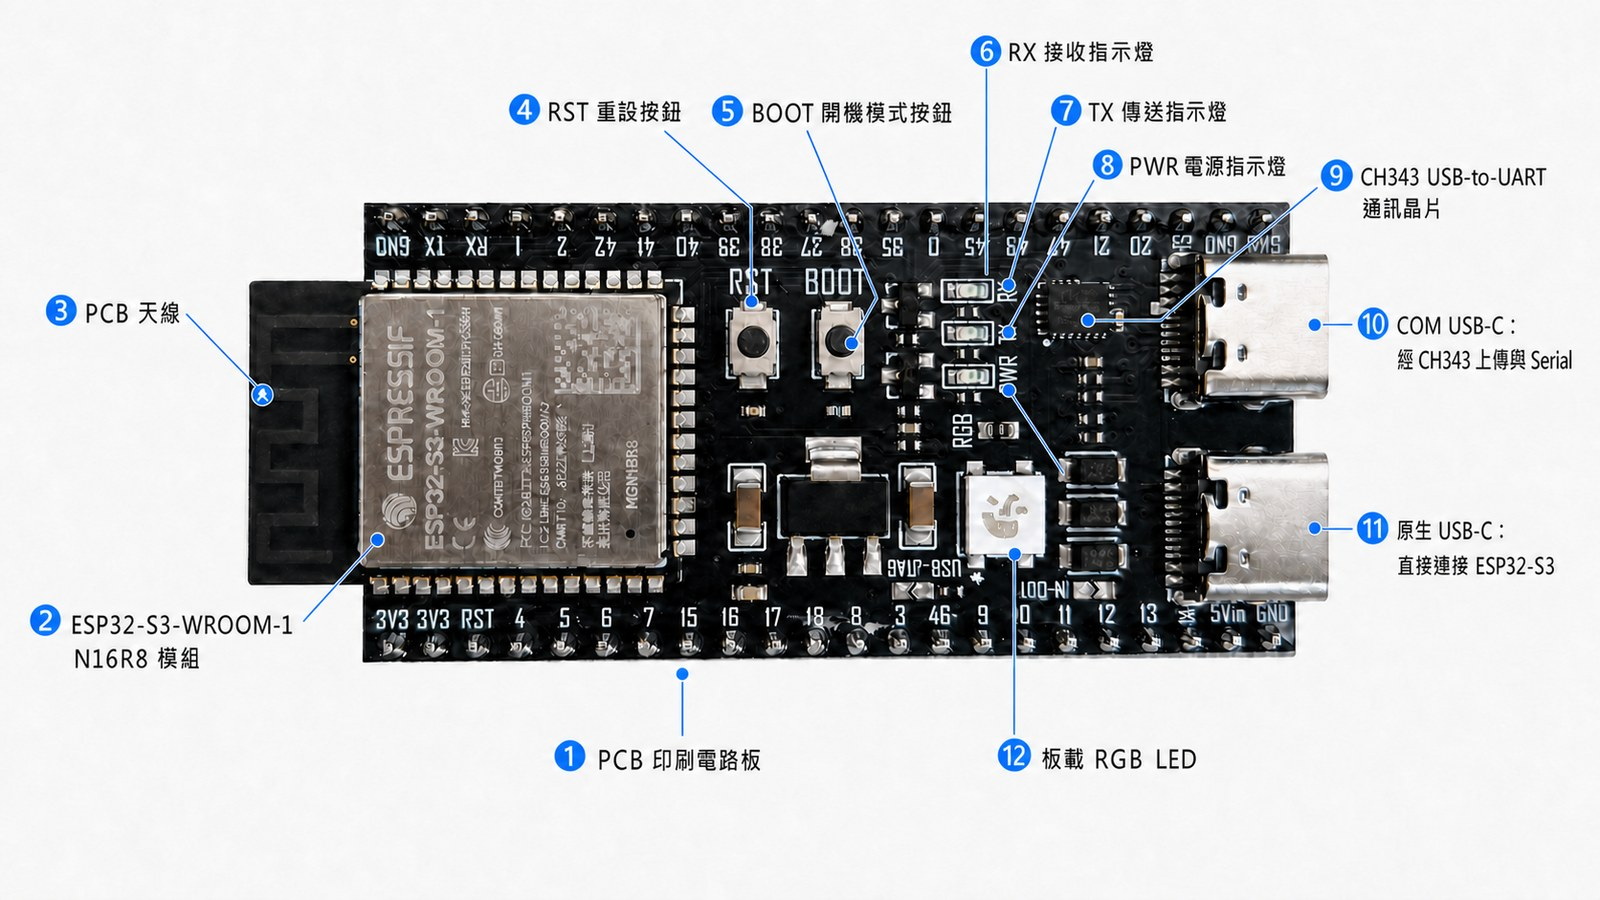

### 步驟4：分辨RST、BOOT與排針標示

| 標示 | 類型 | 本週用途 |
|---|---|---|
| `RST`／`RESET` | 控制按鈕 | 重新啟動目前Flash中的程式；不會刪除程式 |
| `BOOT` | 控制按鈕 | 上傳無法自動連線時，配合RST進入下載模式 |
| `4`、`5`等數字 | GPIO絲印 | 由程式設定為輸入或輸出；數字不是電壓 |
| `GND`／`G` | 0V參考 | 提供電壓基準與返回路徑；不是負電源 |
| `3V3` | 3.3V電源 | 本週辨認但不接到麵包板 |
| `5Vin` | 外部5V輸入 | 本週不使用；BOARD-T01的`IN-OUT`開路時，USB不會由此腳輸出5V，也不是`5Yin`或GPIO5 |
| `TX`／`RX` | 序列通訊 | 表示資料傳送與接收活動 |

正常Upload通常由CH343自動控制下載與Reset，不需先按BOOT。只有Upload停在
`Connecting...`且已確認Board、Port與資料線後，才使用後面的手動BOOT／RST流程。

板身、模組與晶片是不同層次；本階段先找到實物標示，不必先執行硬體參數查詢。
CPU時脈、Flash／PSRAM回報及判讀例子保留在同本的[板卡參數補充](#w2-board-details)，
遇到參數疑問時再查閱。

### GPIO、GND與3.3V的關係

電腦USB提供約5V，開發板穩壓電路將它轉成ESP32-S3使用的約3.3V。接上USB只會
讓晶片取得工作電力，不會使每支GPIO自動輸出3.3V；GPIO行為由程式設定。

```text
電腦USB約5V → 開發板穩壓電路 → 約3.3V電源軌 → ESP32-S3
```

#### 用地面、平台與電梯理解GND、HIGH與LOW

先把電壓想成高度，不急著計算電流：

```text
3V3：固定在約3.3V高度的平台
GPIO：可以由程式或外部接線改變位置的電梯
GND：定義為0V的地面
電表：比較兩個位置高度差的尺；Week 3再實際使用
```

在本週數位GPIO接法中，`HIGH`與`LOW`是輸入判定或輸出命令的邏輯狀態：GPIO接近GND的
0V高度是`LOW`，接近3V3平台的高度是`HIGH`。3V3本身是固定電源軌，不因為
接近3.3V就改稱「GPIO是HIGH」；量兩個GND得到接近0V，也不表示GND是GPIO的LOW。

實際輸入有規定的HIGH／LOW電壓範圍，並不是只接受剛好0.000 V或3.300 V；
介於未保證區間的訊號不能硬判成可靠HIGH／LOW。這裡用端點類比，Week 3才上電量測。

本週的按鈕輸入可以用電梯理解。內部上拉電阻在按鈕放開時把GPIO電梯維持在
3V3平台附近，所以讀到`HIGH`；按住按鈕後，GPIO被拉到GND地面，所以讀到
`LOW`。`HIGH`與`LOW`描述的是GPIO的位置，不等於電路有沒有閉合，也不代表
電流越大越好。

本週把按鈕腳設為`INPUT_PULLUP`。**上拉電阻**是晶片內部從GPIO通往3.3V的
弱連接，讓未按按鈕時有明確的HIGH。按下時，按鈕把GPIO接到GND，輸入變成LOW。
上拉電阻同時限制流向GND的電流，因此這個輸入接法不是3.3V直接短路GND。

```text
放開：3.3V ──[內部上拉電阻]── GPIO ──[按鈕開路]── GND  → HIGH
按住：3.3V ──[內部上拉電阻]── GPIO ──[按鈕閉合]── GND  → LOW
```

**閉合電路**是電流能從電源出發、通過元件並返回電源的完整路徑；**開路**表示
其中一處中斷。閉合電路不等於短路：正常路徑具有負載或電阻，短路則是不同電位
間出現不預期的低阻抗捷徑。

一片開發板可能提供多個GND排針，方便不同位置接線；它們通常屬於同一GND網路。
本週只接一條GND線，再由麵包板的TPG列分接，不需要同時接兩個GND。

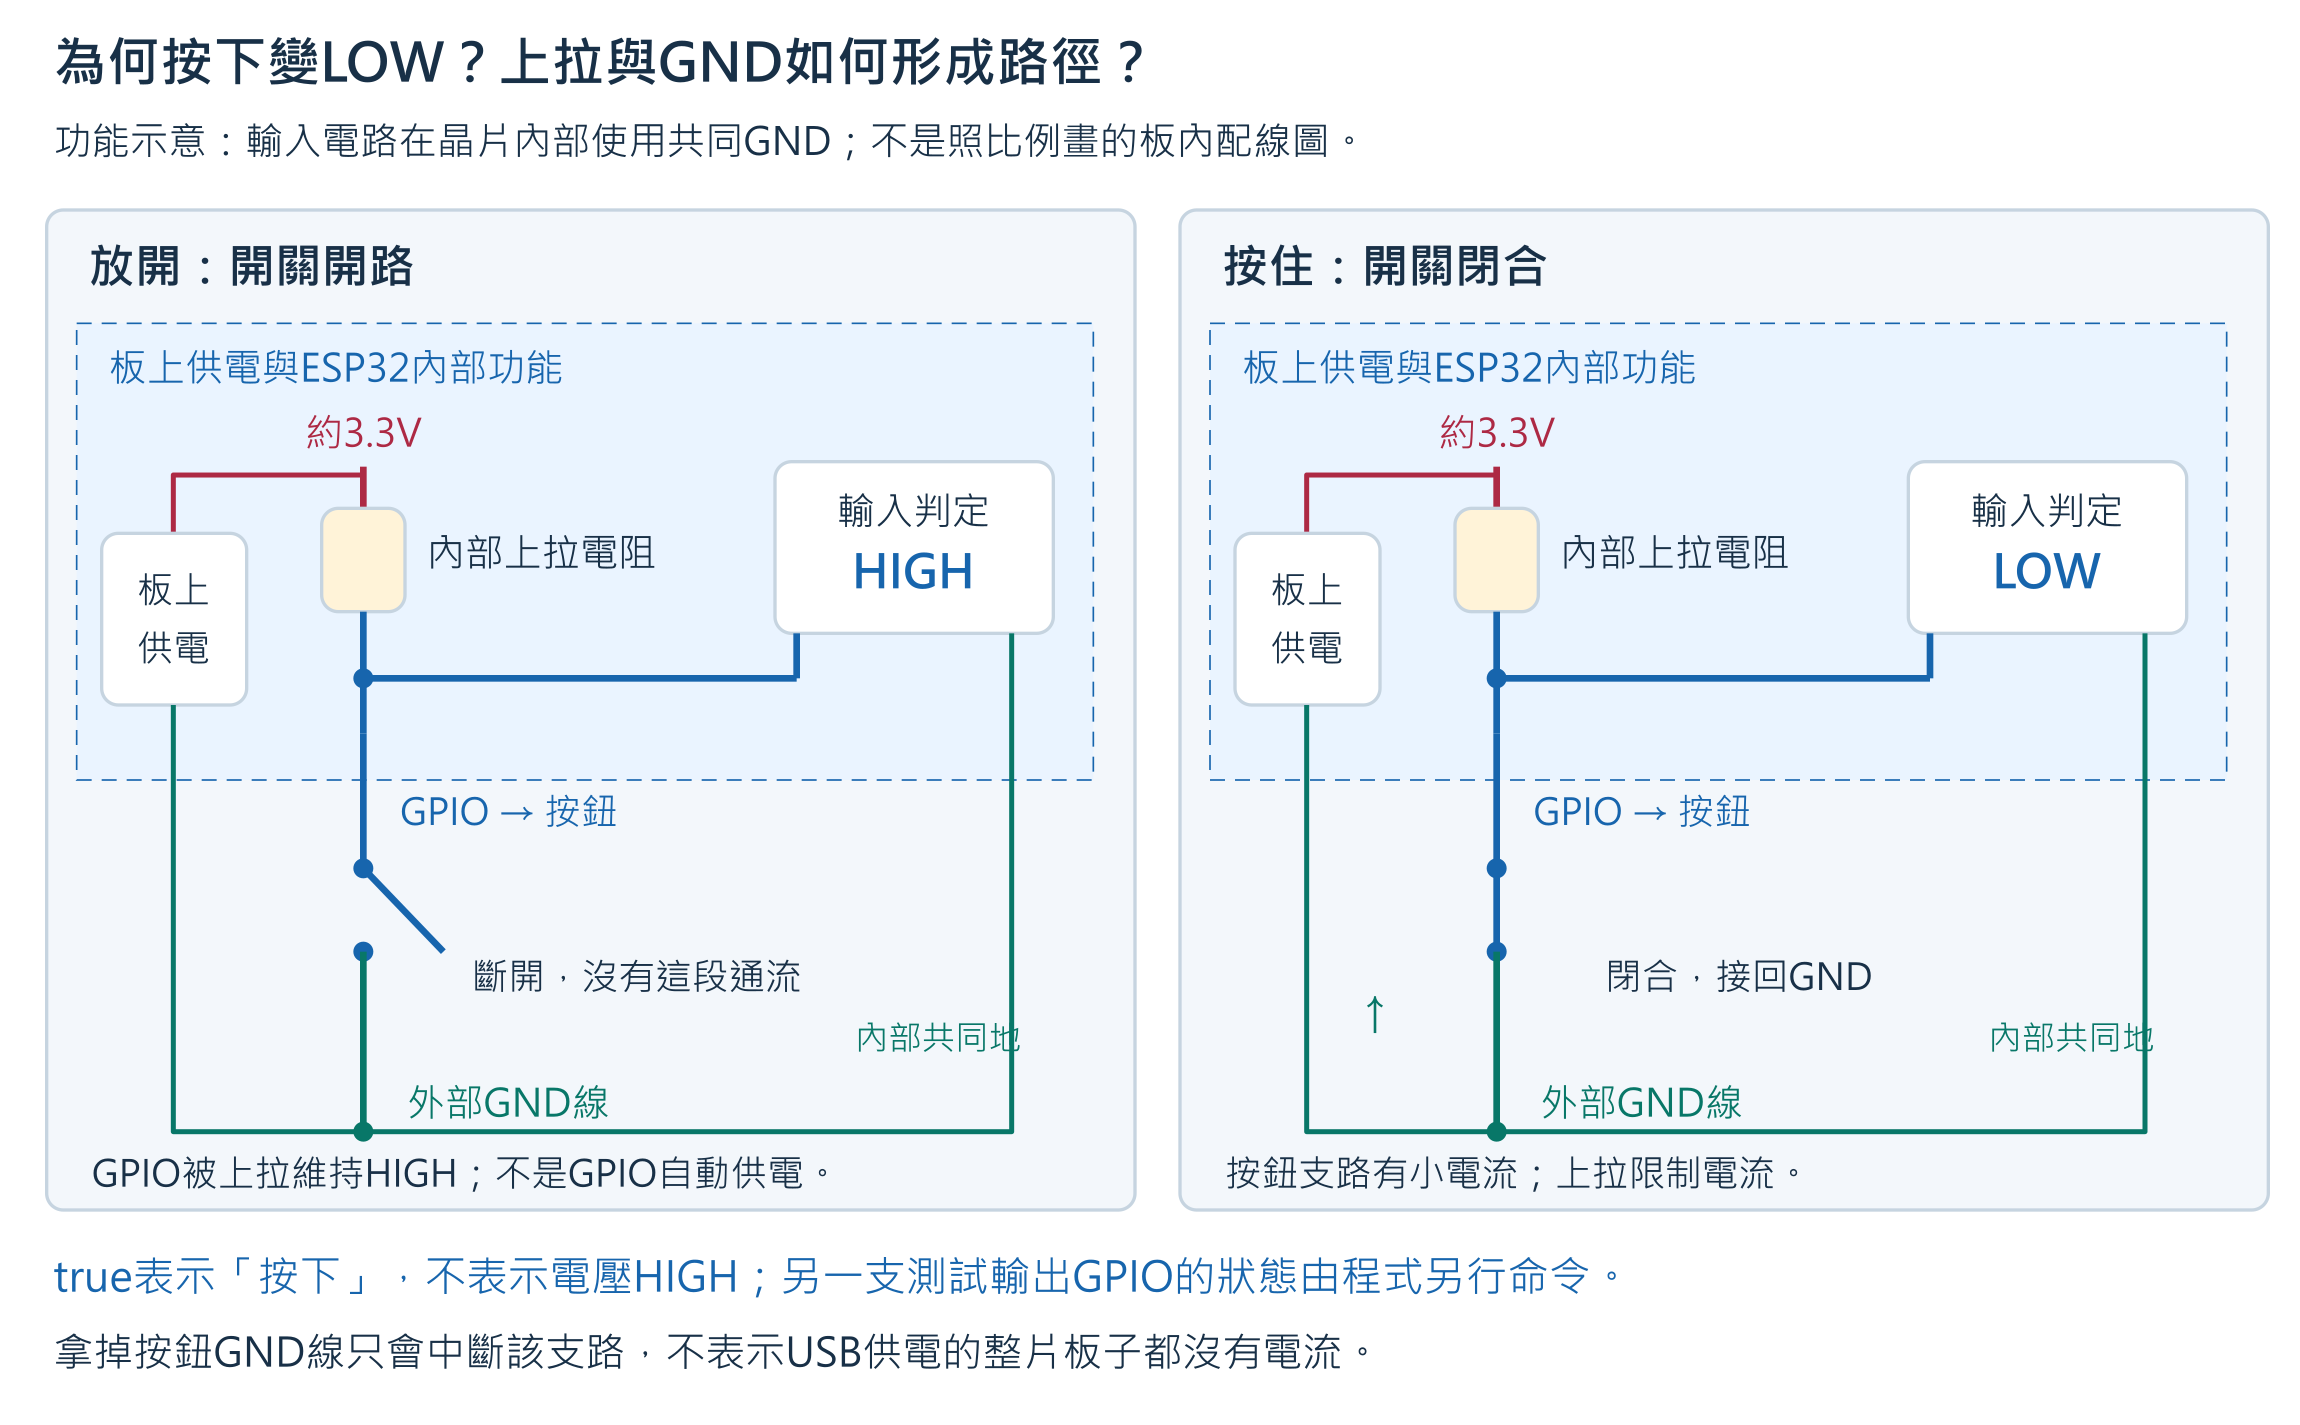

圖中虛線框整理板上供電與ESP32內部功能，不是晶片實際邊界，也不是要多接一條3V3線。
GPIO輸入電路在晶片內部以自己的GND為參考；外部GND線把按鈕另一端接回共同零點，
按鈕閉合時，GPIO才經由接點連到這條返回路徑。
類比成尺：GPIO是被比較的位置，GND是0刻度；`digitalRead()`只回報HIGH或LOW，
不會回傳「3.3 V」這個測量數字。

現在先看懂路徑：上拉電阻限制按鈕支路電流，按鈕閉合把輸入接近GND。
第七節會用[電壓、電阻與電流的逐步例子](#w2-ohms-example)解釋數字如何相連，
第十三節再套回內部上拉；此處先沿圖找出有限流電阻的支路，不把它誤認為導線直連。
GPIO5的輸出則是程式另行決定，
不是電流從GPIO4穿過程式再流到GPIO5。參考
[Espressif GPIO與內部上拉說明](https://docs.espressif.com/projects/arduino-esp32/en/latest/api/gpio.html)。

如果省略按鈕的GND線，按下後就失去預定拉低路徑；USB仍供應整片板子，不能說
「整片板完全沒有電流」。先在紙上比較，不用帶電拔線製造故障。

依實物完成辨認：

| 項目 | 板身實際標示或位置 |
|---|---|
| PCB與模組型號 |  |
| `COM` USB接頭 |  |
| BOOT與RST |  |
| 教師公布的`PIN_BUTTON` |  |
| 教師公布的`PIN_TEST_OUTPUT` |  |
| 使用的GND |  |

若實物絲印或外形與教材不同，停止接線並請教師核對，不依相似板卡圖片猜測。


<a id="w2-settings"></a>

## 五、Arduino IDE板卡與連接埠設定

### 步驟1：建立USB連線

本週使用板背標示`COM`的USB-C接頭。這條路徑經過**CH343 USB-to-UART**晶片，
把筆電USB資料轉成ESP32的UART序列通訊；CH343不執行Arduino程式，程式仍由
ESP32-S3執行。另一個標示`USB`的接頭是原生USB路徑，本週不使用。

1. 確認開發板沒有接麵包板、杜邦線或外部電池，放在乾燥、不導電的桌面。
2. 翻到背面讀取`COM`與`USB`絲印，不能只靠上下位置記憶。
3. 將可傳輸資料的USB線接到`COM`接頭，再直接接到筆電USB孔。
4. 等待Windows辨識裝置。`PWR`燈亮只證明有供電，尚未證明資料通訊成功。

```text
Upload：筆電USB → CH343 → UART → ESP32-S3
Serial：ESP32-S3 → UART → CH343 → 筆電USB → Serial Monitor
```

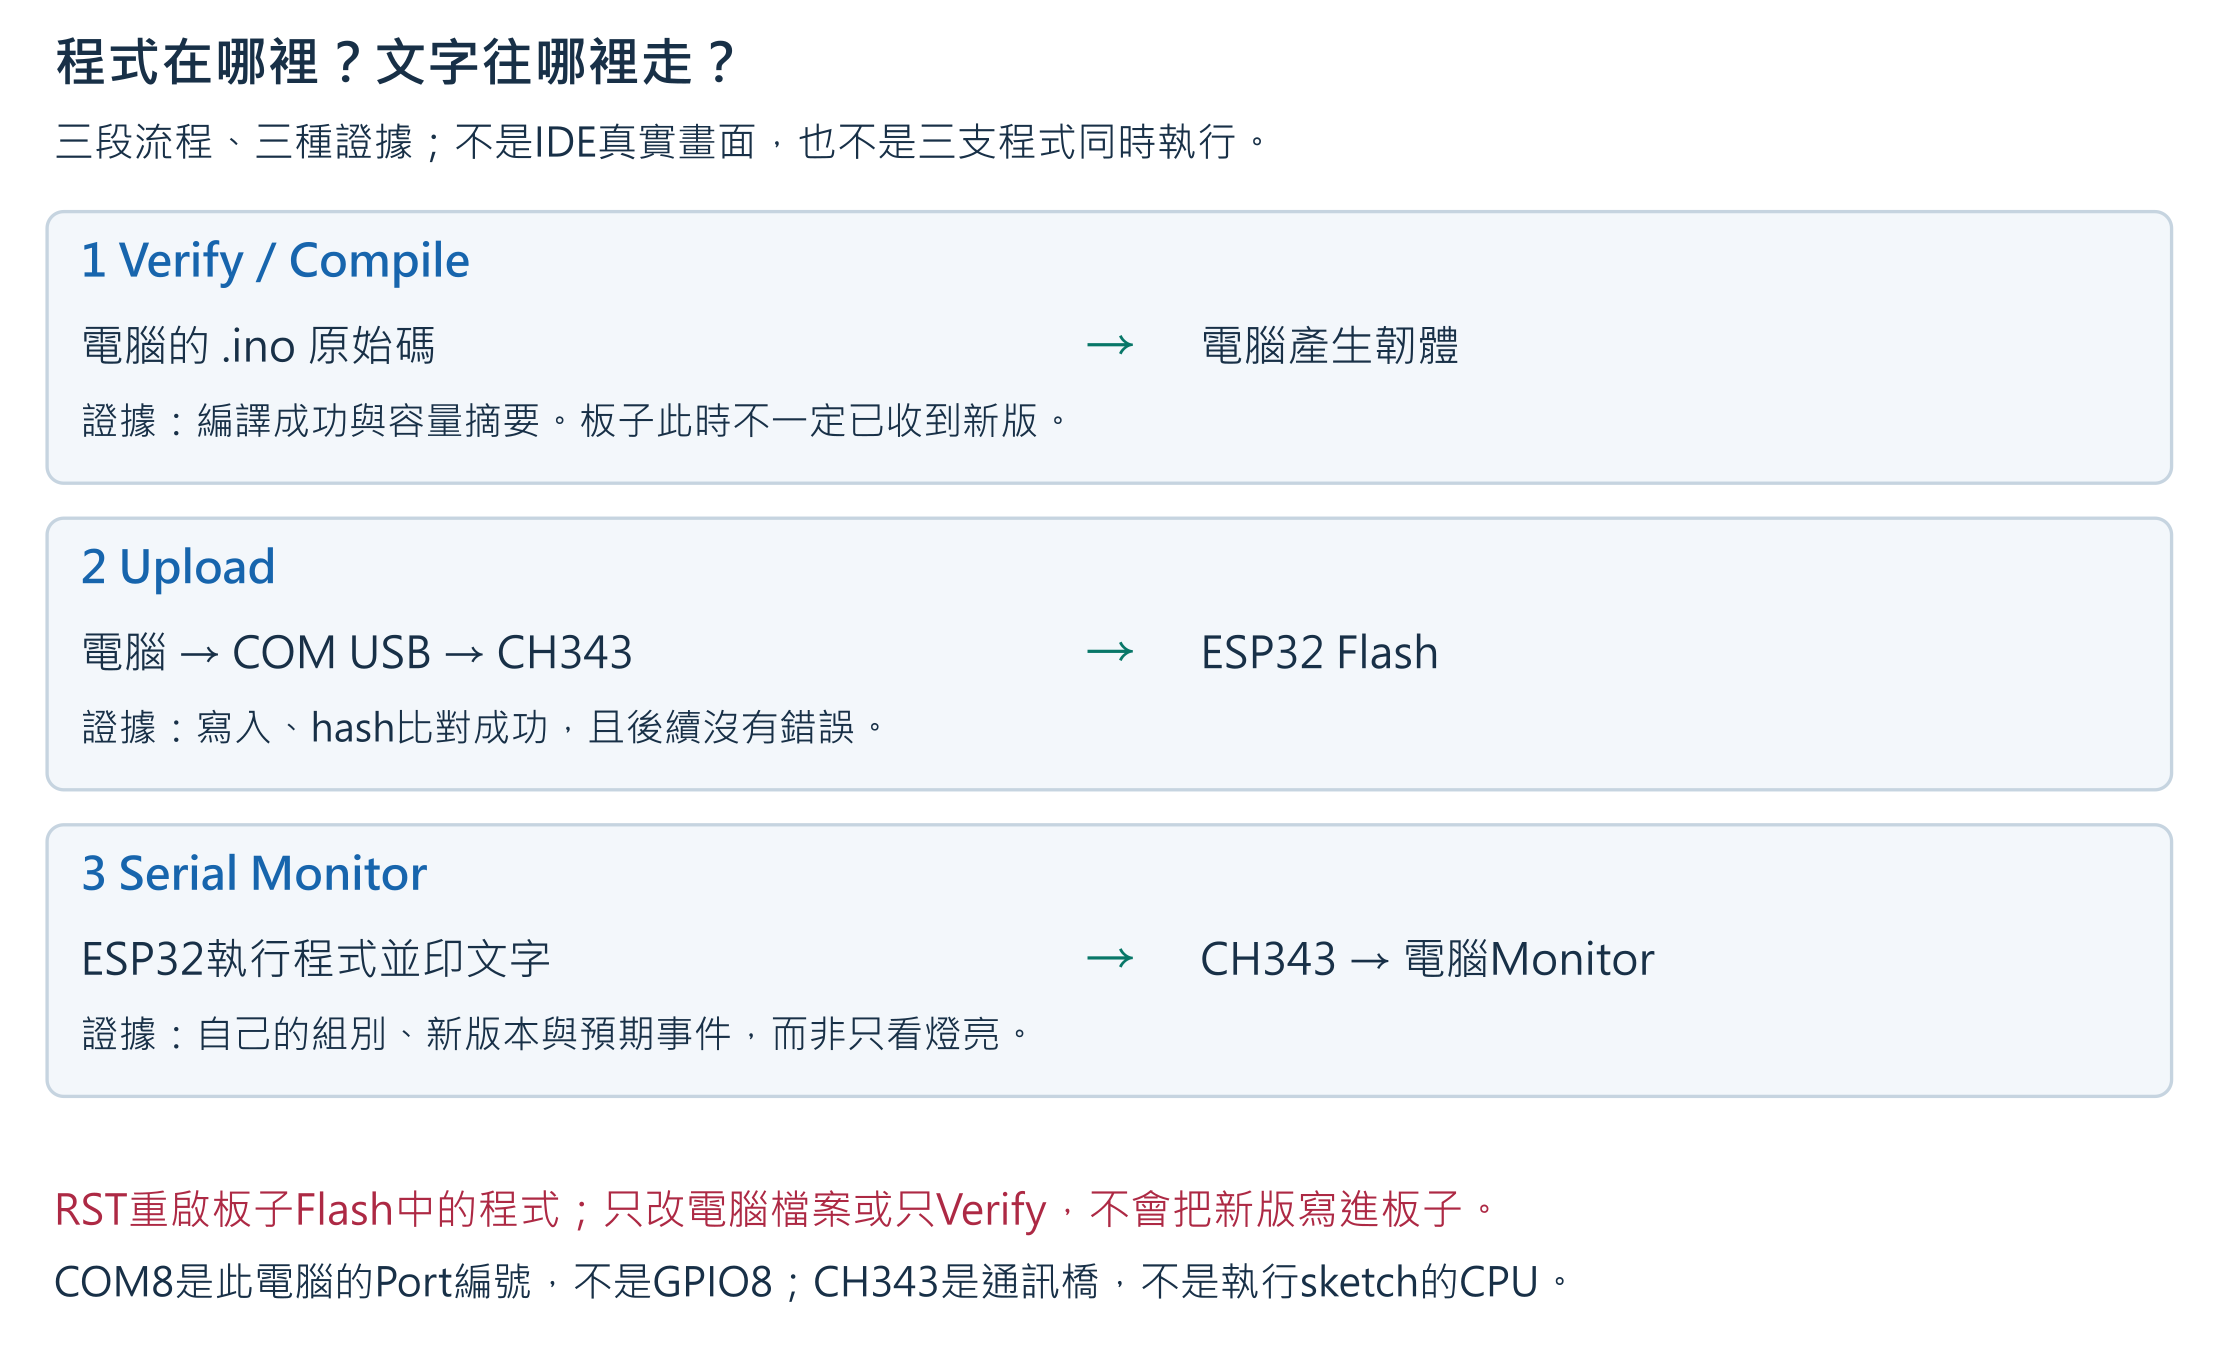

`TX`表示transmit（傳送）、`RX`表示receive（接收），方向要連同所屬晶片或介面一起看。
板上燈閃爍可作通訊活動提示，但燈的接法、亮滅時間與程式輸出頻率會影響可見程度。
例如每秒印uptime可能看到閃光，按鈕程式閒置時TX／RX不亮也可能正常。
**PWR亮、TX閃、沒有異味**都不能取代Upload紀錄與預期Serial文字。

### 步驟2：選擇Board與N16R8設定

`ESP32S3 Dev Module`是Arduino IDE的通用編譯設定，不是實物PCB型號。`N16R8`
表示模組具有16 MB Flash與8 MB PSRAM；Flash斷電後仍保存程式，PSRAM是程式
執行時使用、斷電後不保留內容的額外記憶體。

使用 **Tools → Board → esp32 → ESP32S3 Dev Module**，再逐項核對：

| Tools設定 | 本課N16R8設定 | 作用 |
|---|---|---|
| Board | `ESP32S3 Dev Module` | 使用ESP32-S3編譯規則 |
| Flash Mode | `QIO 80MHz`或選單中的QIO | 符合本模組Flash介面 |
| Flash Size | `16MB (128Mb)` | 對應N16；8 bits等於1 byte |
| PSRAM | `OPI PSRAM` | 對應R8的Octal PSRAM |
| USB CDC On Boot | `Disabled` | 本週使用CH343 USB-to-UART |
| Upload Mode | `UART0 / Hardware CDC` | 使用UART下載路徑 |
| Upload Speed | `115200` | 本課已驗證的上傳速度 |
| Erase All Flash Before Sketch Upload | `Disabled` | 一般上傳不清除整顆Flash |

`Partition Scheme`依教師公布、且與課堂Arduino-ESP32版本相同的設定。選單名稱若
與教材不一致，不自行挑選看起來較快或容量較大的選項，先保存畫面並請教師核對。

本課實物、IDE設定與程式讀值是不同層次：

```text
IDE Board：ESP32S3 Dev Module
實際PCB：YD-ESP32-S3 Type-A V1.5
實際模組：ESP32-S3-WROOM-1 N16R8
實際晶片：ESP32-S3
```

官方參考：[ESP32-S3-WROOM-1資料表](https://documentation.espressif.com/esp32-s3-wroom-1_wroom-1u_datasheet_en.pdf)｜[Arduino-ESP32 Tools Menu](https://docs.espressif.com/projects/arduino-esp32/en/latest/guides/tools_menu.html)

### 步驟3：用拔除前後比較找Port

**Port**是IDE與目前連接裝置通訊的入口。Windows的`COM8`等號碼會依電腦與USB孔
改變，不能照抄別人的號碼。萬用電表上的`COM`則是黑表筆插孔，兩者沒有關係。

1. 先拔除ESP32 USB，開啟 **Tools → Port**並記下現有清單。
2. 關閉選單，把ESP32接回同一個USB孔，等待Windows辨識。
3. 再開 **Tools → Port**，找出新出現的Port並選取。
4. 這批板卡可能顯示`USB-Enhanced-SERIAL CH343`，也可能只顯示COM號碼；以
   拔除前後差異為判斷，不選Bluetooth Port。

我的Port：`____________________`

沒有新Port時，依序更換已知可傳資料的USB線、筆電USB孔，再重新開啟Port選單。
仍無法辨認時保存裝置管理員畫面，不安裝來源不明的driver。

### 本節檢核

- [ ] 使用板背標示`COM`的USB接頭。
- [ ] Board為`ESP32S3 Dev Module`，Flash Size為16 MB，PSRAM為OPI。
- [ ] Upload Speed與Serial Monitor均使用115200；兩者是不同階段的設定。
- [ ] 已用拔除前後比較找到自己的Port。


<a id="w2-serial"></a>

## 六、第一個程式：編譯、上傳與序列輸出

以下程式是給Arduino IDE的C++／Arduino sketch，不是在Python notebook按Run。
notebook負責把說明與可複製程式放在一起；實際Compile、Upload仍在Arduino IDE。
完整來源：[week02_serial_basics.ino](../examples/week02_serial_basics/week02_serial_basics.ino)。

### 步驟 1：建立程式

- **Sketch** 是 Arduino 對一個程式專案的稱呼，資料夾和主要 `.ino` 檔通常
  使用同一名稱。
- **`setup()`** 在開機或 RESET 後只執行一次；**`loop()`** 會在之後持續
  重複執行。
- `CHANGE_ME` 和 `XX` 是「請換成自己的資料」的預留文字，不是固定答案。
- **baud rate** 是序列通訊速度。本課程式使用 115200，稍後 Serial Monitor
  也必須選相同數值。

1. 點 **File → New Sketch**。
2. 點 **File → Save As**。
3. 將資料夾／Sketch 名稱設為 `week02_serial_groupXX`，把 `XX` 換成組別。
4. 刪除編輯器內原本的 `setup()` 與 `loop()` 範本，避免重複定義。
5. 完整複製下列程式；若頁面提供Copy按鈕可直接使用，否則從第一行選取到最後一行再複製。
6. 貼到 Arduino IDE。
7. 把 `CHANGE_ME` 改成組別，例如第 3 組改成 `03`。
8. 按 **Ctrl+S** 儲存。

#### 程式語法說明

- `unsigned long` 是可保存非負整數的資料型別，本程式用來保存毫秒時間。
- `millis()` 取得 ESP32 從開機到目前經過的毫秒數。
- `if` 表示只有括號內條件成立，才執行大括號內的程式；`>= 1000` 表示已經
  過了至少 1000 毫秒。
- `Serial.begin(115200)` 以 115200 baud 啟動序列通訊。
- `Serial.println()` 輸出一整行文字；`Serial.printf()` 可把變數插入文字，
  `%lu` 對應 `unsigned long`，`\n` 表示換行。

完整程式：


In [ ]:
unsigned long lastReportMs = 0;

void setup() {
  Serial.begin(115200);
  delay(500);
  Serial.println("boot: week02 group=CHANGE_ME version=1");
}

void loop() {
  unsigned long now = millis();

  if (now - lastReportMs >= 1000) {
    lastReportMs = now;
    Serial.printf("status: uptime_ms=%lu\n", now);
  }
}


baud rate 維持 115200。貼上後確認程式只出現一組 `setup()` 與一組 `loop()`。

### 步驟 2：分辨 Verify 與 Upload

- **Verify／Compile（驗證／編譯）**：檢查語法，再把人寫的程式轉成 ESP32
  可執行的韌體；成功不代表已經寫進板子。
- **韌體（firmware）**：儲存在 ESP32 Flash、開機後會執行的程式。
- **Upload（上傳／燒錄）**：把編譯完成的韌體寫入板子。
- **Output**：IDE 下方顯示編譯和上傳過程的區域，不是稍後顯示程式文字的
  Serial Monitor。

1. 點左上角勾號 **Verify**。
2. 檢查視窗下方 Output 的文字，不以進度動畫作為成功判斷。
3. 等待編譯完成及記憶體用量訊息；若出現紅色錯誤，應先處理 Output 中最早
   出現的錯誤，不從最後一行反向推測。
4. Verify 成功後，點右箭頭 **Upload**。
5. Output 會先再次編譯，再出現連線、寫入百分比及完成訊息。
6. 核對寫入與hash驗證成功，且後面沒有錯誤；Reset訊息本身不能代替前面的成功紀錄。
7. Upload 期間不得拔線、按 RESET 或移動板子。

`Hard resetting via RTS pin...` 通常表示 IDE 已透過 USB-to-UART 的 RTS 控制
訊號要求板子重設；後續新版本的Serial文字才支持新程式已啟動。它不是「硬體損壞」訊息。

Verify成功時常見的記憶體摘要可以這樣判讀：

```text
Sketch uses ... bytes (...) of program storage space.
Maximum is ... bytes.
Global variables use ... bytes (...) of dynamic memory.
```

- `Sketch uses`是本次韌體占用的程式分割區空間。
- `Maximum`是目前Partition Scheme分給應用程式的上限，不是整顆Flash容量；
  16 MB Flash中的其他區域可能分給檔案系統、系統資料或其他映像。
- `Global variables`是編譯時可計算的內部記憶體配置，不能用來證明8 MB PSRAM
  已經啟用；PSRAM仍須由程式執行期間的runtime讀值確認。

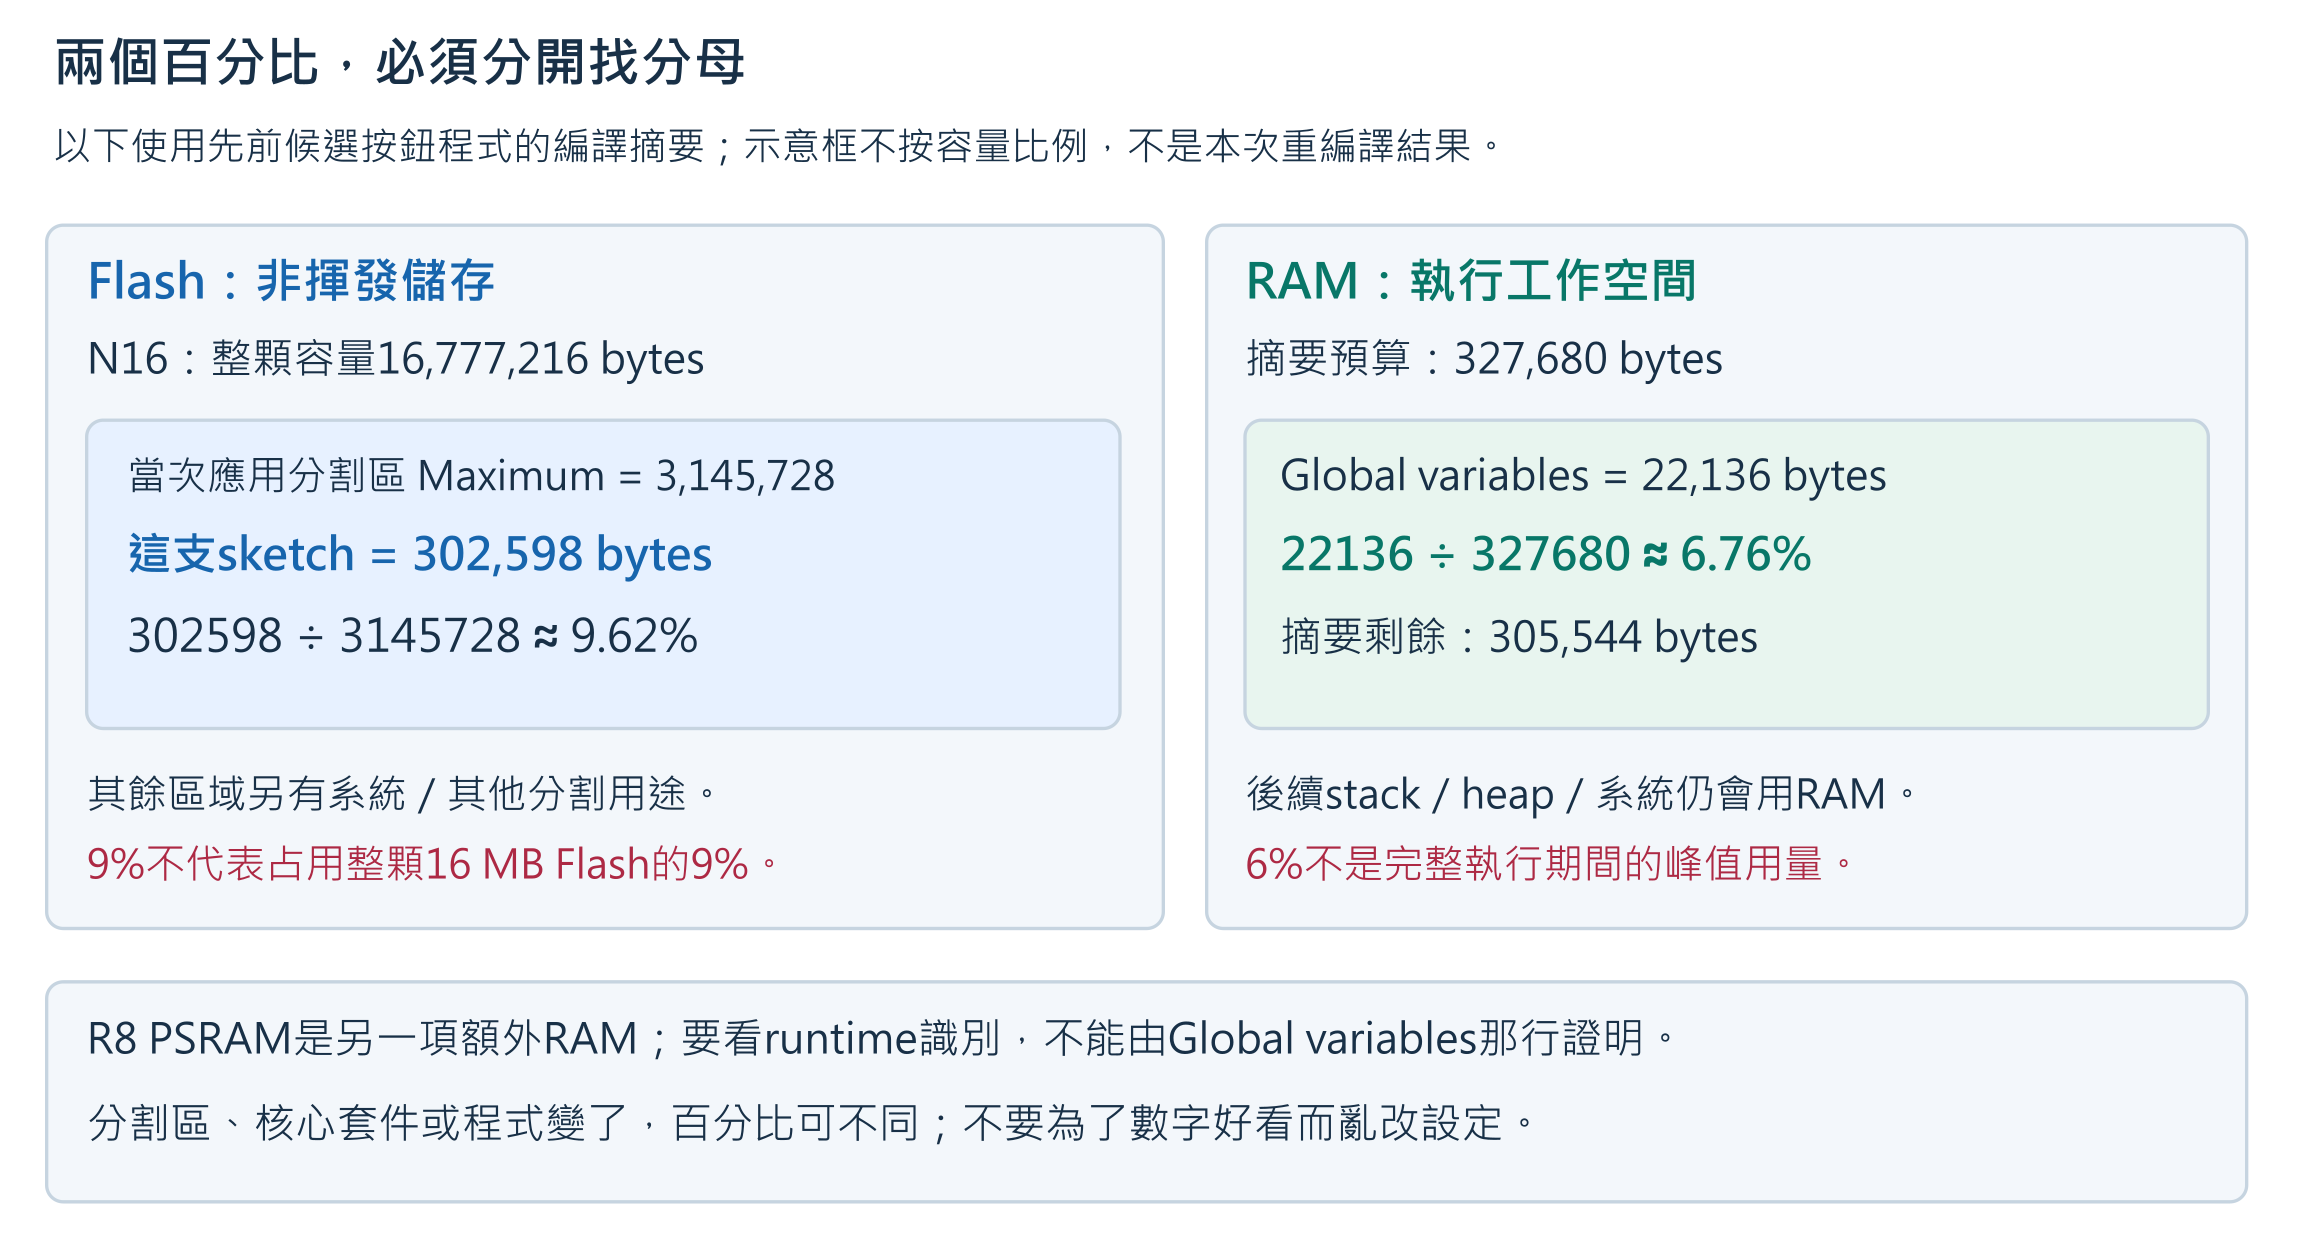

以先前按鈕候選測試的編譯摘要計算：

- 302598 ÷ 3145728 × 100% ≈ **9.62%**；該次IDE顯示整數9%。分母是當次約3 MiB的
  應用程式分割區，不是N16的整顆16 MiB Flash。
- 22136 ÷ 327680 × 100% ≈ **6.76%**；該次IDE顯示整數6%。這是編譯時已配置的
  全域／靜態資料相對該工具顯示的RAM預算；不是執行期間全部記憶體需求。
- 327680 − 22136 = **305544 bytes**是該摘要計算的剩餘值。之後函式呼叫的stack、
  動態配置的heap、函式庫與系統運作仍可能用到RAM，不能解讀成永遠剩下94%。

例如把應用分割區改小，同一程式顯示的百分比可能增加，並不是Flash忽然變小或程式
突然長大。**不要為了讓百分比變好看更改Partition Scheme**；紀錄實際Board、套件版本、
分割設定、分子與分母。上述為歷史判讀例子，新程式不要求編出相同bytes。

Upload時的`Writing at ... 100%`表示資料已傳送到Flash；`Hash of data verified`
表示寫入後資料與本次傳送內容的雜湊比對相符。這些訊息證明寫入流程完成，
仍不能證明程式功能、GPIO或外接硬體正確。`Sketch uses`與`Wrote`的bytes可能因
映像區段、對齊或傳輸格式而不同，不必強求兩個數字相同。

Verify 成功不等於 Upload 成功；Upload 成功也不等於程式功能正確。三者需要
不同證據。

#### `Connecting...` 停滯時的處理

`Connecting...` 表示 IDE 正嘗試和 ESP32 建立下載連線。BOOT 可讓板子進入
下載模式，RESET 讓板子重新啟動；只有正常自動 Upload 失敗時才使用下列
手動順序。

依下列順序做一次手動下載模式：

1. 保持 USB 連接。
2. 按住板上的 **BOOT** 不放。
3. 短按一下 **RESET／RST** 後放開 RESET。
4. 再放開 BOOT。
5. 回到 Arduino IDE，重新確認 Port。
6. 再按 Upload。

另一種常見操作是先按 Upload，看到 `Connecting...` 時按住 BOOT，連線開始
寫入後再放開。兩種方式都只在正常自動 Upload 失敗時使用。

若 Output 顯示晶片不是 ESP32-S3，應立即停止並回到 Board 設定，不得使用
錯誤 Board 強行上傳。

### 步驟 3：檢查 Serial Monitor 輸出

- **Serial** 是 ESP32 與電腦依序傳送文字或資料的通訊方式。
- **Serial Monitor** 是 Arduino IDE 顯示這些程式輸出的視窗。
- **log** 是程式留下的執行紀錄，例如組別、版本、事件與時間。
- **115200 baud** 是本程式的傳輸速度；程式與 Serial Monitor 設定不同時，
  文字可能變成亂碼。

Serial Monitor不會自動掃描晶片或顯示「所有硬體參數」。它只顯示程式透過
`Serial.print()`、`Serial.println()`或`Serial.printf()`主動送出的內容。
`Serial.begin(115200)`設定ESP32送出序列資料的速度，Monitor也必須選115200；
Upload Speed即使也是115200，仍屬於「電腦把韌體送到板子」的另一個階段。

1. Upload 完成後，點 Arduino IDE 右上角 **Serial Monitor** 圖示，或選
   **Tools → Serial Monitor**。
2. 在 Serial Monitor 的 baud rate 選單選擇 `115200`。
3. 按一下板上的 RESET，讓開機訊息重新出現。
4. Serial 輸入框保持空白；本程式不讀取鍵盤輸入。
5. 預期看到：

```text
boot: week02 group=03 version=1
status: uptime_ms=1000
status: uptime_ms=2000
status: uptime_ms=3000
```

`boot: ...`是程式自己寫出的開機訊息，不是ESP32內建健康報告。`uptime_ms`來自
`millis()`，表示本次開機或Reset後經過的毫秒數；增加約1000代表約一秒。按RST
後再次看到`boot: ...`，且uptime重新從接近0開始，才形成「程式已重新啟動」的
可觀察證據。若Serial Monitor在`setup()`完成後才開啟，可能先只看到uptime；
短按RST可以重現開機訊息。Monitor保留的Reset前舊文字不代表兩份程式同時執行。

若是亂碼：

1. 確認 baud rate 是 115200。
2. 確認 Serial Monitor 使用的 Port 和 Upload 的 Port 相同。
3. 按 RESET 再看一次。

若完全沒有文字：

1. 關閉 Serial Monitor。
2. 重新確認 Tools → Port。
3. 再開 Serial Monitor 並選 115200。
4. 按 RESET。
5. 檢查程式是否包含 `Serial.begin(115200)`。
6. 仍無輸出時重新 Upload，保存 Output 及 Serial 畫面再求助。

#### 讀完一行log後，要能回答什麼

`status: uptime_ms=3000`表示程式在約第3秒送出這行，不代表Serial每秒替板子計時。
時間是ESP32的`millis()`取得，再經`printf`把數字填到`%lu`的位置。
實際可能是3007、4007等；前後差約1000才是這支程式的週期特徵。

`loop()`不是每秒只跑一次；它一直檢查「now − lastReportMs是否至少1000」。
未滿時不印，滿了才把`lastReportMs`改為現在時間並印一行。
`delay(500)`只在setup等待一次，不是loop每輪等待500 ms。

**先預測再操作**：只在電腦把version改成2，按Verify但不Upload，按RST會看到1還是2？
先記答案，再依下列完整Upload流程驗證。預期解析集中於10.10節，不增加第二項實驗。

### 步驟 4：驗證程式版本

1. 關閉 Serial Monitor。
2. 在程式中把 `version=1` 改成 `version=2`。
3. 按 Ctrl+S。
4. 再按 Upload。
5. Upload 完成後重新開啟 Serial Monitor，確認 115200。
6. 按 RESET。
7. Serial 必須出現正確組別及 `version=2`。
8. 保存包含組別、版本與 uptime 的畫面，命名
   `week02_serial_version2_組別.png`。

### 本節檢核

- [ ] Verify 成功。
- [ ] Upload 成功。
- [ ] Serial 顯示正確組別與 `version=2`。
- [ ] 實驗紀錄已各用一句文字記錄 Verify 與 Upload 的用途。


<a id="w2-meter"></a>

## 七、萬用電表：先選對功能，再解讀數字

本週只在完全斷電時量測麵包板與按鈕的通斷；分組方式見[器材與分組](#w2-materials)。
一人操作時先用麵包板固定按鈕，再用杜邦線延伸測點，不勉強同時拿兩支表筆與按鈕。

**萬用電表（multimeter）**是一台可選擇不同功能量測電壓、電阻等數值的
儀表；紅、黑兩條尖端量測線稱為**表筆（probe）**。本教材以教師現有的
A830L 為操作示例；若正式材料清單安排功能相當的其他型號，符號與檔位位置
可能不同，操作時仍以實物標示為準。

本節先完成電表自我檢查；下一節才在空麵包板與按鈕上量測，不需要來回重新做同一套實驗。

### 先認位置，再讀畫面

下圖是本課A830L的原始實拍，旋鈕當時在OFF；**不是現在應照做的選檔狀態**。
上方灰綠色區域是LCD（液晶顯示幕），數字與小數點在這裡出現；OFF時沒有數字。

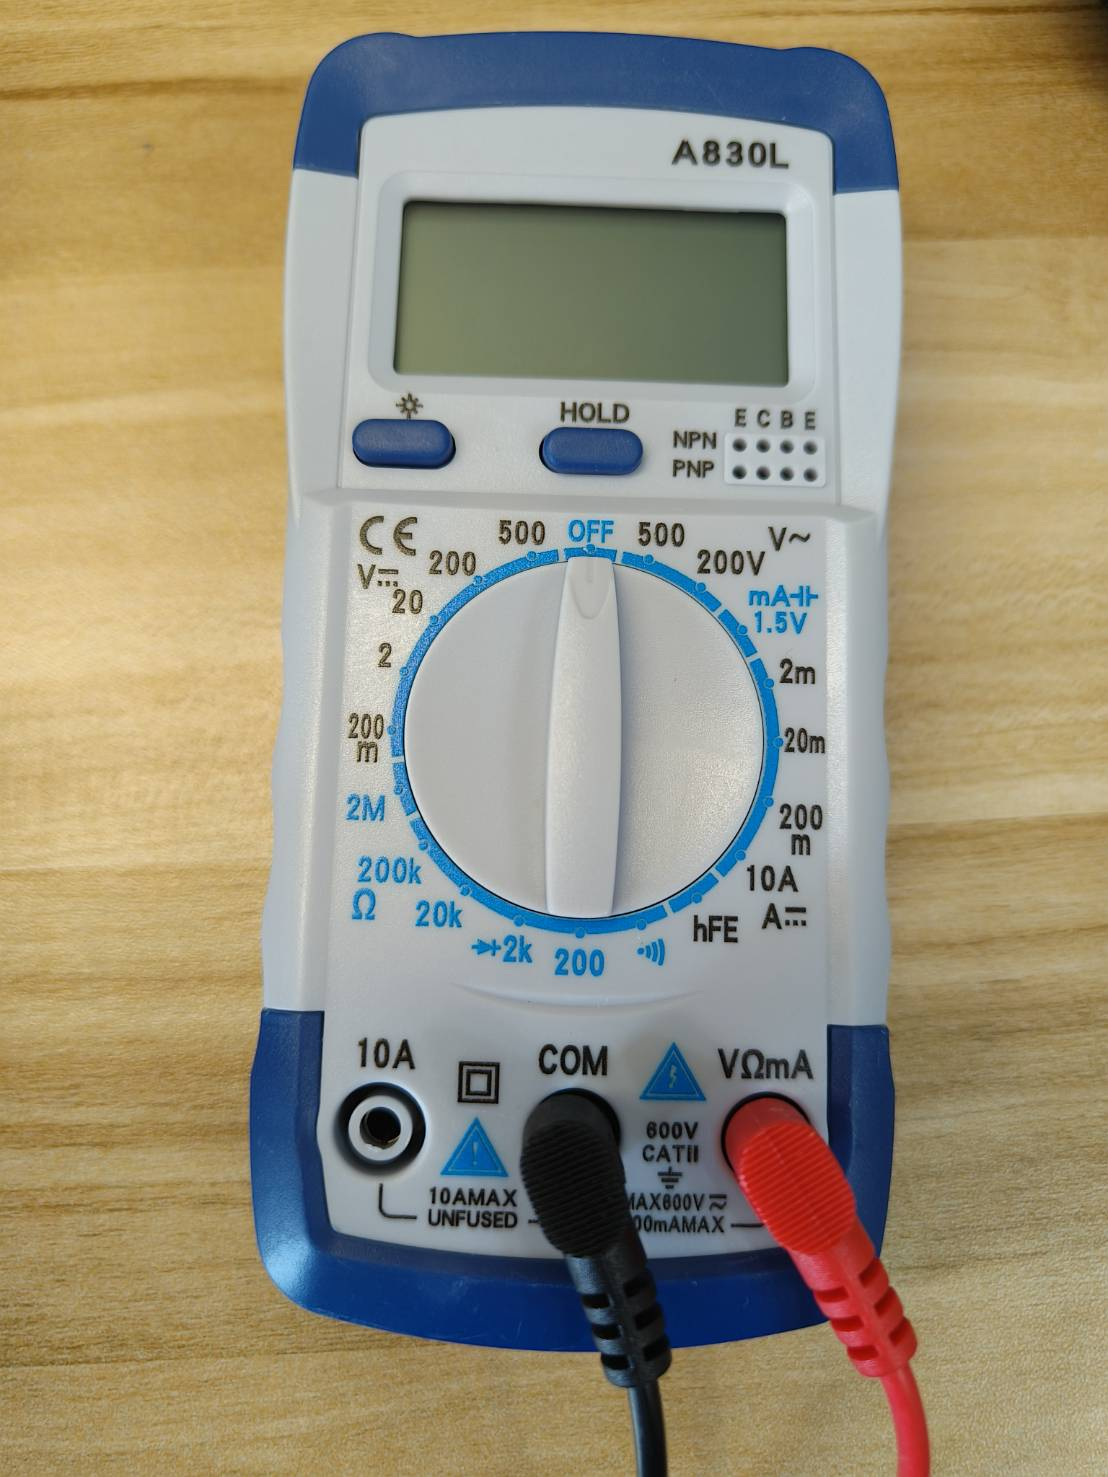

先在自己的電表找到：下方中間`COM`接黑表筆、右方`VΩmA`接紅表筆，
左方`10A`留空。本課照片的聲波符號在旋鈕下方偏右；電阻區的`200`在
旋鈕正下方附近，與右側電流區的`200m`不同。只看旋鈕尖端指向哪一個定位點，
不看旋鈕寬大的另一端。其他型號先找符號，不照抄鐘面方向。
旋鈕在OFF、表筆插孔確認後，才依下方步驟選檔。

### 把電表數字讀成一句完整的話

每筆都先交代「已斷電或正供電」，再依五個欄位記錄：

| 欄位 | 本週一個讀值示例 |
|---|---|
| 檔位 | Ω 200：正在量電阻 |
| 測點 | 紅、黑表筆的金屬尖端穩定相碰 |
| 完整數字 | 0.6，包含小數點 |
| 單位 | Ω；不是看見0.6就猜V或A |
| 判讀 | 短接通路接近0 Ω，包含表筆與接觸電阻；不是完全沒有電阻 |

合起來是：「待測物沒有USB或電池供電；電表在Ω 200，兩表筆尖端穩定相碰，
顯示0.6，因此這條測試通路約0.6 Ω，符合低電阻通路的預期。」
只報「有聲音、0.6」仍缺少檔位與測點，不能作同樣結論。

### 先讀懂A830L：符號、顏色、數字與單位

旋鈕周圍的藍色與黑色只是這個製造商協助區分功能的印刷方式，不是通用標準，
也不表示「藍色安全、黑色危險」。每次選檔都要依序讀三項資訊：

1. **功能符號**：`Ω`、`V⎓`、`V~`或`A⎓`。
2. **量程數字**：例如`200`、`2k`或`20`。
3. **單位與前綴**：`Ω`、`V`、`A`以及`m`、`k`、`M`。

| A830L標示 | 代表的功能 | 本週用途 |
|---|---|---|
| 藍色`Ω`與`200`、`2k`、`20k`等 | 電阻及其量程 | 斷電後測電阻與開關 |
| 藍色聲音符號 | 導通蜂鳴 | 斷電後判斷兩點是否低阻抗相通 |
| 藍色二極體符號 | 二極體測試 | 本週不用 |
| 黑色`V⎓` | 直流電壓 | Week 3量3V3與GPIO LOW／HIGH；5Vin只辨認外部輸入方向 |
| 黑色`V~` | 交流電壓 | 本課不用；不得量市電插座 |
| 黑色`A⎓`與`mA`／`10A` | 直流電流 | 本週不用 |
| `hFE`與`E C B`插孔 | 電晶體測試 | 本週不用 |

`V`是伏特（volt），為電壓單位；`A`是安培（ampere），為電流單位；`Ω`是
歐姆（ohm），為電阻單位。常用前綴如下：

```text
1 A = 1000 mA
1 V = 1000 mV
1 kΩ = 1000 Ω
1 MΩ = 1,000,000 Ω
```

同一個`200`放在不同功能區，意義並不相同。`Ω 200`是約200Ω的電阻量程；
`V⎓ 200`是約200V的直流電壓量程；`A⎓ 200m`則是200mA的直流電流量程。
不能只看到數字就轉動旋鈕。

#### `Ω 200`畫面中的數字如何判讀

使用`Ω 200`時，是在約200 Ω的電阻量程內讀值；接近上限時須留意超量程提示。
下列都是讀值示例，不是本次新實測，也不代替同型號不同版本的說明書：

| 畫面 | 判讀 | 實物例子 |
|---:|---|---|
| `0.6` | 0.6Ω，低電阻通路 | 兩表筆穩定短接，或按鈕確實閉合 |
| `24.8` | 24.8Ω | 對短接表筆而言偏高，可能接觸不穩 |
| `117.1` | 117.1Ω | 對短接表筆而言明顯偏高 |
| 最左側固定的`1` | 超過本量程或開路，不是1Ω | 表筆分開，或按鈕未按 |

「高電阻不合理」必須連同被測物一起判斷。導線或閉合按鈕原本應提供接近0Ω的
金屬通路，因此量到數十至上百歐姆時應先檢查接觸；未按下的常開按鈕本來就是
開路，顯示最左側的`1`反而正確；220Ω電阻本來就超過`Ω 200`量程，也會顯示
最左側的`1`，此時應換到下一個較高的電阻量程。

#### 三個量，不是三種說法

電壓是**兩點差多少電位**，用V（伏特）表示；電流是**每秒有多少電荷通過某段
路徑**，用A（安培）表示；電阻是**這段路徑對電流的阻礙程度**，用Ω（歐姆）表示。
電表選不同功能，回答的是不同問題，不能把同一個數字直接換單位。

本週先抓住一個例子：未按的按鈕讓兩組接點分開，按住才形成低電阻通路。
電表在Ω檔讀到0.6，表示所量通路約0.6 Ω，**不是0.6 V，也不是流過0.6 A**。
只知道0.6 Ω，沒有知道實際加在這條通路兩端的電壓，不能算電流。
接著用一個紙上例子把三者連起來，再回到電表操作。本週不把表筆改插電流孔，
也不新增通電的電流量測；電壓量測與實體分壓在Week 3進行。

<a id="w2-ohms-example"></a>

#### 先找已知與未知，不先背三條公式

假設**一顆1 kΩ固定電阻兩端相差3.0 V**，要求「流過這顆電阻的電流」。
這是紙上電阻模型，不是把元件接上GPIO的新實驗。

| 名稱 | 符號／單位 | 這題是否已知 |
|---|---|---|
| 這顆電阻兩端的電壓差 | V，單位也是V（伏特） | 已知3.0 V |
| 這顆電阻的阻值 | R，單位Ω（歐姆） | 已知1 kΩ＝1000 Ω |
| 流過這顆電阻的電流 | I，單位A（安培） | 未知，要計算 |

歐姆定律說，對這個固定電阻模型：電壓差＝電流×電阻。因此要找電流，就用
電壓差除以電阻。依[Fluke歐姆定律說明](https://www.fluke.com/en-us/learn/blog/electrical/what-is-ohms-law)
使用同一段電阻的電壓差、電流與阻值；不能把整片板子的電壓除以任一顆局部電阻。

```text
I = V ÷ R
  = 3.0 V ÷ 1000 Ω
  = 0.003 A
  = 3 mA              （1 A = 1000 mA）
檢查：0.003 A × 1000 Ω = 3.0 V
```

0.003是以A表示的數字，3是以mA表示的數字；電流沒有因此變大1000倍，
只是單位換了。這是計算電流，不是電表V檔直接讀到電流。

維持兩端3.0 V，只把電阻改成10 kΩ，則3.0÷10000＝0.0003 A＝0.3 mA，
電阻變10倍，電流變成原來的十分之一。反過來，固定1 kΩ，把兩端電壓差降為1.5 V，
則1.5÷1000＝0.0015 A＝1.5 mA。一次只改一個條件，才知道什麼造成改變。
沒有給出完整兩端電壓，就不能只靠一個阻值猜電流。

「蜂鳴」不是「危險」的代名詞：同列孔或已按住的按鈕本來就應導通；
原本應分開的電源與GND若被導線接通才有短路風險。檢查前先說出兩點應不應相連。

#### 照片上的`10A`不是`10V`

A830L左下插孔標示的是`10A MAX UNFUSED`。`A`是電流單位，不是電壓；
`UNFUSED`表示這條大電流輸入沒有保險絲保護。量電壓時，電表以高內阻並聯在
兩個測點之間；量電流時，必須先中斷原通路，再把低內阻的電表串聯進電路。
若紅表筆插在`10A`孔，卻像量電壓一樣直接跨接電源與GND，會形成近似短路，
可能使電池、導線、板卡或電表發熱及損壞。

10V本身與10A不是同一件事，不能用單一電壓數字保證操作安全。
10V遠高於ESP32-S3 GPIO使用的3.3V邏輯，直接接入GPIO仍可能損壞零件；
能供應大電流的低壓電源在短路時也可能造成發熱。這門課只量USB、ESP32與電池
等低壓直流電路，不量牆壁插座。

三種量測的接法與通電狀態不能互換：

| 要量什麼 | 電路狀態 | 電表接法 |
|---|---|---|
| 電阻／導通 | 必須斷電 | 電表跨接被測物兩端；使用`Ω`或蜂鳴檔 |
| 直流電壓 | 量測時通電 | 電表並聯在兩測點；使用`V⎓` |
| 直流電流 | 量測時通電，但要先中斷原通路 | 電表串聯進電路；本週不做 |

### 本週量測範圍

本週只做斷電通斷及必要的低電阻確認，支援麵包板與按鈕接線。
前面的電學例子用來理解符號與安全差異，不是額外接線指令；
本週不做電壓或電流檔實驗，直流電壓與感測器量測由Week 3接續。

### 斷電通斷量測

#### 步驟1：表筆安裝與斷電確認

- 電表的 **`COM`** 是共同參考插孔，接黑表筆；它不是 Windows 的 COM Port。
- **`VΩmA`** 是量電壓、電阻與小電流時使用的紅表筆插孔。本週只用它做
  斷電電阻／通斷；直流電壓到Week 3才操作。
- **`10A`** 是大電流量測插孔，本週完全不用。

1. 從 ESP32 端拔除 USB，確認電源燈熄滅。
2. 萬用電表旋鈕先轉到 `OFF`。
3. 黑表筆插入標示 `COM` 的孔，插到底。
4. 紅表筆插入標示 `VΩmA` 的孔，**不可插在 `10A` 孔**。
5. 輕拉兩條表筆接頭，確認沒有鬆脫。
6. 確認桌上沒有外接電池或其他電源。

#### 步驟2：選擇通斷或200Ω檔

**通斷檔**用來判斷兩點是否低阻抗相通，必須先讓待測電路斷電。`Ω` 是電阻
單位歐姆；`200 Ω` 是這次選擇的量程。畫面顯示 `OL` 或最左側的 `1`，通常
代表開路或超出量程，不是測得 1 Ω。

1. 這支A830L有蜂鳴／聲波符號，可選通斷檔；需要看實際數值時，改選電阻區
   的`200`，表示約200Ω的電阻量程。
2. 先把紅、黑表筆分開：蜂鳴應停止；在`Ω 200`應顯示最左側的`1`。
3. 讓紅、黑表筆的金屬尖端穩定接觸：通斷檔應蜂鳴；若選`Ω 200`則看數字，不要求發聲，應降到`0.x`或
   數歐姆。這個數值包含兩條表筆、接觸點及電表內部的少量電阻，不要求恰好
   是`0.0`。
4. 若只是擦到表筆側面或尖端壓力不穩，讀值可能在數十至上百歐姆之間跳動。
   蜂鳴器只依內部門檻判斷是否發聲，有聲音不等於電阻恰好為零。
5. 保持尖端接觸並分別輕動黑線、紅線。固定接觸時若某條線一動就回到`1`或
   大幅跳動，重新插緊該表筆；仍無法穩定時停止使用並回報。
6. 再把兩表筆分開：通斷檔應不蜂鳴；若選`Ω 200`，畫面應回到最左側的`1`。短接與分開結果都合理，才拿
   這台電表判斷其他零件。

#### 只有數字，為什麼不能判讀？

假設紀錄只寫「有聲音、198」，沒有檔位、測點與完整畫面，就不能判定是198 Ω，
也不能知道待測物是否正常。補看畫面時，`19.8`與`198`也不能混為一談。
相反地，「Ω 200檔、兩表筆尖端穩定相碰、顯示0.6」才足以解讀為約0.6 Ω的低電阻通路。

讀值跳動時，先在斷電狀態穩定表筆接觸、核對插孔與小數點；若仍不穩定就停止判讀並求助。
接觸不穩只是可能原因，不能僅憑跳動數字斷定電表或元件損壞。

#### 本節完成，才拿電表判斷麵包板

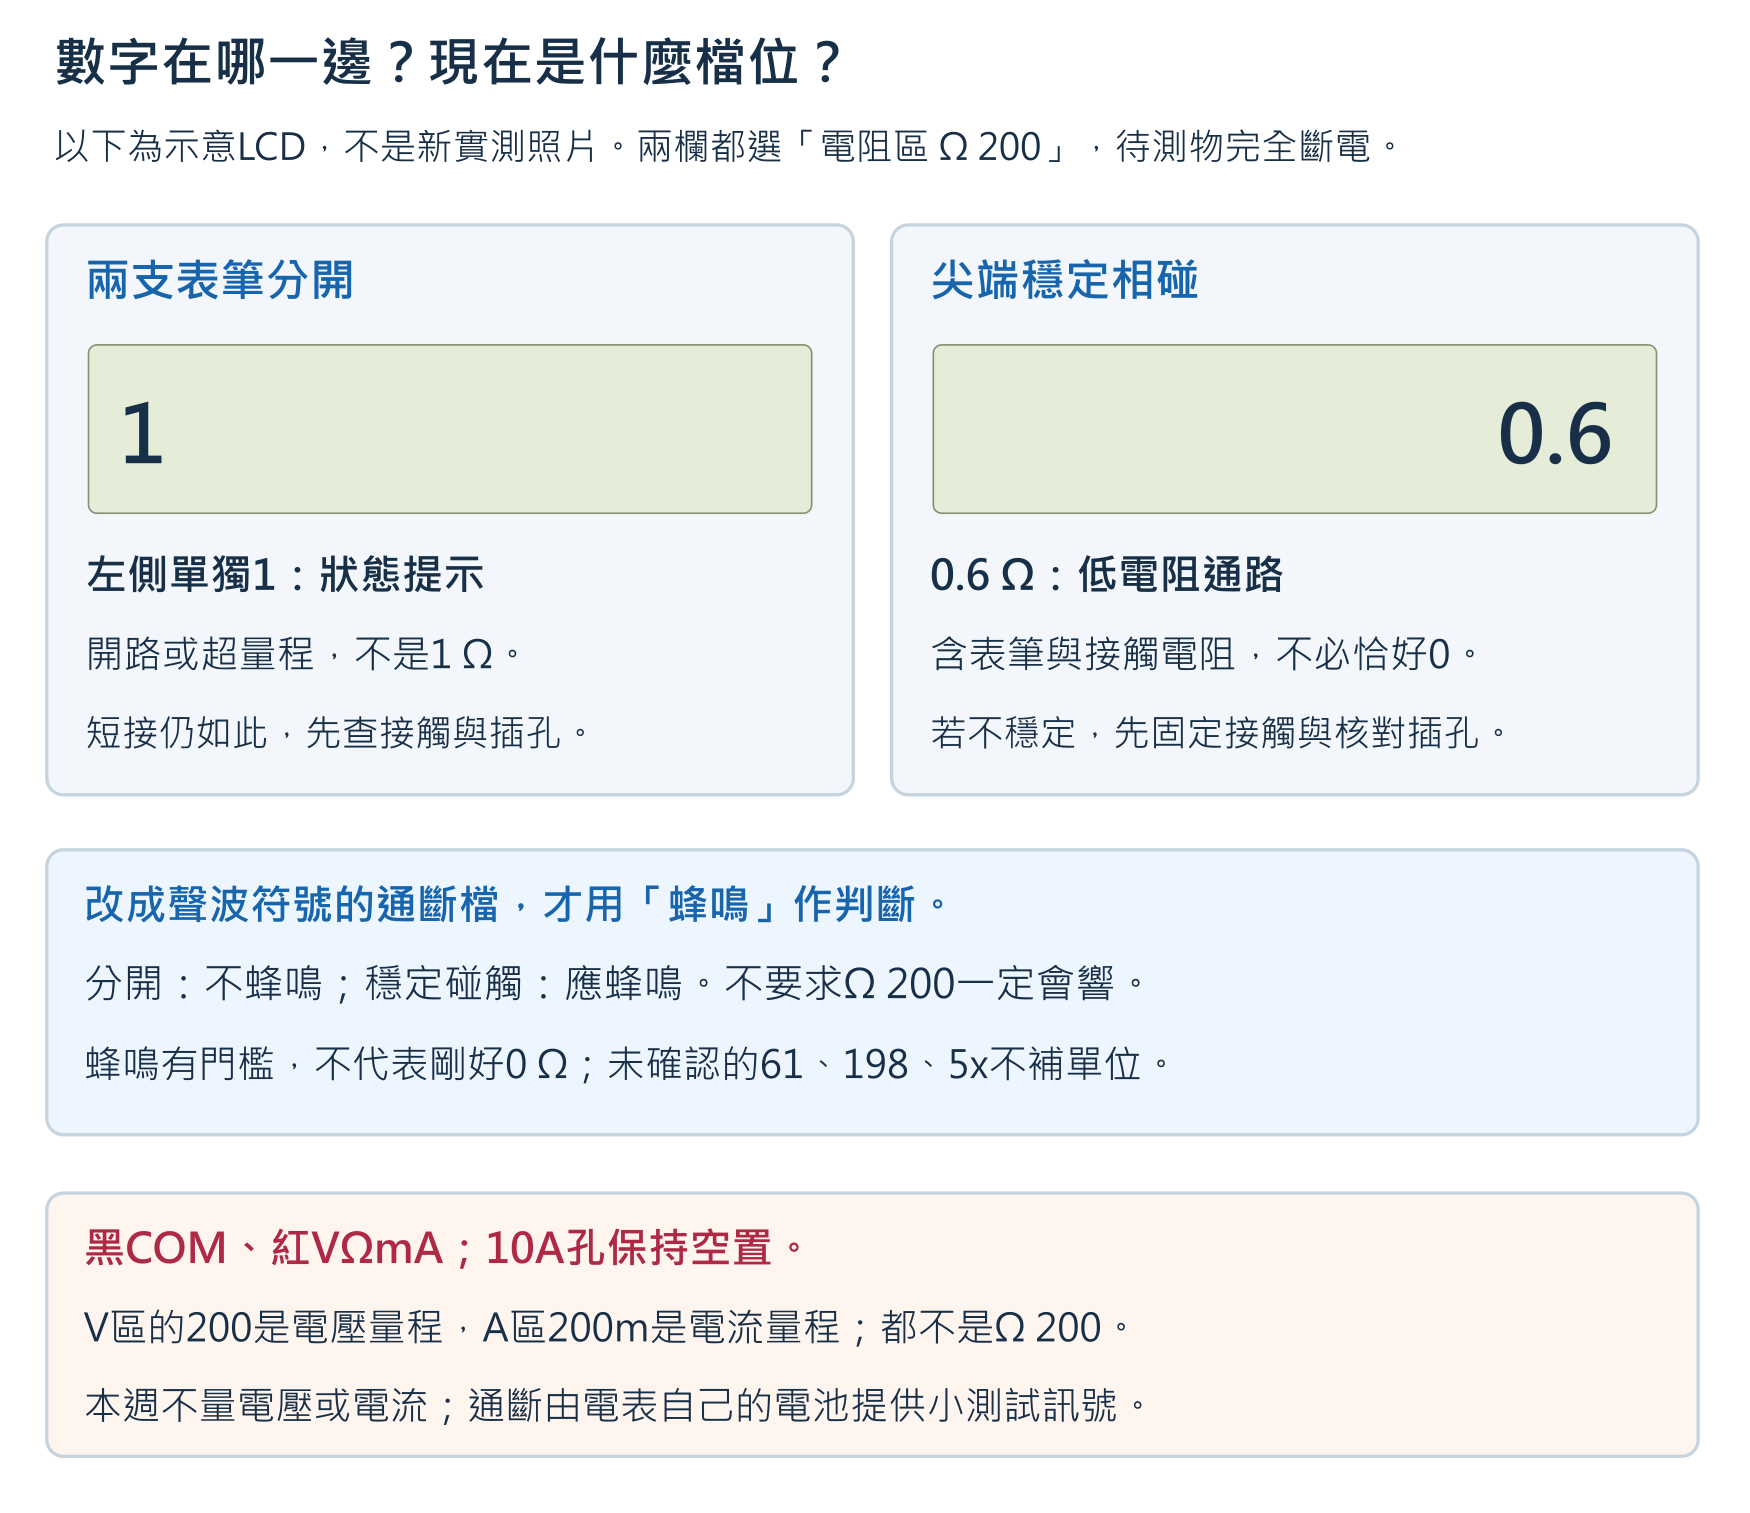

「通斷檔」是continuity test的常用中文名稱，「導通測試」也是同類稱呼，不是本課自創。
它由電表內部電池提供小測試訊號，所以**ESP32不接USB也能測得蜂鳴**。這不表示麵包板
自行發電；相反地，不應讓外部供電干擾這項測試。參考
[Fluke導通測試說明](https://www.fluke.com/en-us/learn/blog/digital-multimeters/how-to-test-for-continuity)。

先保存一組自我檢查：電表型號、表筆孔、所選功能、分開結果、穩定短接結果。
只寫「61」還不夠：若是200Ω檔且畫面確為61.0，才讀成61Ω；若是在蜂鳴檔，不能
未核對顯示方式就把數字一律當成歐姆。對短接金屬而言偏高時，先穩定接觸、核對
小數點及表筆插頭，不能改口說元件必定壞了。

### 本節檢核

- [ ] 黑COM、紅VΩmA，10A孔空著；待測物USB與電池已拔除。
- [ ] 通斷檔下：表筆分開不蜂鳴、穩定短接會蜂鳴。
- [ ] 若用200Ω確認數值，已辨認小數點、Ω及最左側超量程的1。
- [ ] 電表與表筆接觸能穩定；不穩定時先停止用它判定其他元件。

接著保持ESP32斷電，依第八節做麵包板、按鈕與TPO／TPG測試。完成後把電表OFF
並移開表筆，直到Week 3才改用電壓檔；本週不要求補交電壓或散裝電阻數字。


<a id="w2-breadboard"></a>

## 八、麵包板與按鈕接線

### 步驟 1：斷開 USB 電源

1. 關閉 Serial Monitor。
2. 從 ESP32 端拔除 USB 線。
3. 確認板上電源燈熄滅。
4. 等待數秒後，再拿出麵包板、按鈕與杜邦線。

後面凡是寫「拔除 USB」，都要做到電源燈熄滅。只關閉 Serial Monitor 或只
停止程式，都不等於斷電。

### 步驟 2：確認麵包板導通結構

**麵包板（solderless breadboard）**是不必焊接就能暫時接線的實驗板。方孔
只是讓導線或元件腳進入；真正建立連接的是塑膠外殼下方的金屬彈片。新麵包板
第一次插線可能較緊，應捏住靠近金屬針的黑色接頭，讓公針垂直進孔並穩定下壓。
公針若開始彎曲就停止，不使用鉗子硬壓，也不把較粗的萬用電表表筆插進孔內。

本課實物是有`a～j`及`1～30`座標、左右各有紅藍電源軌的400孔麵包板：

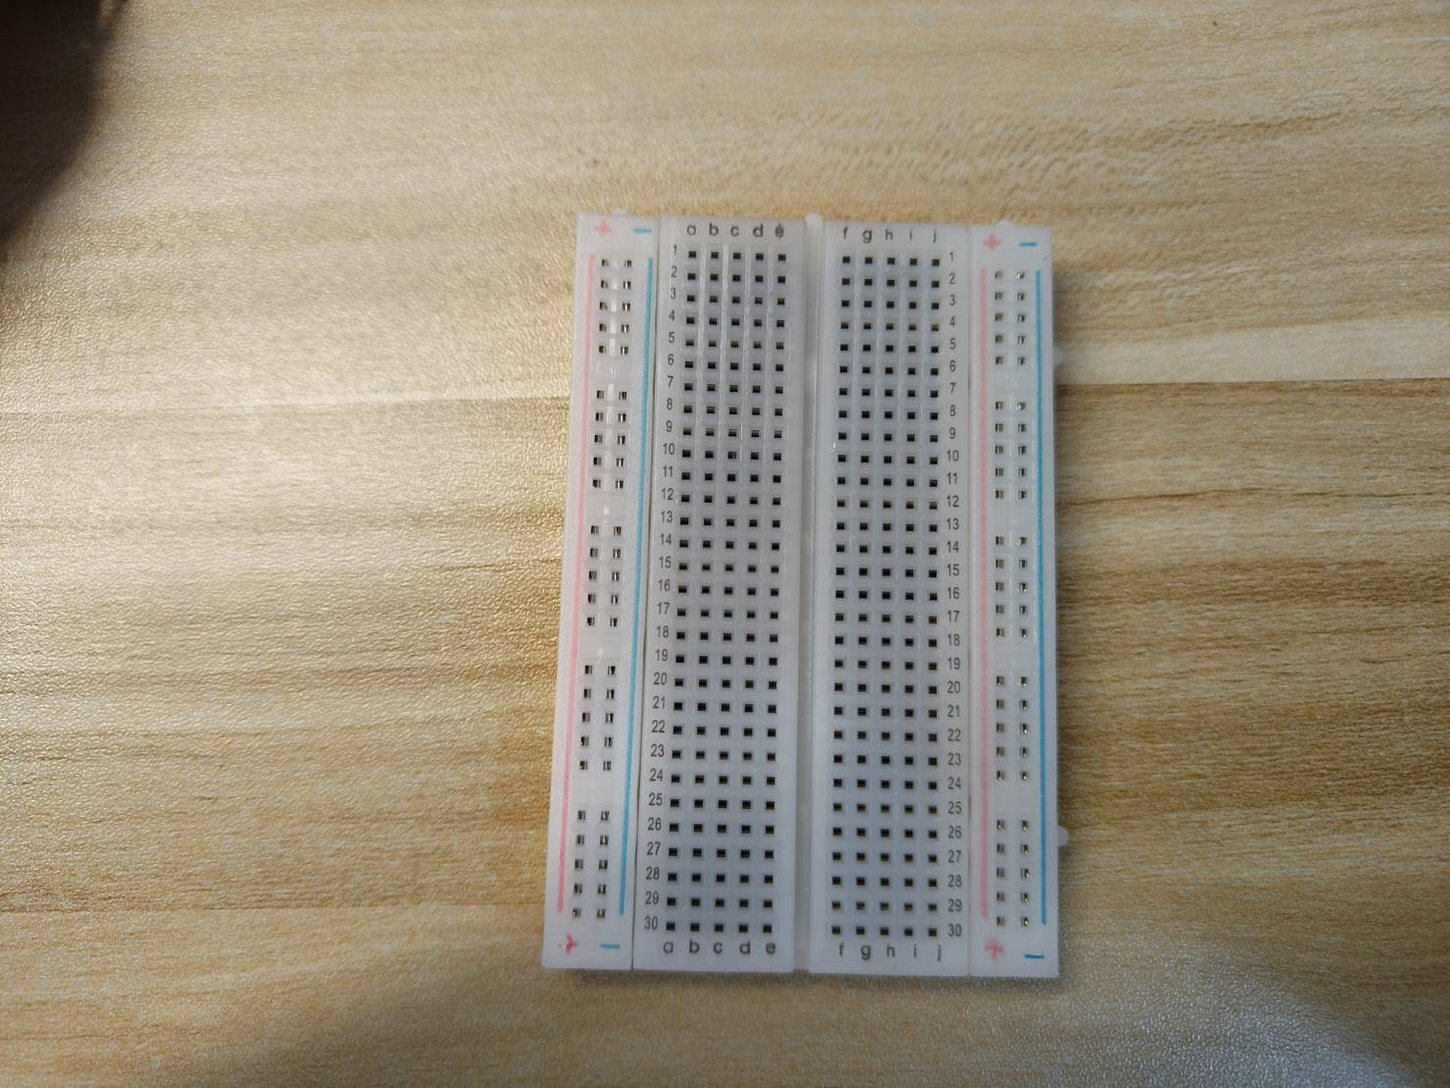

本課杜邦線實物包含公對公、公對母與母對母。插入麵包板時要使用有裸露金屬
公針的一端；顏色只協助整理線路，不會改變電氣功能。

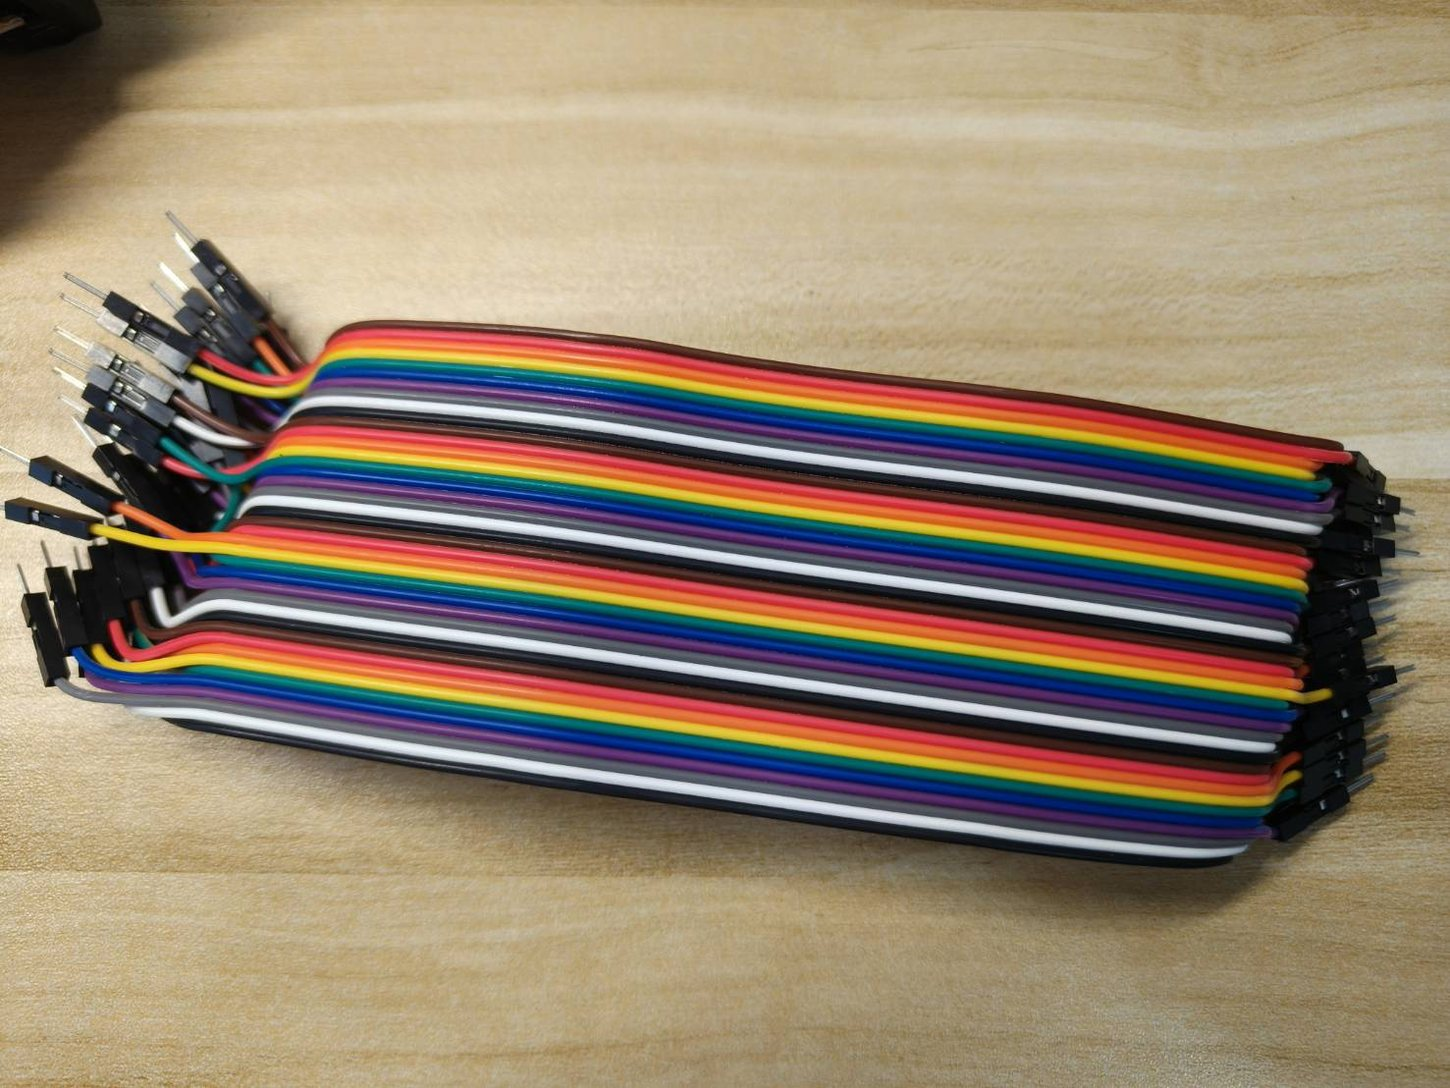

#### 中央實驗區的座標與五孔組

把麵包板直放、列號由上往下增加時，同一列可畫成：

```text
a10—b10—c10—d10—e10   │   f10—g10—h10—i10—j10
       左側五孔組       │          右側五孔組
                        │
                     中央溝槽
```

- `a10～e10`由同一片金屬彈片連接。
- `f10～j10`是另一片獨立金屬彈片。
- `e10`與`f10`雖然列號相同，仍被中央溝槽隔開。
- `a10`與`a11`雖然上下相鄰，仍屬不同列，不會自動連接。

這表示插在同一五孔組中的零件腳在電氣上屬於同一個**節點（node）**。例如兩支
零件腳同時插在`a10`與`b10`，並不是形成兩段串聯電路，而是把兩支腳直接接在
同一節點。

#### 斷電實測麵包板內部結構

開始狀態：使用**沒有插按鈕、開發板或橋接線**的空麵包板。按鈕插入後可能把
跨槽兩點連起來；不能把空板預期套用到已接元件的板子。電表已依第七節自我檢查。

下列測試使用兩條公對公杜邦線延伸測點。ESP32、USB及電池必須全部斷開；黑表筆
留在`COM`、紅表筆留在`VΩmA`，旋鈕使用聲波符號的通斷檔。先短接兩支表筆確認
會蜂鳴，再將杜邦線公針垂直插入指定孔，表筆只碰另一端外露的金屬針。

| 實際測點 | 本批實物測得 | 可以支持的判斷 |
|---|---|---|
| `a10`與`b10` | 有聲音 | 同列、同側的相鄰孔導通 |
| `a10`與`e10` | 有聲音 | 左側同一列的五孔組從`a`到`e`導通 |
| `a10`與`f10` | 沒聲音 | 中央溝槽兩側不相通 |
| `a10`與`a11` | 沒聲音 | 不同列不相通 |
| 左側紅色軌最上方與最下方 | 有聲音 | 這片實物的左紅色軌全長導通 |
| 左側紅色軌與左側藍色軌 | 沒聲音 | 左紅、左藍為兩條獨立路徑 |
| 左側紅色軌與右側紅色軌 | 沒聲音 | 左右兩條紅色軌獨立；同色不代表已連接 |

蜂鳴表示電表偵測到低於內部門檻的低阻抗路徑，不表示電阻一定恰好是`0.0Ω`。
沒聲音表示目前測點之間沒有低阻抗連接；先檢查公針、孔位及表筆接觸後，才能
把結果判為麵包板內部獨立。這些結果只適用於本次實物；其他麵包板仍要實測。

#### 紅色`+`、藍色`−`與GND

邊緣紅藍長列稱為**電源軌（power rail）**。紅線、藍線、`+`與`−`都只是印在
塑膠上的接線慣例，不是電源：沒有接USB、電池或電源供應器時，兩條軌都不會
自行產生電壓。

| 實際接法 | 紅色軌的電氣狀態 | 藍色軌的電氣狀態 |
|---|---|---|
| 兩條都沒有接電源 | 未供電 | 未供電 |
| 紅色接ESP32 `3V3`、藍色接`GND` | 相對GND為約+3.3V | 0V參考點／GND |
| 經驗證的外部5V正端接紅色軌、電源GND接藍色軌 | 相對GND約+5V | 0V參考點／GND；本週不實作 |
| 顏色接反 | 可能實際成為GND | 可能實際成為正電源；容易誤接，不採用 |

**電壓（voltage）**是兩點之間的電位差。**GND（ground）**是電路選定的0V
共同參考點，不是「裝滿負電」的地方。單一正電源系統通常把電源負端接到GND，
所以藍色`−`軌常被用作GND；這是接線選擇，不是藍色印刷自動造成。若使用正負
雙電源，`−5V`可能低於GND，此時負電源與GND就不是同一個節點。

可以用樓層理解相對關係：GND像定義為0樓的地面，`3V3`像高出3.3V的位置，
`−5V`則像低於地面的地下樓層。選定地面後才能描述其他位置比它高或低。

本週這一段只做斷電通斷測試，不把紅藍軌接到`3V3`、`5Vin`或GND。稍後的GPIO
核心線路直接建立TPO與TPG測點，不依賴電源軌；這可以減少初學階段誤接電源的
機會。

**TP** 是 Test Point（測試點）的縮寫。`TPO`和`TPG`不是麵包板原廠名稱，
而是本實驗定義的標籤：TPO接profile指定的測試輸出，TPG接GND。

先在紀錄紙寫下測點名稱，不把線色當作訊號：

```text
測試輸出：TPO
共同GND：TPG
TPO 預留列：________
TPG 預留列：________
```

TPO與TPG必須是兩個不同的空白五孔組。本課ESP32放在麵包板旁，不壓在板上。

### 步驟 3：確認四腳按鈕結構

本課按鈕是**常開瞬時按鈕（normally open momentary pushbutton）**：平常
兩組接點彼此不導通，只有按住時兩組才導通，放開後立即恢復。**導通**表示
兩點之間有可通過測試電流的低阻抗路徑；**開路／不導通**表示路徑中斷。

四支腳不是四個完全獨立的接點。按鈕內部先把兩腳連成A組，另外兩腳連成B組：

```text
A1 ●────● A2       未按：A組與B組分開
        [按鈕]      按住：A組與B組接通
B1 ●────● B2       放開：A組與B組再次分開
```

外觀看見的左、右、上、下不能直接當作固定答案；元件方向改變後，畫面上的位置
也會改變。必須用通斷檔找出哪兩腳原本就是同一組，再選A組的一腳與B組的一腳
作為開關兩端。

先把按鈕固定在麵包板再量，避免一人同時握元件與兩支表筆。使用兩條公對公線延伸
測點，外露金屬針分開平放；只捏絕緣接頭，表筆碰延長端，不把粗表筆插進方孔。
接觸不穩就找同組同學協助，不靠更大力按壓取得「正確數字」。

先觀察並安裝按鈕，這是本週唯一一次安裝：

1. 選兩個相隔約兩列的空白位置，例如第27與第29列。
2. 預定讓四腳進入`E27`、`F27`、`E29`、`F29`，使本體跨在中央溝槽上。
3. 四支腳必須自然對孔，不得扳到明顯變形。
4. 四腳對孔後，對按鈕本體平均施力；確認穩固，再用通斷檔確認兩組接點。
   把下方的已驗證方向當作比較，不把它當成省略自己量測的理由。

若實物腳距不同，列號可以改，但必須同時滿足「跨槽」、「四腳自然對孔」與
「通斷量測已找出兩組接點」。

本課實物跨在中央溝槽、四腳位於`E27`、`F27`、`E29`、`F29`時，2026-08-29
實測如下：

| 測點 | 未按按鈕 | 判讀 |
|---|---|---|
| `a27`與`j27` | 有聲音 | 第27列兩腳是內部原本相通的同一組 |
| `a27`與`j29` | 沒聲音 | 第27列與第29列是不同組 |
| `a27`與`j29`，按住按鈕 | 有聲音 | 按下後兩組接通 |
| `a27`與`j29`，再次放開 | 沒聲音 | 瞬時按鈕已恢復開路 |

**下圖是「未按也會響」的同組測點示例，不是最後的跨組開關測點。**
照片兩條延長線在a27與j27；要觀察按下才導通，需依上表選a27與j29。

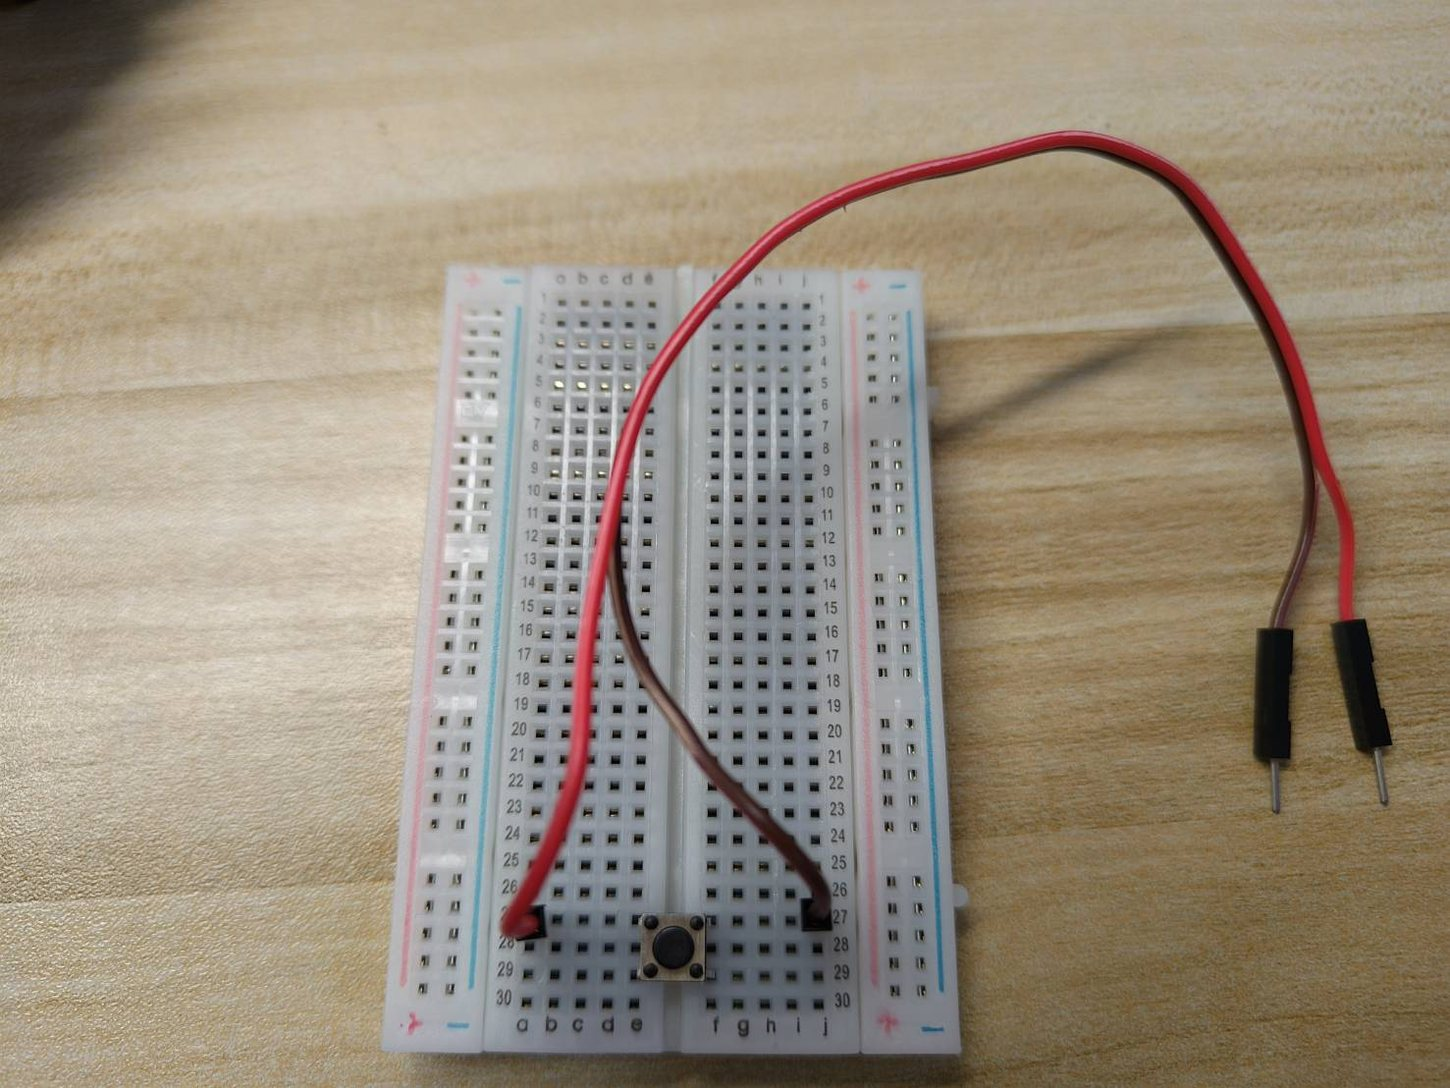

第一次用`a27`與`j27`測到蜂鳴不是按鈕損壞，也不是電源短路；兩點只是被按鈕
內部的固定金屬接點連在同一組。把其中一個測點改到第29列後，才能觀察按下與
放開造成的狀態變化。這項結論只適用於已量測的實物與方向；換按鈕或旋轉方向
後要重新確認。

### 步驟 4：用實物確認開發板與麵包板尺寸

**排針（pin header）**是開發板兩側向下的金屬接腳。是否能直接安裝，必須看
排針實際進入哪一欄，不能用開發板黑色PCB邊緣推測。

本批YD板與400孔麵包板在斷電狀態下實際對孔，結果是：

```text
中央實驗區： A  B  C  D  E  │  F  G  H  I  J
                 ▲                         ▲
              左排排針                  右排排針

左排：B3～B24，共22腳
右排：J3～J24，共22腳
```

第3列到第24列包含22個孔位，與開發板左右各22腳、合計44腳相符。對孔只能辨認幾何位置，
不是要求把排針壓進去；也不能把B、J座標當成GPIO功能。

**下圖只是對孔比較，板子當時尚未壓入；不是最後實驗接法。後續把ESP32放在麵包板旁。**

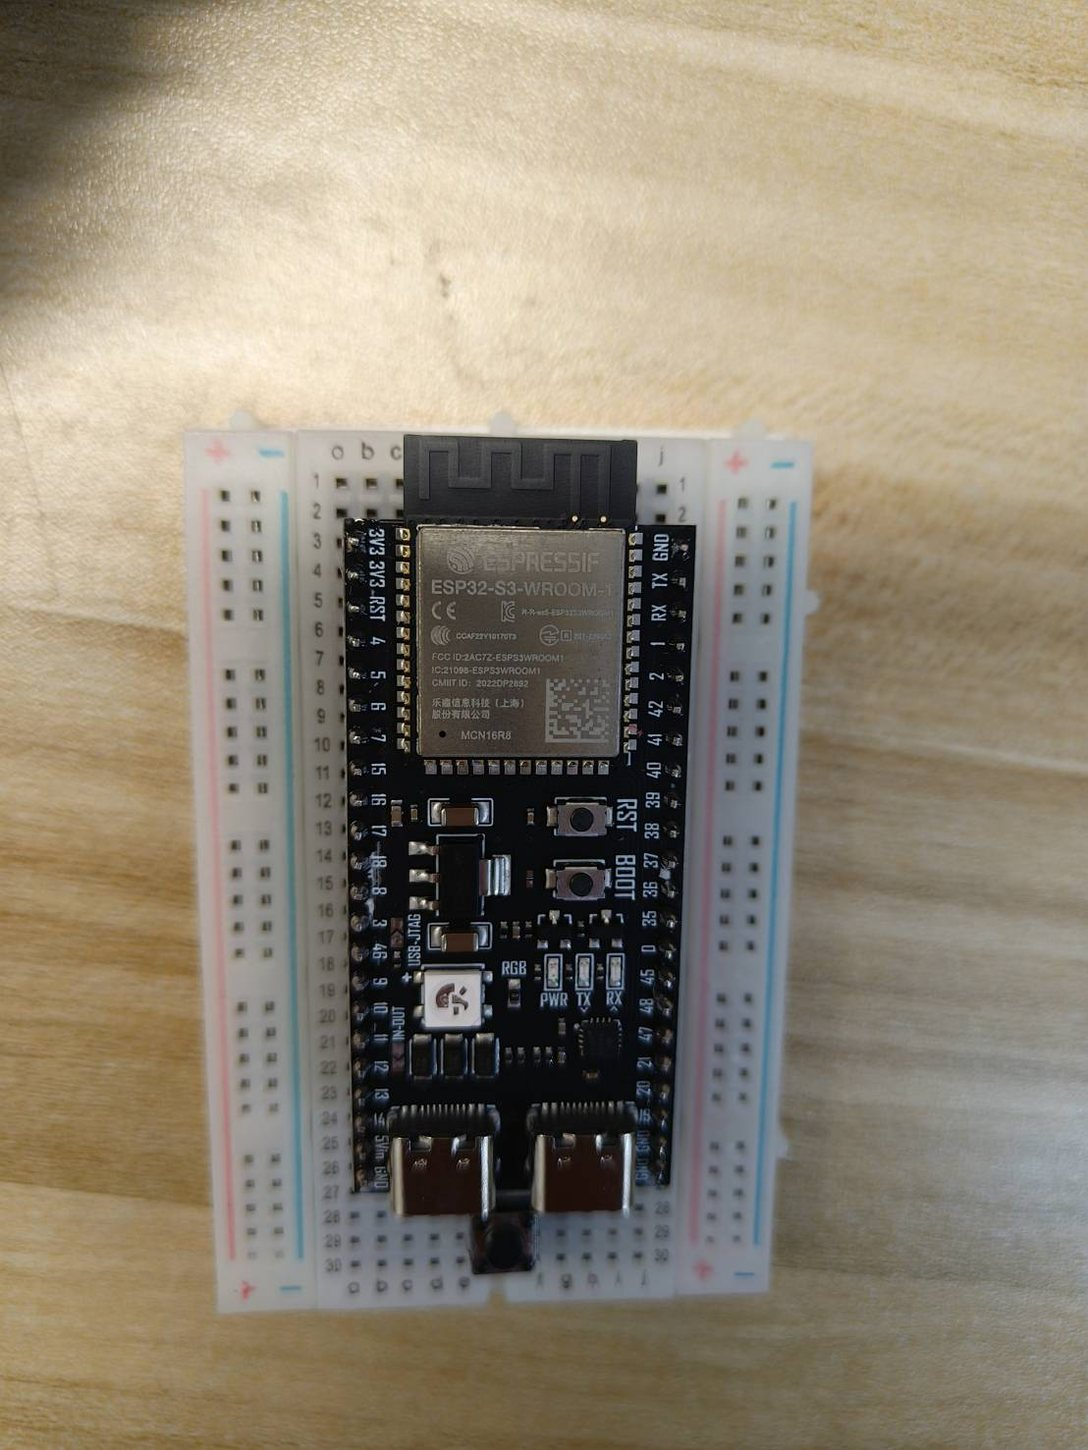

這個位置只在左側留下`A`欄，右側`J`欄已被排針占用；右排GPIO沒有同一列的
空孔可接杜邦線。開發板USB端也遮住第27與第29列的外接按鈕。因此本課不把
BOARD-T01直接壓入單片400孔麵包板，也不要求學生購買另一種麵包板；改用已在
必買清單內的公對母杜邦線進行板外連接。

若板子只是懸在孔上，直接垂直拿起。若已壓入：

1. 確認USB、電池與所有其他電源都已拔除。
2. 不拉天線、USB接頭、BOOT或RST按鈕。
3. 兩手捏住PCB兩端的板邊，先把一端抬高約1～2 mm，再換另一端抬高相同距離。
4. 兩端交替、小幅度向上移動，使兩排排針大致平行退出；不可一次把一端大幅
   翹起，也不可用金屬螺絲起子撬板。
5. 取下後檢查44支排針是否仍平行；發現彎針就停止，不自行帶電測試。

<a id="w2-wiring"></a>

### 步驟 5：採用板外公對母杜邦線

**公對母杜邦線（male-to-female jumper wire）**一端是可套在開發板排針上的
母頭，另一端是可插入麵包板的公針。BOARD-T01放在麵包板旁的乾燥、不導電
平面，不讓排針碰到金屬；USB端保持可插拔，線材不能懸吊或拉扯板子。

本週的三條開發板至麵包板連線都採以下形式：

```text
ESP32板身排針 ← 公對母線的母頭
公對母線的公針 → 麵包板指定五孔組
```

先確認教師已公布適用於自己板卡的腳位用途表（GPIO profile）；未公布時只辨認、不接GPIO。
BOARD-T01已有的個別測試與其限制見[驗證範圍說明](#w2-profile-status)，不能直接推廣到其他板。
取得適用的profile後填寫下表，實際接線統一在步驟7完成：

| 訊號 | 板身絲印／profile | 杜邦線顏色 | 麵包板目的地 |
|---|---|---|---|
| 按鈕輸入 | `PIN_BUTTON`：_____ |  | `BTN-A`接點組 |
| 測試輸出 | `PIN_TEST_OUTPUT`：_____ |  | TPO獨立五孔組 |
| 地 | `G`／GND |  | TPG獨立五孔組 |

排線可以沿塑膠相連的接縫輕輕分出所需條數；不是剝掉線皮，也不是用剪刀剪金屬線。
公頭有露出的細金屬針，母頭是可套排針的孔。先辨認兩端，不從整排的顏色猜公母。

顏色只用來追蹤線路，不會自動決定正電、負電或GND。母頭必須套在已由絲印與
profile確認的單一排針，不能一次跨到相鄰兩腳；公針垂直插入麵包板，開始彎曲
就停止施力。

### 步驟 6：保留已確認的按鈕方向

第三步已完成跨槽安裝與三態測試，不必拆下重裝。只核對按鈕仍穩固、方向未變，
並在紀錄上標出`BTN-A`及`BTN-B`對應的兩列。
若剛才移動開發板時碰動按鈕，才在斷電狀態重查未按不蜂鳴、按住蜂鳴、放開不蜂鳴。
沒有通過這三態檢查前，不接ESP32的GPIO。

### 步驟 7：完成實驗接線

下表以示範板BOARD-T01的配置說明接線；自己的GPIO編號仍須依教師公布的適用profile。線色只用於追蹤，不是所有組都必須相同。

| 順序 | 線材與顏色 | ESP32端 | 麵包板端 | 作用 |
|---|---|---|---|---|
| 1 | 棕色公對母 | 右排最上方`GND` | 公頭插`a22` | 建立TPG接地參考列 |
| 2 | 紅色公對母 | 左排`GPIO4`（示範） | 公頭插`a27` | 連到按鈕`BTN-A`接點組 |
| 3 | 橘色公對母 | 左排`GPIO5`（示範） | 公頭插`a20` | 建立TPO輸出量測列 |
| 4 | 另一條公對公，顏色另行記錄 | 一端插`b22` | 另一端插`a29` | 從同一TPG分接GND到按鈕`BTN-B`接點組 |

目前按鈕跨中央溝槽，左側兩腳位於`e27`與`e29`。同一列左半部`a`至`e`五孔彼此導通，因此`a27`會連到`e27`，`a29`會連到`e29`。`a20`至`e20`是TPO，`a22`至`e22`是TPG；第20列與第22列彼此不導通。右半部按鈕腳`f27`與`f29`本次不接線。

```text
左半部孔位        目前連接
a20─b20─c20─d20─e20   橘色GPIO5；TPO量測列
a22─b22─c22─d22─e22   棕色GND；b22再分接至a29
a27─b27─c27─d27─e27   紅色GPIO4；e27是按鈕一側
a29─b29─c29─d29─e29   來自TPG；e29是按鈕另一側
```

此接法不使用紅藍電源軌、`3V3`、`5Vin`或右排下方GND。插線期間ESP32必須保持USB斷開。三條公對母線的母頭只套住指定的單一排針，不能同時碰到相鄰排針。

依上表同一順序操作，一次只插一條線；USB保持拔除，每條接好才勾選：

1. [ ] 棕色公對母：GND → `a22`，建立TPG接地列。
2. [ ] 紅色公對母：`PIN_BUTTON` → `a27`，連到按鈕`BTN-A`。
3. [ ] 橘色公對母：`PIN_TEST_OUTPUT` → `a20`，建立TPO輸出列。
4. [ ] 公對公：`b22 → a29`，把TPG接到按鈕`BTN-B`。

此接法只使用板上一個 GND：TPG 是共同接地列，再從 TPG 分接到按鈕。四條
杜邦線分別是`PIN_BUTTON→BTN-A`、`GND→TPG`、`TPG→BTN-B`、
`PIN_TEST_OUTPUT→TPO`。

本週的電氣關係必須是：

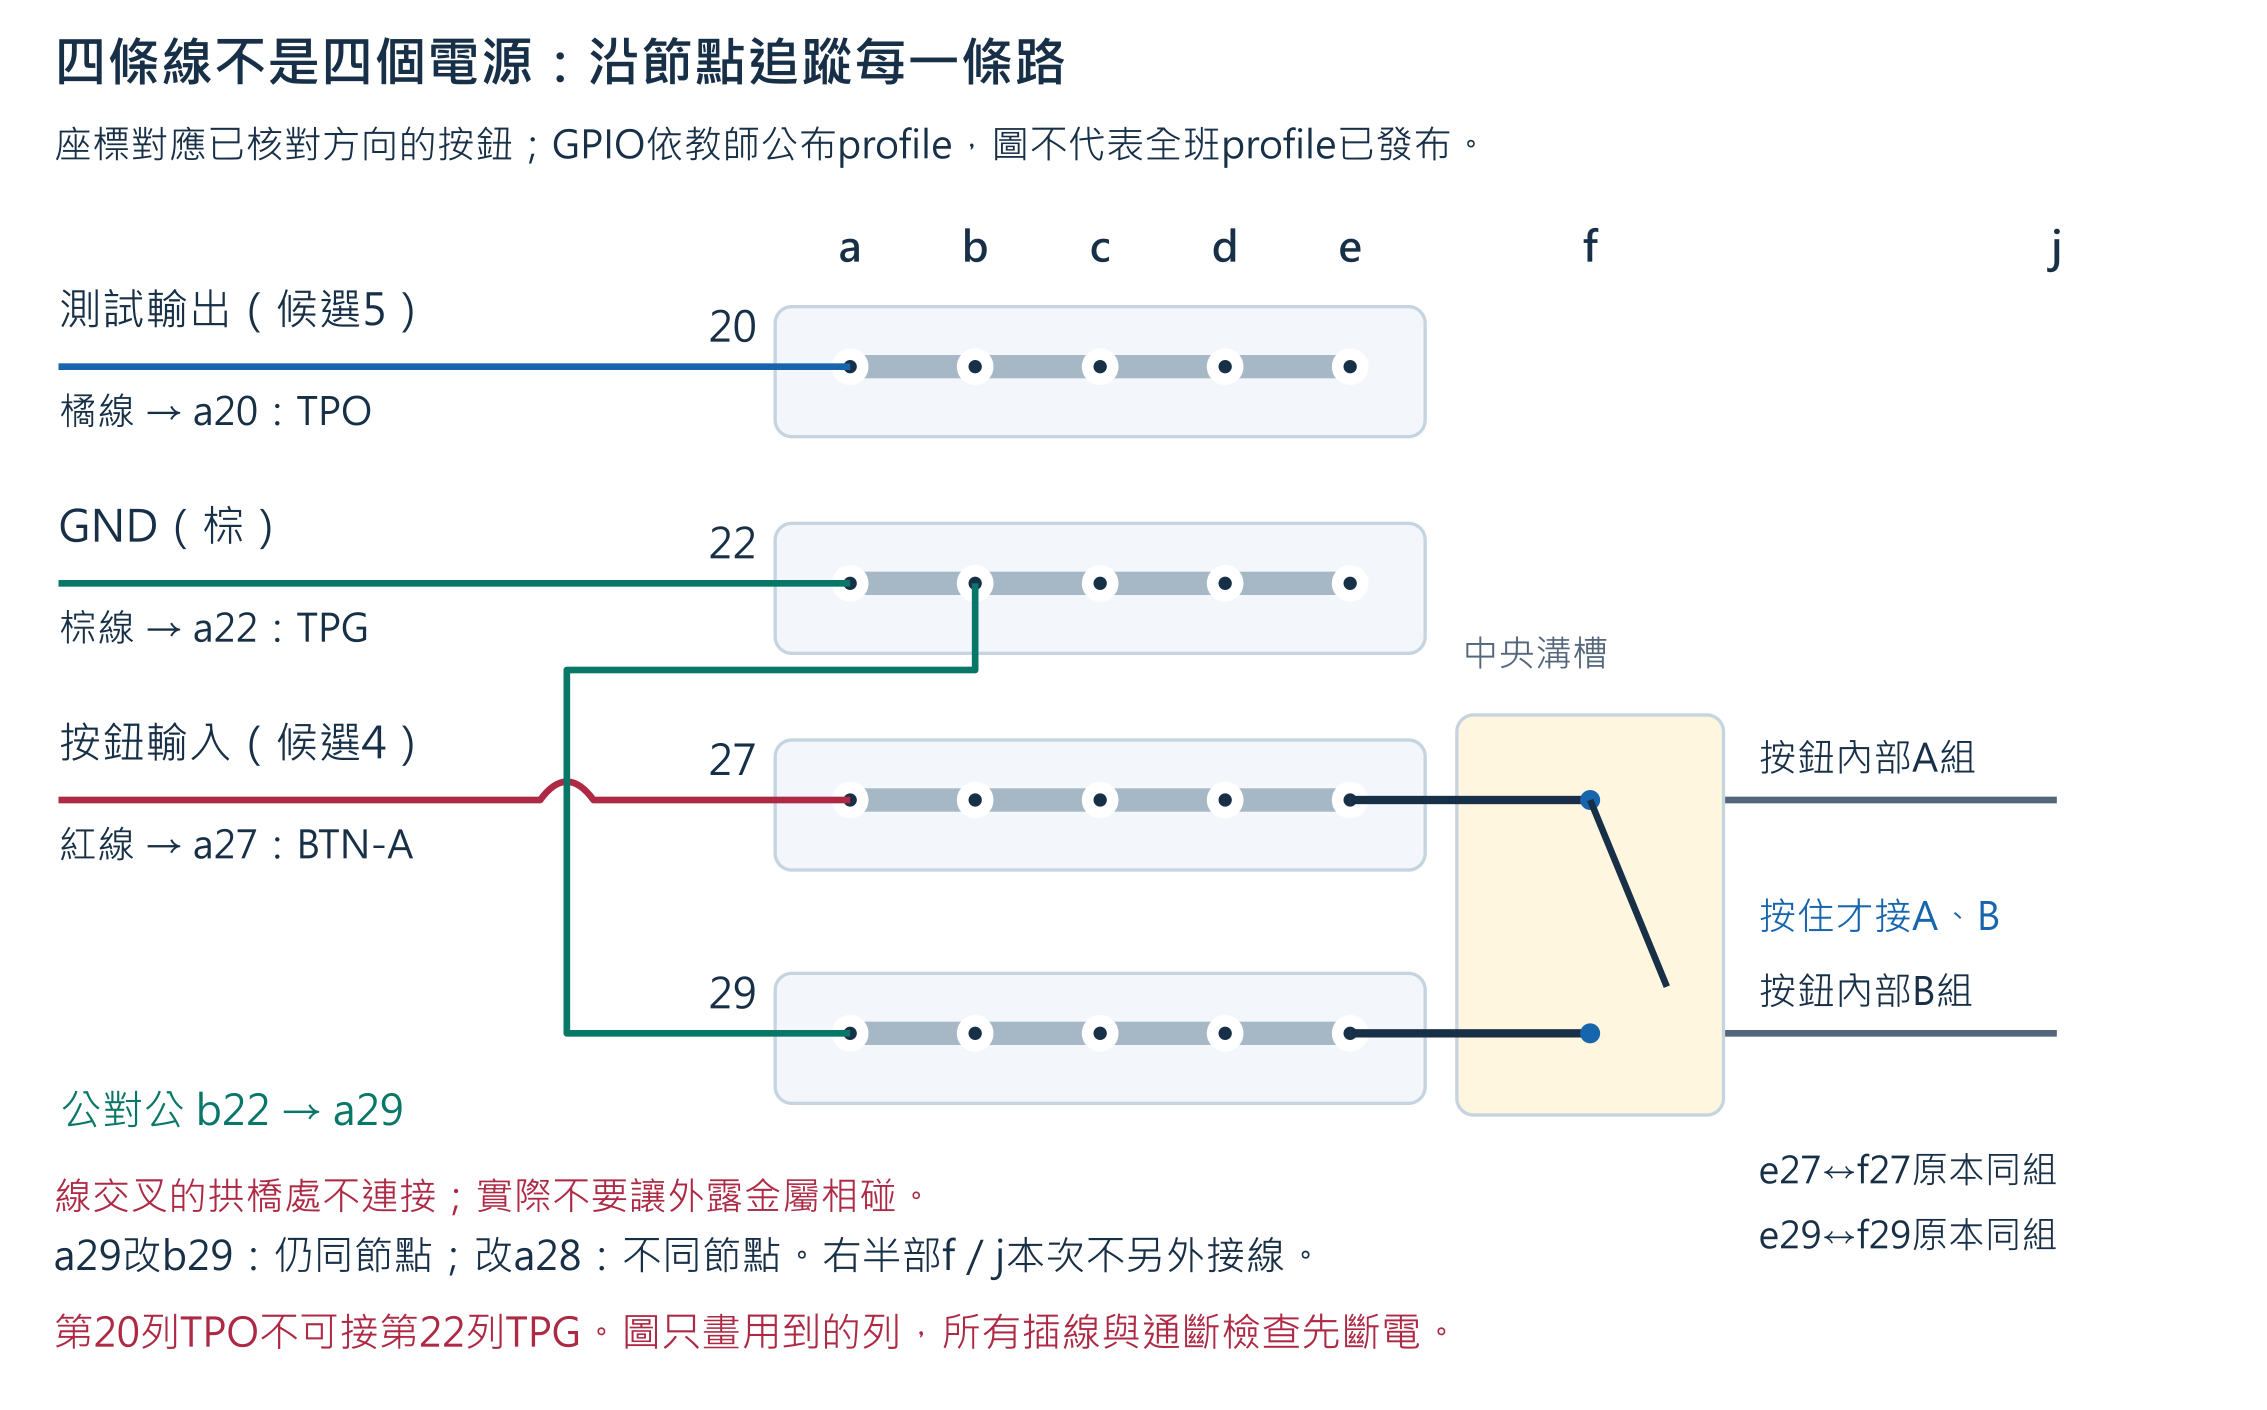

```text
ESP32 PIN_BUTTON ---- 按鈕的一側
ESP32 GND  --------- 按鈕的另一側
```

另外建立兩個安全量測點，不要直接用表筆在相鄰排針間探測：

```text
ESP32 PIN_TEST_OUTPUT -- 麵包板空白列（標記為 TPO）
ESP32 GND  --------- 麵包板另一空白列（標記為 TPG）
```

TPO本週只接`PIN_TEST_OUTPUT`與**斷電檢查時的延長測點**，不接其他模組。
上電前移開電表；黑TPG／紅TPO的直流電壓量測到Week 3才操作。

本接法在程式中使用 `INPUT_PULLUP`，不需要額外外接上拉電阻：

- 未按下：讀到 `HIGH`。
- 按下：`PIN_BUTTON`被接到GND，讀到`LOW`。

### 步驟 8：執行上電前接線檢查

不能只看接線「像不像圖片」，必須從訊號起點沿線檢查到終點：

1. 依profile指著`PIN_BUTTON`的板身絲印，確認母頭只套住該排針，再沿線
   走到按鈕`BTN-A`接點組。
2. 指著板身`G`／GND，確認母頭只套住GND排針，再沿線走到TPG，接著從TPG
   走到按鈕`BTN-B`接點組。
3. 依profile指著`PIN_TEST_OUTPUT`的板身絲印，確認母頭只套住該排針，再沿線
   走到標記TPO的獨立列。
4. 再從TPG反向沿線回到板身GND，確認沒有誤套相鄰排針。
5. 確認TPO與TPG不在同一個五孔導通組。
6. 確認沒有任何線接到 `5V`、`3V3` 或未使用的 GPIO。
7. 從正上方拍一張能看清板身絲印與線路終點的照片。

完成逐線檢查後，先準備兩條**暫時量測用**公對公線，不改動四條主接線：
一條插`e22`延伸TPG，另一條插`e27`延伸按鈕輸入列。
把外露自由端分開平放於不導電桌面；表筆只碰這些公針，不插孔、不探相鄰板身排針。
先追線確認每個自由端對應的列，再做兩項斷電測試：

1. 黑表筆碰TPG的e22延長端，紅表筆碰按鈕輸入的e27延長端。
   放開不應蜂鳴；按住應蜂鳴；再次放開應恢復不蜂鳴。
   一人操作時先安置好延長端；接觸無法穩定就請同學協助，不用手捏裸金屬。
2. 移開並放下表筆，電表OFF，**USB仍拔除**。只把暫時量測線的插孔端從e27
   移到e20，其餘線不動。重新選通斷檔，黑表筆仍碰e22延長端，紅表筆碰e20延長端。
   此時不應持續蜂鳴；若持續蜂鳴，代表TPO與GND之間量到低阻抗路徑，保持斷電查線。

兩項都符合後，移開表筆、電表OFF，取下兩條暫時量測用線，保留四條主接線；
**USB暫時保持拔除**。
完成本節檢核後，才依第九節的單一上電步驟接回USB，不在兩節之間反覆上電。

#### 為什麼第二項通斷測試可以偵測低阻抗短路？

萬用電表的通斷測試模式會使用電表內部電池，在兩支表筆之間施加很小的測試訊號，再判斷測得的路徑是否足夠低阻。不同電表的蜂鳴門檻可能不同，因此不能把『蜂鳴』解讀成電阻一定正好為0Ω；它代表目前量到低於該電表門檻的低阻抗通路。

黑表筆經e22延長端連到棕色GND線所在的a22，兩孔屬於同一五孔組，所以量的是TPG。
紅表筆經e20延長端連到橘色輸出線所在的a20，所以量的是TPO。不是用表筆直接插進孔中。
對已公布使用此候選腳的profile，量測等效關係是：

```text
紅表筆 ── e20延長端 ── TPO ── 橘色線 ── GPIO5
                                      ?
黑表筆 ── e22延長端 ── TPG ── 棕色線 ── GND
```

若接線錯誤使GPIO5與GND之間出現很低阻抗的直接通路，電表的小測試電流可以完成路徑並持續蜂鳴。此時若上電後再把GPIO5設定為HIGH，GPIO5會嘗試輸出接近3.3V，卻同時被低阻抗路徑拉到0V，可能造成過大電流。因此先在斷電狀態檢查，可在使用系統電源前找出這類錯接。

沒有蜂鳴只表示目前沒有量到低於蜂鳴門檻的GPIO5對GND通路。它不能證明GPIO5腳位選對、HIGH／LOW輸出正常、實際電壓正確，也不能排除高阻漏電、接觸不良或GPIO5與其他接腳之間的錯接。這些項目仍須以接線追蹤、上電程式、Serial輸出與直流電壓量測分別驗證。

#### 接法改一個孔，是否仍然相同

`b22 → a29`若改成`b22 → b29`，在沒有其他改線的前提下仍接到同一個
第29列左側五孔組，因此等效。若改成`b22 → a28`，第28列與第29列獨立，就
沒有接到按鈕e29。這是座標判讀，不要求再改一次接線。

同理，TPO a20移到b20仍是同點；移到a22卻把輸出併到GND，會造成風險。
**有聲音不必然壞，沒聲音不必然好**：同一節點應導通，應隔離的兩點才不應導通。

### 本節檢核

- [ ] ESP32未直接插在單片400孔麵包板；排針筆直，板外位置穩定。
- [ ] 三條板對板連線使用公對母杜邦線，母頭各自只套住一支已確認排針。
- [ ] 按鈕四腳自然插入並跨過中央溝槽。
- [ ] 已用通斷檔找出`BTN-A`與`BTN-B`，並完成未按、按住、再次放開三態測試。
- [ ] `PIN_BUTTON`只經按鈕連到GND。
- [ ] `PIN_TEST_OUTPUT`只連到TPO。
- [ ] TPG連到GND，而且TPO、TPG不互通。
- [ ] 接線已依上述方式逐線確認；獨自操作時已完成正向與反向兩次檢查。


<a id="w2-gpio"></a>

## 九、按鈕輸入與測試輸出

### GPIO 與按鈕原理

- **輸入**是 GPIO 接收外部狀態；**輸出**是程式讓 GPIO 產生狀態。
- **HIGH／LOW** 是數位邏輯的兩種狀態。ESP32 的 HIGH 通常接近 3.3V、LOW
  接近 0V，但實際數值仍要用電表量測。
- **`INPUT_PULLUP`** 把 GPIO 設成輸入並啟用內部上拉電阻：按鈕未按時預設
  HIGH，按下接到 GND 時變成 LOW，因此本接法不需外加上拉電阻。
- **浮動**是輸入沒有被明確維持在 HIGH 或 LOW，可能把電氣雜訊誤認成按鈕
  動作；內部上拉可避免未按時浮動。
- 本節先使用30 ms穩定判斷完成正常按鈕流程；去抖的正式定義、逐步計時與比較，
  集中在第十節，不把單次成功當成所有情況都可靠。

### 步驟 1：上電前確認與 USB 復電

1. 確認階段 4 的接線檢查項目已全部通過。
2. 確認沒有人握著按鈕、杜邦線或萬用電表表筆。
3. 把 USB 接回原本測試成功的 USB-to-UART 接頭。
4. 觀察數秒；若出現發熱、異味或異常聲音，立刻拔除 USB。
5. 正常時只開 Arduino IDE，不要在上電後移動任何接線。

### 步驟 2：建立按鈕測試程式

`PIN_TEST_OUTPUT`本週不接LED、蜂鳴器、馬達或其他負載；本實驗先用Serial確認
程式已發出HIGH／LOW命令，實際輸出電壓移到Week 3以萬用電表驗證。**負載**是從電路取得能量的裝置，例如 LED、蜂鳴器
或馬達；GPIO 不適合直接供應高電流負載。

#### 程式結構

- `const int`建立不應改變的整數名稱，本程式用它替profile的兩個GPIO命名。
- `bool` 只保存 `true`／`false`，用來表示是否按下。


#### 先讀懂GPIO名稱與數字的對應

<a id="w2-profile-status"></a>

**GPIO profile**是教師依確切板卡核對並公布的腳位用途表，不是IDE自動產生的選單。
先分清「示範板已有的證據」與「自己板卡可使用的設定」：

| 對象 | 既有證據 | 使用限制 |
|---|---|---|
| 示範板BOARD-T01的GPIO4 | 已回報五次按鈕按下LOW、放開HIGH的輸入事件 | 只支持當時這片板與該接線的按鈕功能 |
| 同片板的GPIO5 | 後續Week 3已回報穩態LOW約0 V、HIGH約3.3 V | 不代表Reset瞬間電壓、帶負載行為或其他板已驗證 |
| 其他板卡與學生組別 | 仍須核對各自實物與適用profile | 不可把示範板編號直接當成全班固定答案 |

以上是[既有硬體紀錄](../docs/hardware/hardware_state.md)的摘要，不是本次新增實測，
也不要求在Week 2重做Week 3電壓實驗。

尚未取得適用profile時，程式保留以下預留值（placeholder）：

```cpp
const int PIN_BUTTON = -1;
const int PIN_TEST_OUTPUT = -1;
```

`-1`表示「尚未設定」，不是實際GPIO編號；`profileReady()`會阻止硬體功能啟動。
取得profile後才填入對應值。程式只能擋住負值或兩個名稱使用同一GPIO，不能辨認填錯的正整數。
下面以示範板使用的GPIO4與GPIO5解釋語法，不代替學生板卡的核對。

以下以示範板的GPIO4拆解名稱與數值的對應；實際程式仍由適用profile填值：

| 程式部分 | 意思 | 本次對應 |
|---|---|---|
| `const` | 這個名稱建立後不應在程式執行途中改成別的數值 | 按鈕測試期間固定使用同一支GPIO |
| `int` | 儲存整數的資料型別 | GPIO編號以整數表示 |
| `PIN_BUTTON` | 程式自訂、可讀的名稱 | 看到名稱便知道它負責按鈕輸入 |
| `=` | 在這行把右側數值指定給左側名稱 | 建立名稱與GPIO編號的對應 |
| 示範值`4` | ESP32-S3的GPIO4編號 | 對應BOARD-T01板身絲印`4`；不是4V，也不是從板邊數來的第4支腳 |
| `;` | 一個C++敘述的結尾 | 少了通常會造成Compile失敗 |

第二行的語法相同，但把`PIN_TEST_OUTPUT`對應到GPIO5：

```text
程式中的 PIN_BUTTON      → 整數4 → 板身GPIO4 → 紅線 → 按鈕
程式中的 PIN_TEST_OUTPUT → 整數5 → 板身GPIO5 → 橘線 → TPO
```

使用名稱的原因是讓後面的程式表達用途。例如
`digitalRead(PIN_BUTTON)`比`digitalRead(4)`更容易看出正在讀按鈕，也能在經過
實機驗證後只修改最前面的對應值，避免在整支程式到處尋找裸露的GPIO數字。

這兩行只建立軟體名稱與編號的對應，尚未設定接腳方向，也不會讓GPIO4或GPIO5
立即產生電壓。真正啟用按鈕輸入與測試輸出的是稍後在`setup()`執行的
`pinMode(PIN_BUTTON, INPUT_PULLUP)`與`pinMode(PIN_TEST_OUTPUT, OUTPUT)`。
自己板卡的GPIO仍以適用profile為準；編譯成功不能代替接線與實物核對。

- `unsigned long` 可保存非負整數，本程式用來保存 `millis()` 毫秒時間。
- `setup()` 開機後執行一次；`loop()` 之後持續重複。
- `pinMode()` 設定接腳模式，`digitalRead()` 讀取 HIGH／LOW，
  `digitalWrite()` 輸出 HIGH／LOW。
- `Serial.printf()` 把文字與變數組合成一行 log；`%s` 放文字，`%lu` 放
  `unsigned long` 數值，`\n` 表示換行。

完整來源：[week02_button_input.ino](../examples/week02_button_input/week02_button_input.ino)。

1. 在 Arduino IDE 點 **File → Save As**。
2. 新名稱輸入 `week02_button_groupXX`，將 `XX` 改成兩位數組別。
3. 確認視窗標題已變成新名稱，避免覆蓋前一個 Serial 練習。
4. 按 **Ctrl+A** 全選舊程式，再貼上下列完整程式。
5. 把 `CHANGE_ME` 改成組別，例如第 3 組改成 `03`，保留雙引號。
6. 按 **Ctrl+S**。


In [ ]:
// 由教師公布的同批板卡target-test profile填入；未公布時保持-1。
const int PIN_BUTTON = -1;
const int PIN_TEST_OUTPUT = -1;
const char *GROUP_ID = "CHANGE_ME";

bool experimentReady = false;
bool stablePressed = false;
bool lastRawPressed = false;
unsigned long changedAtMs = 0;
const unsigned long DEBOUNCE_MS = 30;

bool profileReady() {
  return PIN_BUTTON >= 0 && PIN_TEST_OUTPUT >= 0 &&
         PIN_BUTTON != PIN_TEST_OUTPUT;
}

void setup() {
  Serial.begin(115200);
  delay(500);

  if (!profileReady()) {
    Serial.println("week=2 status=blocked reason=gpio_profile_missing");
    return;
  }

  pinMode(PIN_TEST_OUTPUT, OUTPUT);
  digitalWrite(PIN_TEST_OUTPUT, LOW);
  pinMode(PIN_BUTTON, INPUT_PULLUP);
  lastRawPressed = digitalRead(PIN_BUTTON) == LOW;
  changedAtMs = millis();
  if (lastRawPressed) {
    Serial.println("week=2 status=blocked reason=release_button_then_reset");
    return;
  }
  experimentReady = true;

  Serial.printf("boot: week02 group=%s button-test version=1\n", GROUP_ID);
  Serial.println("state: released input=HIGH test_output=LOW");
}

void loop() {
  if (!experimentReady) return;
  bool rawPressed = digitalRead(PIN_BUTTON) == LOW;
  unsigned long now = millis();

  if (rawPressed != lastRawPressed) {
    lastRawPressed = rawPressed;
    changedAtMs = now;
  }

  if (now - changedAtMs >= DEBOUNCE_MS && rawPressed != stablePressed) {
    stablePressed = rawPressed;
    digitalWrite(PIN_TEST_OUTPUT, stablePressed ? HIGH : LOW);

    Serial.printf(
      "group=%s event=button_changed pressed=%s input=%s test_output=%s time_ms=%lu\n",
      GROUP_ID,
      stablePressed ? "true" : "false",
      stablePressed ? "LOW" : "HIGH",
      stablePressed ? "HIGH" : "LOW",
      now
    );
  }
}


貼上程式後先做人工檢查：

- [ ] `PIN_BUTTON`與`PIN_TEST_OUTPUT`已填入教師公布的profile，不再是`-1`。
- [ ] 兩個GPIO值不同，`GROUP_ID`已改成自己的組別。
- [ ] 程式只有一組`setup()`與一組`loop()`，最後的大括號完整。

### 步驟3：Verify、Upload與Serial

1. 按 **Verify**。容量摘要中的`Sketch uses`表示程式空間用量，`Global variables
   use`表示編譯時可計算的全域與靜態資料用量；兩者未超過`Maximum`才通過容量
   檢查。這些數字會隨程式與套件版本改變，不是全班固定答案。
2. Verify成功後再次核對 **Tools → Board**與 **Tools → Port**。
3. 關閉Serial Monitor，按 **Upload**，等待`Hash of data verified`與Reset完成。
4. 放開外接按鈕，再開啟Serial Monitor並選115200 baud，短按一次RST重現開機訊息。
   若出現`release_button_then_reset`，先放開按鈕再RST；若一直出現，斷電查輸入是否被固定接地。

預期開機輸出：

```text
boot: week02 group=03 button-test version=1
state: released input=HIGH test_output=LOW
```

`state`行是程式宣告的啟動狀態。它能證明程式執行到該行，不能取代GPIO電壓量測。
若仍每秒看到舊程式的`uptime_ms`，先核對Port與完整Upload Output，不改接線。

### 步驟4：執行按鈕功能測試

1. 放開按鈕，確認沒有持續重複事件。
2. 按住約一秒，只應新增一筆`pressed=true input=LOW test_output=HIGH`。
3. 放開並等待約一秒，只應新增一筆`pressed=false input=HIGH test_output=LOW`。
4. 再慢速做四次，共五次完整按下與放開。

```text
group=03 event=button_changed pressed=true input=LOW test_output=HIGH time_ms=...
group=03 event=button_changed pressed=false input=HIGH test_output=LOW time_ms=...
```

- `pressed=true input=LOW`表示程式已接受「按下」狀態；`input`文字由stable推導，
  不是另外量一次電壓。實際線路仍需先用通斷與逐線檢查確認。
- `pressed=false input=HIGH`表示放開後由內部上拉恢復HIGH。
- `test_output=HIGH／LOW`是程式執行輸出命令後寫入log的狀態，不是電表實測值。
- `time_ms`是本次Reset後經過的毫秒數；1000 ms等於1秒，不是日期時間。

#### 一個按下，怎樣變成這一行文字

`digitalRead(PIN_BUTTON) == LOW`是一個比較，不是接線動作：讀到LOW時得到true，
讀到HIGH時得到false。bool的true表示「按下」，不等於GPIO電位是HIGH。
`stablePressed ? HIGH : LOW`則是條件選擇：stable為true時命令輸出HIGH，否則LOW。
因此**輸入LOW與輸出HIGH同時出現沒有矛盾**，兩者是不同GPIO、不同工作。

先前一次候選測試的接受事件時間是104914與105096 ms；差182 ms = 0.182秒。
這是程式接受按下與放開兩筆事件的間隔，不是精密量到手指實際接觸182 ms；去抖、
輪詢與列印都可能影響時間。按住不動一秒沒有連印很多行，反而符合「只記狀態改變」。

### 步驟5：依現象排查

| Serial現象 | 第一個安全動作 | 斷電後優先檢查 |
|---|---|---|
| 放開仍出現`release_button_then_reset`，或稍後自行出現`pressed=true` | 拔USB | 輸入是否持續接到GND、按鈕是否用錯同一接點組或接觸不穩 |
| 按下與放開都沒事件 | 拔USB | `PIN_BUTTON`、GND、按鈕跨槽與通斷結果 |
| 一次動作出現很多事件 | 保存log後拔USB | 按鈕是否完全插入、杜邦線是否鬆動，再進行去抖比較 |
| 組別錯誤或仍是舊輸出 | 不動線路 | 修改`GROUP_ID`、Save、Upload並核對Port |
| 完全沒有Serial文字 | 不動線路 | Port、115200 baud、RST與`Serial.begin(115200)` |

所有接線修正都先拔除USB。修正後重新做上電前檢查，再重新計算連續五次；
不能刪除失敗log後只留下成功結果。

### 本節檢核

- [ ] 五次按下與放開都各得到一筆事件，順序完全交替。
- [ ] 能用自己的Serial log解釋LOW、HIGH、`time_ms`與輸出命令。
- [ ] 沒有把Serial中的`test_output`寫成已量到的GPIO電壓。


<a id="w2-discussion"></a>

## 十、Week 2 Discussion：按鈕去抖

本節只討論一個核心問題：人只按一次按鈕，ESP32為什麼可能讀到多次變化，
程式又如何把這些立即讀值整理成一次有效事件。先理解什麼是去抖，再說明
按鈕彈跳如何產生及程式如何完成去抖，最後才從同一概念延伸三項學生練習。

### 10.1 什麼是按鈕去抖

本節以Arduino官方[Debounce按鈕範例](https://docs.arduino.cc/built-in-examples/digital/Debounce/)
及其[`Debounce.ino`原始碼](https://github.com/arduino/arduino-examples/blob/main/examples/02.Digital/Debounce/Debounce.ino)
為基準。**按鈕去抖（button debouncing）**是程式不把每一次短暫HIGH／LOW變化
都立即當成有效事件，而是先等待讀值穩定，再接受新的按鈕狀態。Arduino官方
範例說明這樣做是為了忽略noise（短暫雜訊或非預期變化）。

去抖不是讓機械接點停止彈跳，也不是讓按鈕本身變慢。它改變的是程式的判斷：
立即讀值可以先被觀察，但只有符合穩定條件的變化才成為系統正式使用的事件。

**raw讀值**是本課對`digitalRead()`當下讀到之HIGH或LOW的教學名稱；
**stable狀態**是本課對維持指定時間後、程式正式接受之狀態的教學名稱。Arduino
官方原始碼使用`reading`、`buttonState`與`lastButtonState`等名稱，沒有規定所有
程式都必須使用`raw`或`stable`。本課使用這兩個標籤，是為了讓log能清楚區分
「現在讀到什麼」和「系統是否已接受」。

### 10.2 按鈕彈跳怎樣產生

本課的四腳輕觸按鈕內部有會移動的金屬接點。按下時接點相碰，可能因彈性與碰撞
短暫分開再碰回；放開時也可能出現快速反覆。這像球落地後小幅反彈的類比，
不是手指真的連按好幾次，也不表示每次都能被程式看見。若只畫出理想結果，按下一次應為：

```text
按下前：HIGH
按下後：LOW
```

但立即讀值可能在正式穩定前短暫改變數次。下圖是用來理解官方演算法的
**教學示意**，不是本片按鈕已量到的波形：

```text
人的動作：     放開 -------------------------- 按下
理想輸入：     HIGH --------------------------- LOW
可能的raw讀值：HIGH -- LOW -- HIGH -- LOW ------ LOW
```

人的動作仍是「按一次」，ESP32的`loop()`卻會快速重複讀取GPIO。如果程式把每次
HIGH／LOW變化都立即當成新狀態，一次動作便可能產生多個事件。機械接點造成的
這類快速變化通常稱為**接點彈跳（contact bounce／switch bounce）**。實際是否
被程式觀察到、多久穩定，須由原始log判讀；log只能顯示被輪詢讀到的變化，不能代替完整電氣波形。

自然產生的是按鈕的**彈跳**；**去抖**則是硬體或程式對這些短暫變化所做的處理。
因此「怎樣產生按鈕去抖」在本節更精確的問題是：程式怎樣根據raw讀值產生一個
可以正式使用的stable狀態。

### 10.3 程式怎樣完成去抖

Arduino官方程式不在讀到一次變化時立刻更新按鈕狀態；它先記錄讀值改變的時間，
等讀值維持不變超過`debounceDelay`後才接受新狀態。本週程式沿用這個核心判斷，
並改寫成可同時輸出raw與stable證據：

1. raw讀值一改變，就記下改變時間`changedAtMs`。
2. 若raw又改變，重新記時；先前等待不算完成。
3. 只有raw連續不變至少`DEBOUNCE_MS`，而且與舊stable狀態不同，才接受新狀態。
4. 接受後才更新`stablePressed`、送出profile測試輸出命令及寫入stable log。

`DEBOUNCE_MS = 30`表示必須穩定30毫秒，即0.03秒。ESP32在這30毫秒內沒有停止；
它仍持續執行`loop()`並檢查raw讀值。這種使用`millis()`的寫法稱為**non-blocking**
（非阻塞）計時，因為沒有用`delay(30)`固定停住loop。但Serial緩衝滿時列印仍可能
等待，不能宣稱整支程式任何時候都不阻塞或能看見每個電氣邊緣。

#### 與Arduino官方範例相同的是方法，不是接線

| 比較項目 | Arduino官方Debounce範例 | 本課ESP32-S3實驗 |
|---|---|---|
| 接線／按下邏輯 | 範例以5V按鈕與外部下拉，按下HIGH | 3.3V邏輯的內部上拉，按下LOW |
| 輸出行為 | 接受按下時切換LED，放開不切換 | 輸出命令跟隨已接受按下／放開狀態 |
| 時間比較 | `> debounceDelay`，範例50 ms | `>= DEBOUNCE_MS`，起始30 ms |
| log與防護 | 原範例不提供本課raw／stable欄位 | 加入兩種log、計數、profile與啟動放開檢查 |

**不能把官方範例的5V、GPIO2／13或LED接線直接搬到ESP32**。本課只採用
「改變後重新計時、穩定後才接受」的機制；以下邊界答案都依本課的`>=`計算。

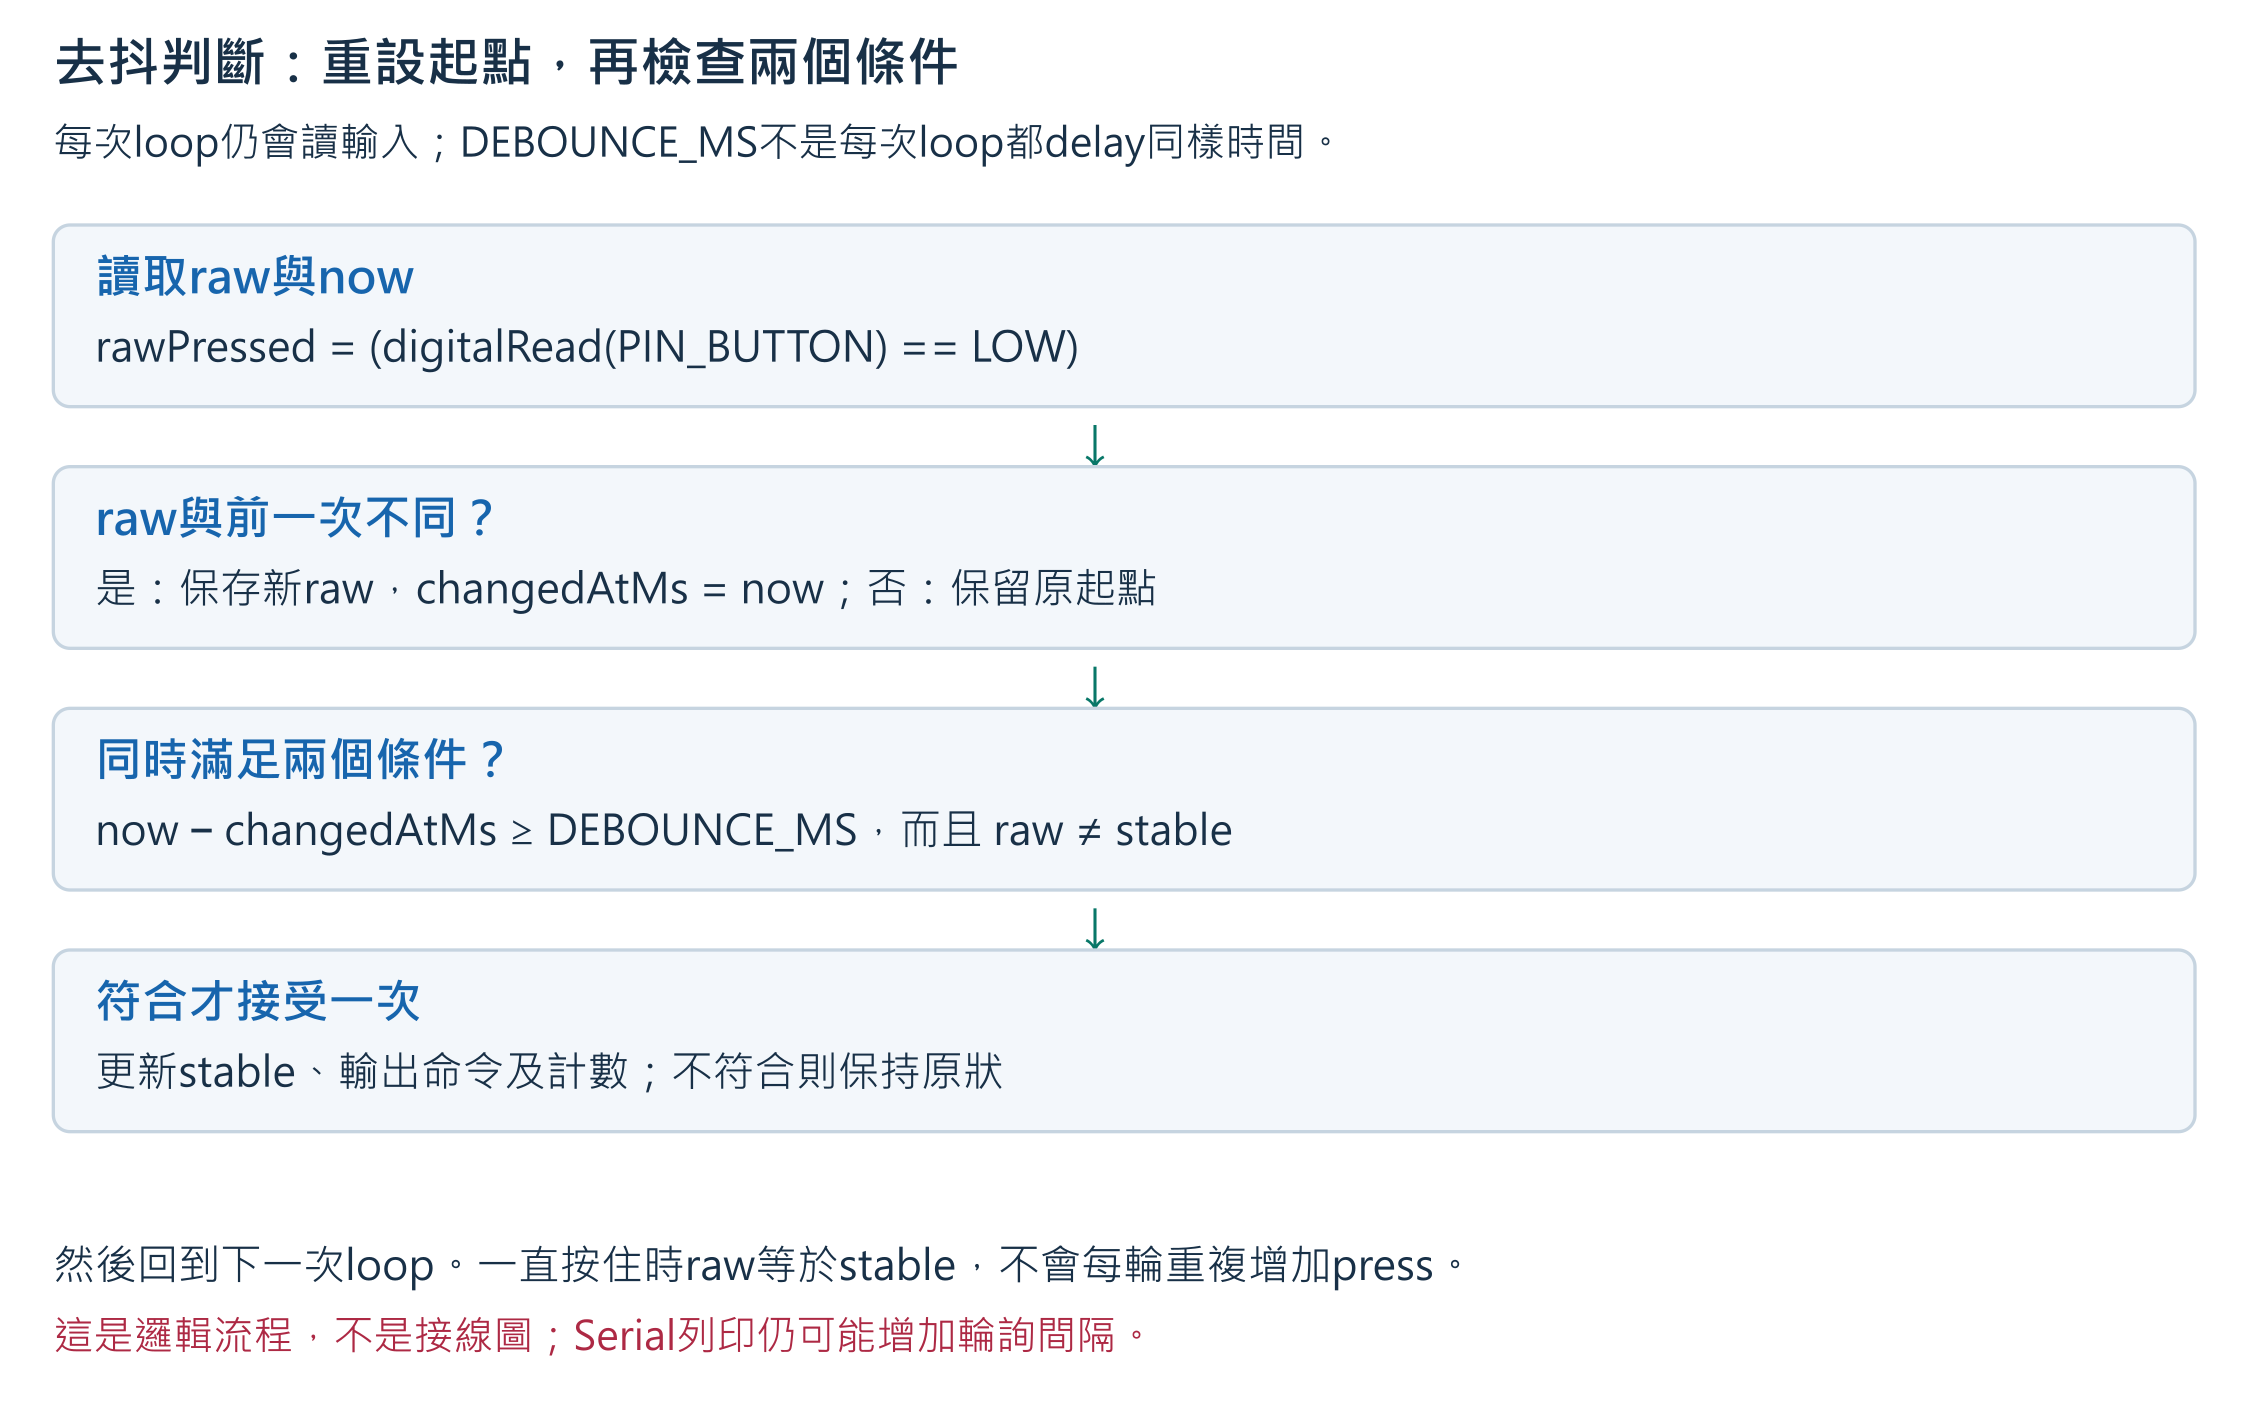

#### 完整示範：為什麼計時會重新開始

假設`DEBOUNCE_MS = 30`，按下瞬間得到下列raw讀值：

| 時間 | raw讀值 | 程式動作 |
|---:|---|---|
| 1000 ms | LOW | raw改變，從1000 ms重新計時 |
| 1003 ms | HIGH | raw又改變，先前3 ms作廢，從1003 ms重新計時 |
| 1008 ms | LOW | raw再次改變，從1008 ms重新計時 |
| 1038 ms | 仍為LOW | LOW已連續穩定30 ms，正式接受`pressed=true` |

這是假設所列變化都被輪詢讀到、1008 ms後維持LOW且程式在1038 ms檢查的理想追蹤。
因此這次人只按一下；raw改變三次，但stable只接受一次。若程式在1000 ms第一次
看到LOW就立即接受，1003 ms可能又被當成放開，1008 ms又被當成第二次按下。

### 10.4 Discussion練習一：自己追蹤去抖計時

不要執行程式，先在紙上分析下列情況。`DEBOUNCE_MS = 30`，原本stable是HIGH：

| raw改變時間 | 新raw讀值 | 此刻是否接受新stable狀態？ | 若不接受，新的計時起點 |
|---:|---|---|---:|
| 5000 ms | LOW |  |  |
| 5006 ms | HIGH |  |  |
| 5011 ms | LOW |  |  |
| 5018 ms | HIGH |  |  |
| 5020 ms | LOW |  |  |

回答三個問題：

1. 假設5020 ms後持續LOW、輪詢能在門檻時刻執行，最早到哪個`time_ms`才接受LOW？
2. 人的動作是一個按下，raw總共改變幾次？
3. stable最終應接受幾次按下？

完成條件：答案同時使用「raw」、「stable」與「連續穩定30 ms」說明，不只填一個
時間數字。

### 10.5 診斷程式：同時觀察raw與stable

下一支程式會印出兩種事件：

- `event=raw_changed`：GPIO立即讀值改變，尚未經去抖。
- `event=stable_changed`：raw已連續穩定到指定時間，程式正式接受事件。

程式中的Serial輸出會增加每次loop所需時間，因此它適合課堂觀察與比較，不是量測
機械彈跳波形的精密儀器。若要觀察微秒級電氣波形，需要示波器或邏輯分析儀；本週
不要求購買或使用。

1. 點 **File → Save As**，另存為`week02_debounce_groupXX`。
2. 以 **Ctrl+A** 全選舊程式，貼上下一格完整程式。
3. 把`CHANGE_ME`換成組別，並填入教師公布的GPIO profile；未公布時保持`-1`，
   程式會阻止實驗啟動。
4. 第一輪保留`DEBOUNCE_MS = 30`，不要先改成其他數字。

Repository中的可執行原始檔是
[`week02_button_debounce_lab.ino`](../examples/week02_button_debounce_lab/week02_button_debounce_lab.ino)；
它與下一格notebook程式必須保持一致。


In [ ]:
// 由教師公布的同批板卡target-test profile填入；未公布時保持-1。
const int PIN_BUTTON = -1;
const int PIN_TEST_OUTPUT = -1;
const char *GROUP_ID = "CHANGE_ME";

const unsigned long DEBOUNCE_MS = 30;

bool experimentReady = false;
bool lastRawPressed = false;
bool stablePressed = false;
unsigned long changedAtMs = 0;
unsigned long rawEdgeCount = 0;
unsigned long acceptedPressCount = 0;
unsigned long acceptedReleaseCount = 0;

bool profileReady() {
  return PIN_BUTTON >= 0 && PIN_TEST_OUTPUT >= 0 &&
         PIN_BUTTON != PIN_TEST_OUTPUT;
}

void setup() {
  Serial.begin(115200);
  delay(500);

  if (!profileReady()) {
    Serial.println("week=2 status=blocked reason=gpio_profile_missing");
    return;
  }

  // 先把輸出暫存值設為LOW，再啟用OUTPUT，降低啟動時意外HIGH的風險。
  digitalWrite(PIN_TEST_OUTPUT, LOW);
  pinMode(PIN_TEST_OUTPUT, OUTPUT);
  pinMode(PIN_BUTTON, INPUT_PULLUP);

  lastRawPressed = digitalRead(PIN_BUTTON) == LOW;
  stablePressed = false;
  changedAtMs = millis();

  if (lastRawPressed) {
    Serial.println("week=2 status=blocked reason=release_button_then_reset");
    return;
  }

  experimentReady = true;
  Serial.printf(
    "boot: week02 group=%s debounce-diagnostic debounce_ms=%lu\n",
    GROUP_ID,
    DEBOUNCE_MS
  );
  Serial.println("state: raw_pressed=false stable_pressed=false test_output=LOW");
}

void loop() {
  if (!experimentReady) return;

  const bool rawPressed = digitalRead(PIN_BUTTON) == LOW;
  const unsigned long now = millis();

  if (rawPressed != lastRawPressed) {
    lastRawPressed = rawPressed;
    changedAtMs = now;
    rawEdgeCount++;

    Serial.printf(
      "group=%s event=raw_changed raw_pressed=%s raw_edge=%lu time_ms=%lu\n",
      GROUP_ID,
      rawPressed ? "true" : "false",
      rawEdgeCount,
      now
    );
  }

  if (now - changedAtMs >= DEBOUNCE_MS && rawPressed != stablePressed) {
    stablePressed = rawPressed;
    digitalWrite(PIN_TEST_OUTPUT, stablePressed ? HIGH : LOW);

    if (stablePressed) {
      acceptedPressCount++;
    } else {
      acceptedReleaseCount++;
    }

    Serial.printf(
      "group=%s event=stable_changed pressed=%s input=%s "
      "test_output=%s accepted_press=%lu accepted_release=%lu "
      "stable_for_ms=%lu debounce_ms=%lu time_ms=%lu\n",
      GROUP_ID,
      stablePressed ? "true" : "false",
      stablePressed ? "LOW" : "HIGH",
      stablePressed ? "HIGH" : "LOW",
      acceptedPressCount,
      acceptedReleaseCount,
      now - changedAtMs,
      DEBOUNCE_MS,
      now
    );
  }
}


#### 逐段讀懂診斷程式

`lastRawPressed`保存前一次立即讀值，`stablePressed`保存已正式接受的狀態。它們
可能暫時不同：例如raw剛變成LOW，但尚未穩定30 ms時，raw表示已按下，stable仍
維持放開。

```cpp
if (rawPressed != lastRawPressed) {
  lastRawPressed = rawPressed;
  changedAtMs = now;
}
```

這段在raw每次改變時重設計時起點。彈跳造成的LOW→HIGH→LOW會讓`changedAtMs`
一再更新，不會把不連續的時間加在一起。

```cpp
if (now - changedAtMs >= DEBOUNCE_MS && rawPressed != stablePressed)
```

這一行必須同時滿足兩個條件：

1. `now - changedAtMs >= DEBOUNCE_MS`：目前raw已連續穩定足夠久。
2. `rawPressed != stablePressed`：穩定後的結果真的與上次接受狀態不同。

若只有第一個條件，按鈕維持不動時可能在每次loop重複印出事件。第二個條件確保
每次穩定狀態轉換只接受一次。

`rawEdgeCount`只要raw改變就增加；`acceptedPressCount`與
`acceptedReleaseCount`只在去抖後接受狀態時增加。10次完整按下與放開的理想結果
是接受10次press及10次release；若每個轉換都被輪詢讀到，理想raw為20次，
彈跳或接觸擾動可能使它更多；比20少也可能是短按未被輪詢看見，不能只歸因於接線。

#### Discussion練習二：觀察自己的按鈕

1. 放開外接按鈕，再按 **Verify**。Compile成功只表示程式可建立，尚未觀察按鈕。
2. 關閉Serial Monitor後按 **Upload**，等待hash驗證與Reset完成。
3. 開啟115200-baud Serial Monitor。若出現`release_button_then_reset`，放開按鈕，
   再按板上RST。
4. 核對boot行中的組別及`debounce_ms=30`。
5. 慢慢按下並保持約1秒，再放開約1秒。先只做一次。
6. 在log中用不同記號標出`raw_changed`與`stable_changed`。
7. 看懂單次log後按一次RST，核對計數已重新從0開始；示範的第一次不列入正式資料。
8. 再做5次慢速按壓及5次快速點按，總共10次正式操作。快速點按只要求同一位
   操作者盡量使用相同方式，不假裝每次時間完全相同。

一個沒有觀察到額外raw變化的例子可能是：

```text
event=raw_changed raw_pressed=true raw_edge=1 time_ms=...
event=stable_changed pressed=true ... stable_for_ms=30 debounce_ms=30 ...
event=raw_changed raw_pressed=false raw_edge=2 time_ms=...
event=stable_changed pressed=false ... stable_for_ms=30 debounce_ms=30 ...
```

若同一次按下在stable接受前出現多筆快速交替的`raw_changed`，這與接點彈跳或線路
接觸擾動相符；先保存log，再確認線路沒有鬆動。若只出現理想的兩筆raw變化，應寫
「本次未觀察到額外raw變化」，不能反過來宣稱機械按鈕永遠不會彈跳。

| 紀錄時點 | 累積實際次數 | 此刻`raw_edge` | 此刻`accepted_press` | 此刻`accepted_release` | 觀察到的額外raw變化或漏失 |
|---|---:|---:|---:|---:|---|
| 完成5次慢速操作後 | 5 |  |  |  |  |
| 再完成5次快速操作後 | 10 |  |  |  |  |

每個檔從boot開始保留到最後放開後至少1秒。計數開機從0開始，但boot不逐一印0；
尚無stable事件時，已接受press／release仍是0。最後一行若只有raw，應分別找最後
raw_edge與最後stable計數，不能把缺少stable誤填成空白或刪掉。慢按5次後在紀錄紙
寫下當時最後time_ms作分段標記；不要把自己整理的註解冒充Serial原始輸出。

完成條件：能從自己的log指出至少一組raw與stable的對應，接受的press及release各為
多少，並使用「觀察到」或「未觀察到」描述結果，不把預期現象寫成實測結果。


### 10.6 Discussion練習三：比較`0／10／30／100 ms`

到這裡才開始改`DEBOUNCE_MS`。四個數字表示raw必須連續穩定多久，程式才接受：

| 設定 | 換算 | 意義 | 可能代價 |
|---:|---:|---|---|
| 0 ms | 0秒 | 不要求額外穩定時間，輪詢讀到變化即可接受 | 可能把彈跳接受成多次事件 |
| 10 ms | 0.01秒 | 某次新raw須被觀察為連續穩定至少10 ms | 較長彈跳仍可能通過 |
| 30 ms | 0.03秒 | 必須穩定約30 ms | 從最後一次raw改變起至少等待30 ms |
| 100 ms | 0.1秒 | 必須穩定約100 ms | 很短的點按可能在被接受前就放開 |

這些是設定含義與可能性，不是預先指定的實測答案。按鈕、線路、程式執行時間與
操作方式都會影響結果。


#### 3-1：先寫預測

在執行前填寫。**預測**是根據目前理解提出可能結果，不是猜教師答案；實際結果
不同時保留原預測，才能比較自己原先的理解。

| 設定 | 預測10次操作會接受幾次press／release | 預測raw是否有額外變化 | 預測快速點按是否可能漏失 | 理由 |
|---:|---|---|---|---|
| 0 ms |  |  |  |  |
| 10 ms |  |  |  |  |
| 30 ms |  |  |  |  |
| 100 ms |  |  |  |  |


#### 3-2：每輪只改去抖時間

「控制變因」在本題的白話意思是：**每一輪只改`DEBOUNCE_MS`，其他條件盡量
維持一樣**。使用同一片ESP32、同一顆按鈕、同一接線、同一位操作者，以及相同的
「5次慢按＋5次快速點按」順序。若同時換線或換按鈕，就無法知道結果是由哪個改變
造成。

1. 先將`DEBOUNCE_MS`改成0，按 **Ctrl+S → Verify → Upload**。
2. 開啟Serial Monitor並按RST，核對boot行確實是`debounce_ms=0`。
3. 做5次慢按與5次快速點按，保存從boot開始的完整log。
4. 最後放開後等待至少1秒，再記raw與stable計數。比實際10次多或少都要逐次追查；
   **總數剛好10也不能排除某次多算、另一次漏算互相抵銷**。press與release分別檢查。
5. 依序改成10及100 ms重做。30 ms可直接使用練習二同樣10次操作的資料，不必
   為湊次數重做；若練習二操作方式不同，才重新測試。
6. 每次Upload後先核對boot行的`debounce_ms`，避免其實仍在執行上一個版本。
7. 完成後恢復`DEBOUNCE_MS = 30`，重新Verify及Upload，保存最後版本。

保存方法：一輪結束後先停止按鈕操作，在Serial Monitor輸出區選取該輪boot行至
最後一筆事件，複製到電腦的純文字編輯器；不要把文字貼到Monitor上方的傳送輸入欄。
另存到自己的Week 2實驗紀錄資料夾，例如`debounce_10ms_run1.txt`。
開啟存檔，核對開頭的`debounce_ms`與最後的計數仍在，再進行下一輪。
若複製漏了開頭，記錄缺漏，不自行編造boot行或事件。

**原始log**是從該輪boot行開始、沒有刪除不理想事件的完整Serial文字。只交最後
三行或手動整理後的表格，無法檢查是否多算、漏算或混入前一輪資料。


#### 3-3：整理結果

每輪開始後計數都從0重新開始。若表格中的最後數字不是由該輪boot後開始，資料就
不能直接比較。

| `DEBOUNCE_MS` | 慢按＋快按 | 最後`raw_edge` | 最後`accepted_press` | 最後`accepted_release` | 多接受／漏失 | `stable_for_ms`觀察 | 原始log檔名 |
|---:|---:|---:|---:|---:|---|---|---|
| 0 ms | 5＋5 |  |  |  |  |  |  |
| 10 ms | 5＋5 |  |  |  |  |  |  |
| 30 ms | 5＋5 |  |  |  |  |  |  |
| 100 ms | 5＋5 |  |  |  |  |  |  |

若四輪全部得到10次press與10次release，這不是失敗。先寫：「四輪最後計數都與操作
總數相符。」逐次對照操作標記與事件後，才可補充「本次未觀察到stable重複或漏失」；
沒有逐次證據就保留不確定。即使全部相符，仍不能證明
0 ms永遠安全，也不能證明其他按鈕、其他操作速度或長期使用都有相同結果。

若0 ms多接受，需回到原始log確認是否同一次實體動作內出現多次stable交替；若
100 ms漏失快速點按，需確認raw是否曾短暫變成true、卻未維持100 ms到stable接受。
若raw本身完全沒有變化，不應直接怪罪去抖門檻；先比對慢按是否看得到，若慢按也
沒有反應再斷電查接線。快速點按可能發生在兩次輪詢之間，即使接線正確也可能漏讀。


#### 3-4：用證據選擇設定

「最好」不是固定數字，而是在本次需求下平衡兩種風險：

- 等待太短：可能把彈跳當成多次有效事件。
- 等待太長：反應較慢，短暫按壓可能被忽略。

使用自己的表格完成下列句子：

```text
我選擇 ______ ms，因為在本次 ______ 次操作中，
accepted_press = ______、accepted_release = ______，
並且觀察到／未觀察到 ____________________________________。

這個結論只適用於 ________________________________________。
若更換按鈕、接線、操作速度或程式，我需要重新測試，因為
__________________________________________________________。
```

完成條件：選擇必須引用自己的數字，同時說明等待太短及太長的代價，並列出至少
一項不能由本次實驗推廣的情況。不能只寫「30 ms最好」或「網路上都這樣設定」。


三項練習形成同一條證據鏈：練習一用時間軸理解演算法，練習二用自己的按鈕
區分raw與stable，練習三只改變去抖時間並用實際資料選擇設定。完成後回到自己的
原始log，確認結論沒有超出本次按鈕、接線、操作次數與程式所能支持的範圍。


<a id="w2-answers"></a>

### 10.7 練習一預期答案：時間從「最後一次變化」起算

先完成10.4的空表，再核對以下完整解析。此處是**紙上理想追蹤，不是實機log**。
假設開始已接受放開，raw HIGH對應`rawPressed=false`；5020 ms之後持續LOW。

| 時間 | 新raw | rawPressed | 是否更新stable | changedAtMs | 原因 |
|---:|---|---|---|---:|---|
| 5000 | LOW | true | 否 | 5000 | 剛改變，只穩定0 ms |
| 5006 | HIGH | false | 否 | 5006 | 又改變；與舊stable相同，也沒有新事件 |
| 5011 | LOW | true | 否 | 5011 | 重新等30 ms，不累加先前6 ms |
| 5018 | HIGH | false | 否 | 5018 | 再重設時間，仍保持已接受的放開 |
| 5020 | LOW | true | 否 | 5020 | 最後一次改變，從這裡重新算 |
| 5049 | 仍LOW | true | 否 | 5020 | 5049 − 5020 = 29，還不足30 |
| 5050 | 仍LOW | true | 是，接受按下 | 5020 | 5050 − 5020 = 30，且raw與stable不同 |
| 5051 | 仍LOW | true | 否，不再重複 | 5020 | 時間夠，但raw已等於stable |

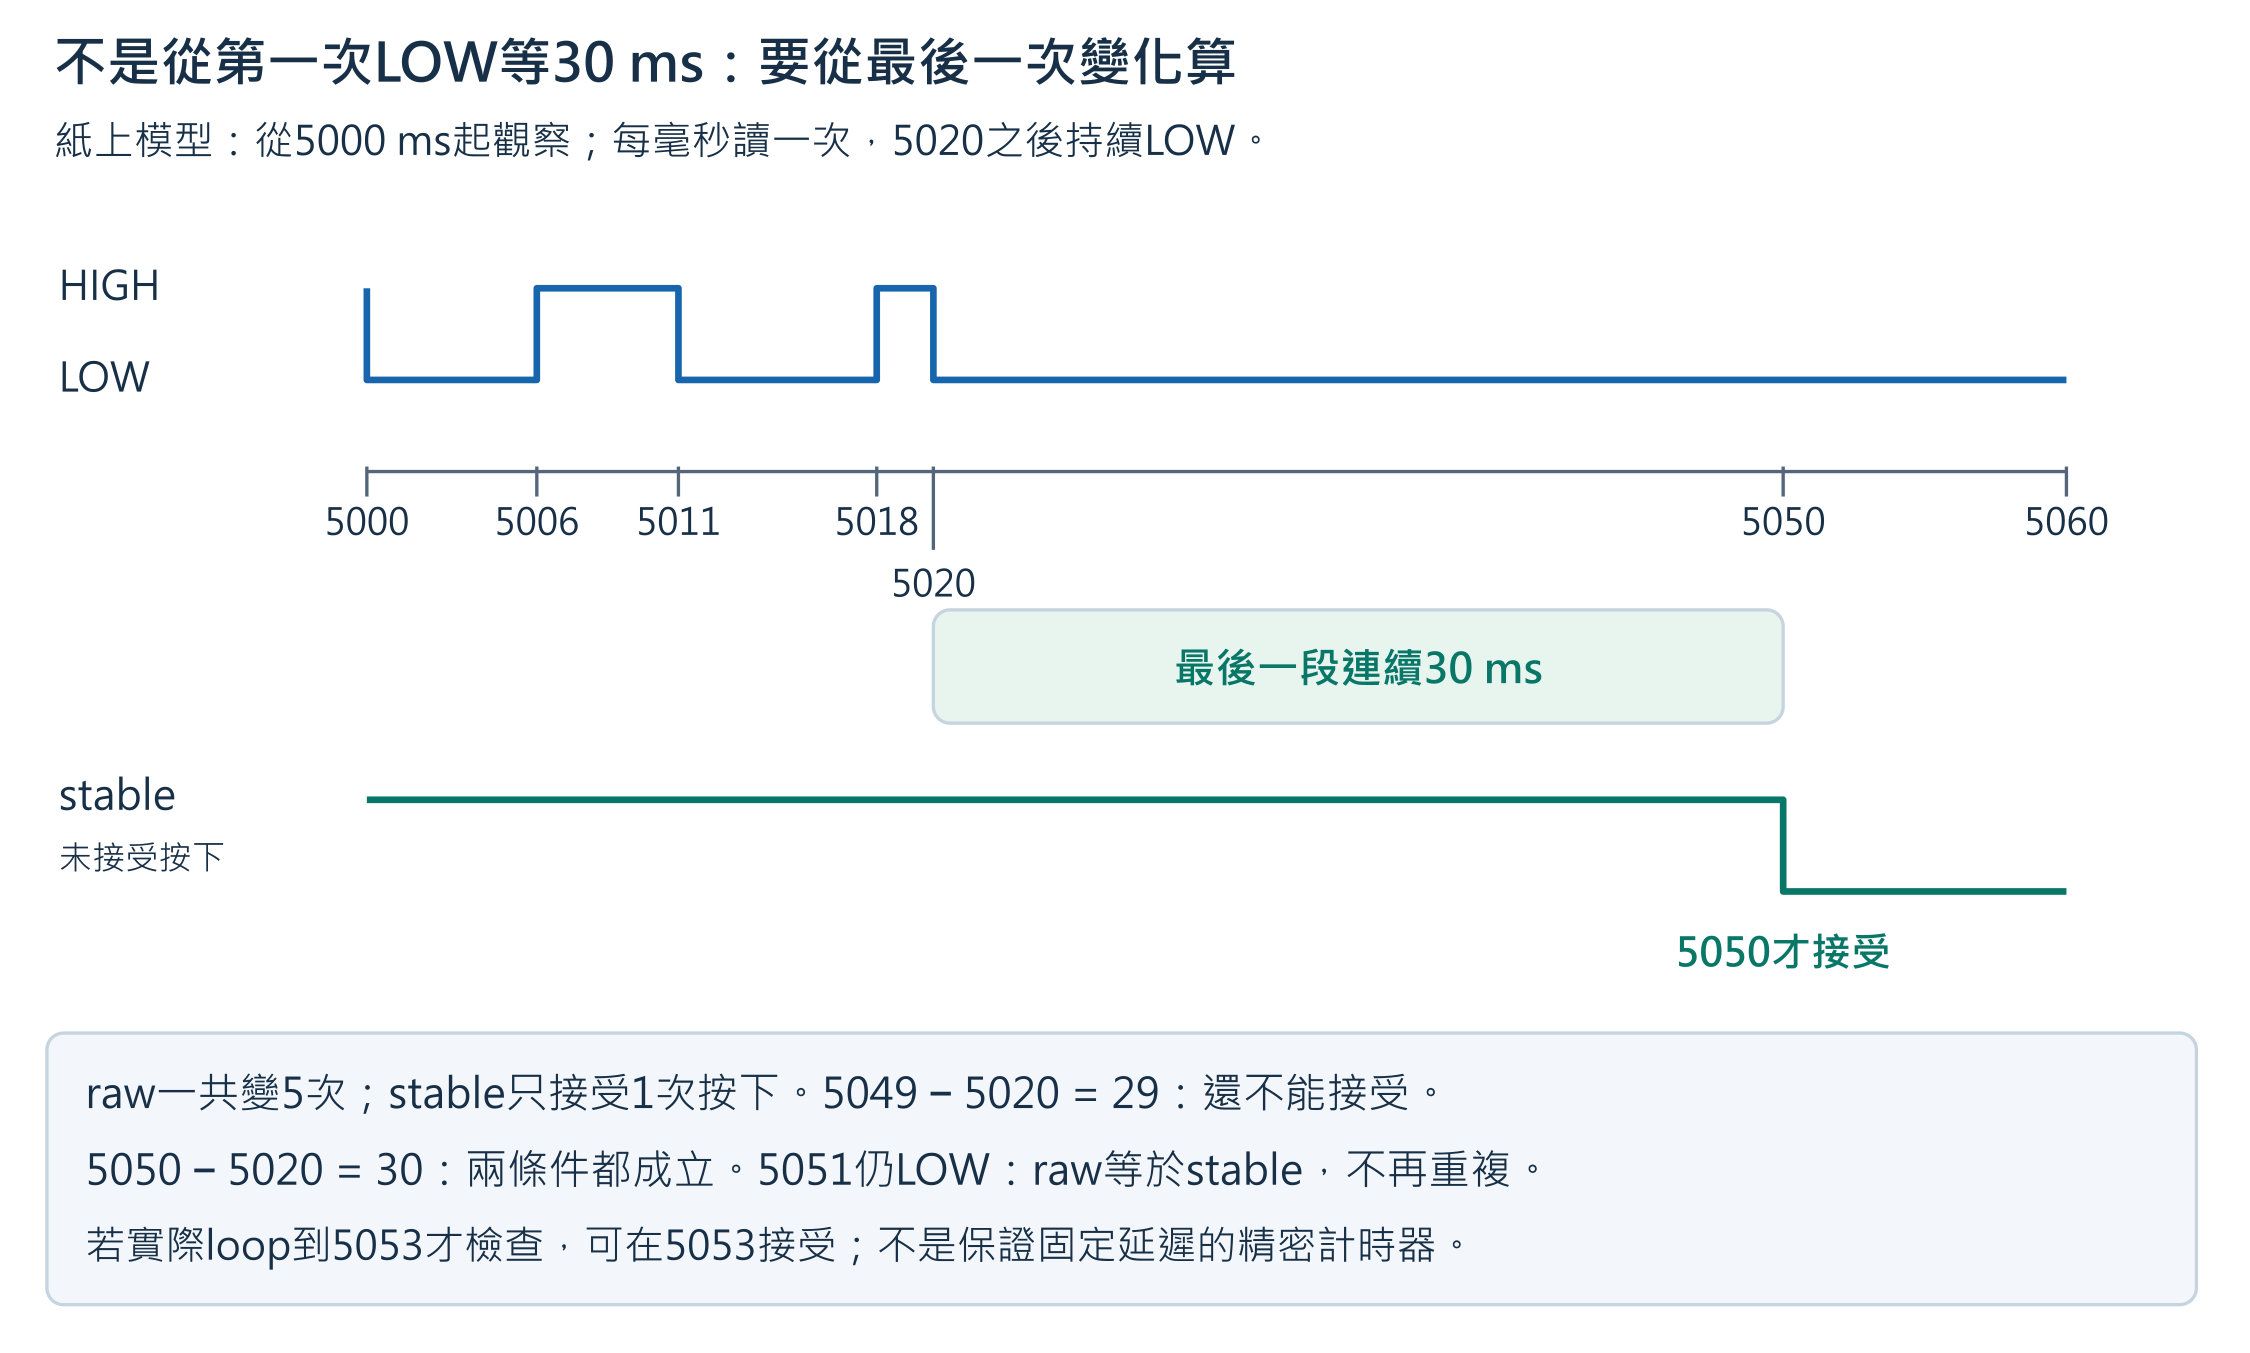

三個答案為：**最早5050 ms；raw改變5次；stable只接受1次按下**。
不是5030 ms，因為不能從第一次5000算完就忽略後面的反彈；也不是把幾段LOW的
時間相加湊30 ms。程式要求「最後一段連續未觀察到變化」。

5050是符合條件的最早時刻，不保證每台板正好在該毫秒印出。若程式到5053才再次
輪詢，接受時間可以是5053且`stable_for_ms=33`。接點在兩次讀取間是否曾變化，
這份log無法知道，所以不能把stable文字說成示波器證明的完全平滑波形。

### 10.8 練習二預期答案：逐行連回狀態與計數

以下為指定輸入下的**模擬教學log**，group用SIM、每毫秒輪詢一次、忽略列印延遲，
不是BOARD-T01的新實測。起始放開；1000 LOW、1003 HIGH、1008 LOW，至2000才放開。

```text
group=SIM event=raw_changed raw_pressed=true raw_edge=1 time_ms=1000
group=SIM event=raw_changed raw_pressed=false raw_edge=2 time_ms=1003
group=SIM event=raw_changed raw_pressed=true raw_edge=3 time_ms=1008
group=SIM event=stable_changed pressed=true input=LOW test_output=HIGH accepted_press=1 accepted_release=0 stable_for_ms=30 debounce_ms=30 time_ms=1038
group=SIM event=raw_changed raw_pressed=false raw_edge=4 time_ms=2000
group=SIM event=stable_changed pressed=false input=HIGH test_output=LOW accepted_press=1 accepted_release=1 stable_for_ms=30 debounce_ms=30 time_ms=2030
```

逐行解析：

1. 1000：立即讀到按下，但還不改輸出；raw_edge增至1。
2. 1003：又讀到放開，等待時間重設。stable仍是放開，所以不增加accepted_release。
3. 1008：再讀到按下，等待從1008重新開始。
4. 1038：接受一次按下；accepted_press為1，並命令輸出HIGH。不是把前三筆raw算三次按下。
5. 2000：讀到放開，但stable仍保持按下；輸出也暫時仍是HIGH。
6. 2030：放開已穩定30 ms，接受一次release，輸出才回LOW。

因此這次一按一放有**4個raw邊緣、1次接受按下、1次接受放開**。
`raw_edge=4`不是按了4次，`accepted_release=0`出現在按下那行也不是漏失；要等完整放開。
`input=LOW`在stable行是已接受狀態的文字表示，不是ADC值或電表電壓。

**自己的實驗沒有唯一數字答案**。可接受的判讀至少分清：

| 原始證據 | 可以寫的預期回答 | 不能直接寫 |
|---|---|---|
| 每次只有兩筆raw，一press一release | 這次輪詢沒有觀察到額外邊緣 | 按鈕永遠不會彈跳 |
| 同次按下有多筆交替raw，stable只有一press | 去抖在這次觀察中未接受短暫反轉 | 所有多餘變化都已證明來自機械接點 |
| raw有短暫true但沒有stable press | 可能未持續到門檻，需查時間及下一筆raw | 板子一定壞了 |
| 原始log只剩最後兩行 | 證據不足；保留現有資料並標記缺口 | 補寫未保存的事件當成原始log |
| 計數剛好10／10 | 總數相符；再逐次比對是否一進一出 | 已證明毫無多算或漏失 |

若沒有觀察到反彈，不需要摔按鈕、刮接點、晃線、改供電或帶電拔線來「產生正確答案」。
可以用紙上資料分析機制，實測欄忠實記錄未觀察到。

### 10.9 練習三預期答案：等待時間的取捨

#### A. 事前預測怎麼寫

預測表不要求猜中固定計數。合理回答會寫成**有條件的預測**：

| 設定 | 參考預測與理由 |
|---:|---|
| 0 ms | 若輪詢讀到反彈，可能多接受；若沒讀到反彈，也可能剛好10／10。沒有額外時間篩選。 |
| 10 ms | 短於10 ms的新狀態可能被忽略；若反轉穩定超過門檻，仍可能被接受。 |
| 30 ms | 相對10 ms等待更長；可能避免某些誤判，也可能漏掉很短的點按。不可保證最好。 |
| 100 ms | 新狀態需維持至少100 ms；短按或兩次按壓中很短的放開間隙可能被合併或漏掉。 |

改DEBOUNCE_MS不會讓機械接點比較少彈跳；它改的是接受規則。真人每輪按法不可能
完全相同，且接受事件多寡會影響Serial工作量，因此實機的raw_edge也不保證四輪完全相同。

#### B. 同一組輸入，四種規則會接受什麼

為了單獨比較演算法，先固定理想輸入：1000 LOW → 1003 HIGH → 1008 LOW →
1200 HIGH；接著1400 LOW → 1450 HIGH（第二次只維持50 ms）。初始放開，每毫秒
輪詢一次，所有變化都被看見，不模擬接觸噪聲以外的電路或Serial耗時。

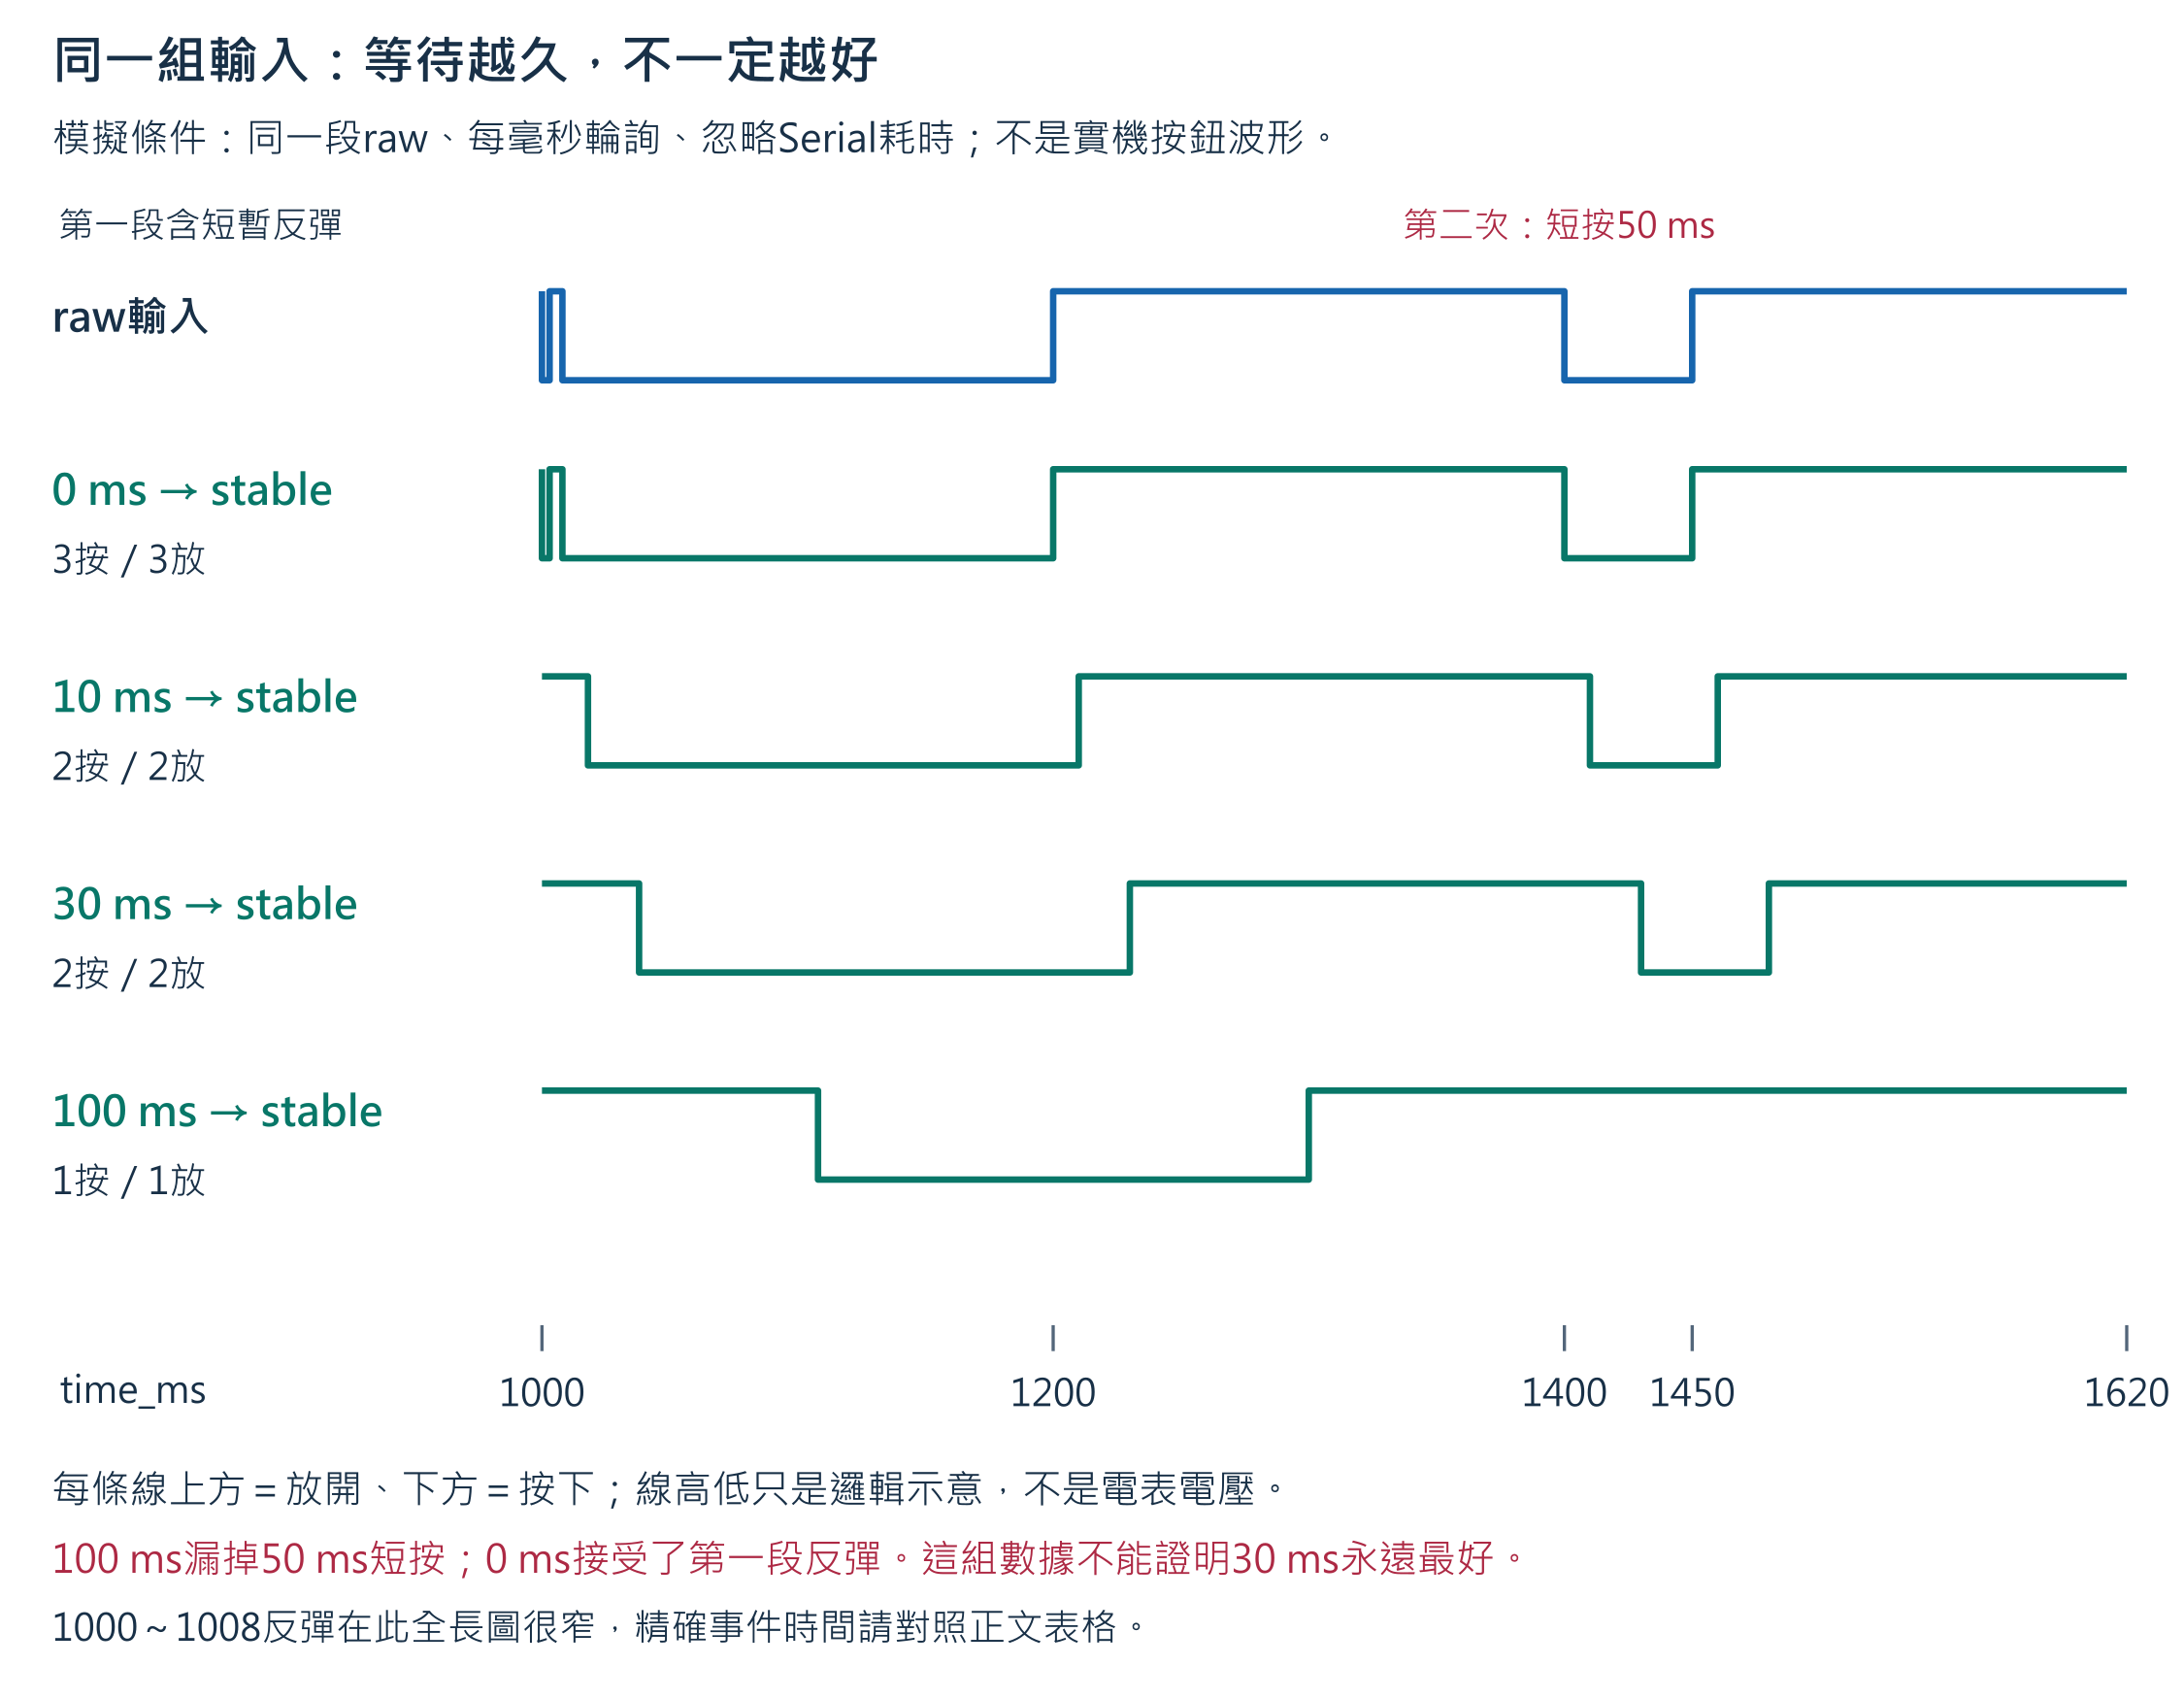

| 設定 | 接受按下的時間ms | 接受放開的時間ms | 結論只限這段指定輸入 |
|---:|---|---|---|
| 0 | 1000、1008、1400 | 1003、1200、1450 | 3／3；第一個實體按下被當成兩次 |
| 10 | 1018、1410 | 1210、1460 | 2／2；兩次都接受 |
| 30 | 1038、1430 | 1230、1480 | 2／2；比10 ms更晚接受 |
| 100 | 1108 | 1300 | 1／1；1400～1450的50 ms短按未被接受 |

100 ms不是因為「數字太大把板子弄壞」，而是在1500 ms門檻到達前，raw已於1450回HIGH。
此時stable本來就是放開，因此既不產生第二次press，也不額外產生一次release。
相反地，10與30在這組條件都接受兩次，但不代表換按鈕、換按法仍一樣。

**放開也要去抖**：假設stable已按下，raw在2000放開、2050又按下；使用100 ms時，
50 ms的放開間隙尚未被接受。兩段按壓可能被程式視為一次長按。
這是同一規則的推論，不要求額外做第四項實驗。

#### C. 延遲怎麼算，計數怎麼判讀

`stable_for_ms` = 接受時刻 − 最後一次raw改變時刻，不等於從手指最早碰到按鈕
開始的全部反應時間。上例30 ms的首次LOW在1000，最後反彈在1008，接受在1038：
從首次LOW算是38 ms，log的穩定等待仍是30 ms。放開的等待也可能讓輸出晚回LOW；
這個教學按鈕與去抖程式不是經驗證的緊急停止裝置。

例如實際按10次，某一次多算1次、另一次漏掉1次，最後仍可能是10。
因此先依慢／快段落與操作記錄查每次raw/stable，再看總數。不要只用
`accepted_press == 10`當成完全正確，也不要用raw_edge ÷ 2當成手按次數。

#### D. 結論範例與不能捏造的欄位

以下是假設實測支持時的**寫作例子，不是給你照填的實測答案**：

> 我暫選30 ms。本輪10次操作接受10次按下及10次放開，逐次log未看到額外stable事件；
> 100 ms那輪有一筆raw短按未達門檻。30 ms在本次操作中兼顧了短按辨識與反彈過濾。
> 但只測同一按鈕、同一操作者；人工快按時間與Serial輪詢有誤差，不能推廣成所有按鈕最佳值。

若四種設定都符合，可寫「本次證據不足以只用計數選出唯一最佳值，先保留課程30 ms
基準；等待長短的代價由時間條件分析，並在改硬體或程式後再測」。若沒有實測，寫
「尚未執行；以上僅為預測／模擬」。未保存的raw_edge、計數、時間與波形不能用本節
例子補填；也不能把選10、30或其他有證據支持的設定直接判成錯。

### 10.10 課中判讀的預期回答

這些答案回扣前面的閱讀與操作，不新增一套必做作業。

| 課中問題 | 預期回答與解釋 |
|---|---|
| 只Verify新版，再RST會得到version=2嗎？ | 不會；沒有Upload，新版仍只在電腦。RST重啟Flash原有程式。還需確認自己看的Port是目標板。 |
| 8%或9%是整顆Flash占用率嗎？6%是所有RAM嗎？ | 前者相對應用分割區Maximum，後者是編譯時靜態RAM配置摘要；都不能直接當成全部硬體容量與執行峰值。 |
| N16R8但psram_bytes=0，一定買錯？ | 不一定，先核對實物與PSRAM設定、重新編譯Upload的版本；0只表示該次程式沒有識別可用PSRAM。 |
| GPIO4為LOW但pressed=true，矛盾嗎？ | 不矛盾，true回答的是「有沒有按下」；本接法按下連GND所以LOW。 |
| 接上USB後GPIO4／5都自動有3.3V？ | 不是。USB供電，晶片執行程式才設定GPIO模式；輸入由上拉與按鈕共同決定，輸出由程式命令決定。 |
| 為何一條板上GND還要b22接a29？ | 第一條建立第22列TPG，第二條把同一GND送到第29列按鈕，並非用了兩個不同地。 |
| GND不用接也可以嗎？ | 少了按鈕返回GND的路徑，按下不能依設計把輸入拉低；不等於USB供電的整板都沒電。 |
| b22接a29改成b29可不可以？ | 可以，a29～e29同節點；改到a28不等效。所有實際改線仍先斷電。 |
| 空板a10對f10不響，插按鈕後a27對j27卻響？ | 空板跨槽獨立；已核對方向的按鈕內部同組接點跨過槽，條件不同，並不矛盾。 |
| 按鈕未按就響，一定壞了？ | 先查是否選到內部同一組或兩表筆直接碰到。保持斷電，用跨組測點再看放開／按下／放開。 |
| 蜂鳴代表短路？沒聲音代表安全？ | 都不能一概而論。導線同節點應響；應隔離的TPO／TPG持續響才是警訊。不響也不能證明無其他錯接。 |
| 紅藍軌的+與−會自己產生電？ | 不會，只是標籤；實際接到什麼才決定電位，本週不供電到電源軌。 |
| 200是電阻值嗎？10A是10V嗎？ | 200是所選功能的量程；須連同Ω或V等符號看。A是電流單位，V是電壓，10A孔本週不使用。 |
| 只說「0.6」能知道電阻嗎？ | 不能。若Ω 200、尖端穩定短接、畫面0.6，才可讀為0.6 Ω；檔位或完整畫面缺失時不補單位。 |
| 電阻兩端3.0 V、1 kΩ，電流也是3.0嗎？ | 先換成1000 Ω，I＝3.0÷1000＝0.003 A＝3 mA。3.0 V是兩端電壓差，3 mA是計算電流；不是同一種量，也不是電表V檔量到了電流。 |
| 上拉電阻從哪裡來？為何不是短路？ | INPUT_PULLUP啟用晶片內部上拉；按下時有電阻限制支路電流，不是3V3直接接GND。 |
| 兩筆事件差182 ms就是手按182 ms？ | 只能說接受事件相差0.182秒；去抖與輪詢會影響時間，不是精確機械接觸時間。 |

照片、版本、profile、真實量測及原始log沒有全班統一答案。應填自己的資料；缺少就
標「未取得／未驗證」，不能以參考答案代替實作證據。


<a id="w2-records"></a>

## 十一、實驗紀錄與繳交內容

每組保存硬體照片與共同原始log；每位學生仍須完成自己的判讀與結論：

1. Arduino IDE版本、Espressif`esp32` package、Board、Port、Flash與PSRAM設定。
2. `version=2`的Serial畫面，以及Verify、Upload、Reset各能證明與不能證明什麼。
3. `PIN_BUTTON`、`PIN_TEST_OUTPUT`與GND接線表，以及可辨識腳位的俯視照片。
4. 麵包板同列、跨槽、按鈕未按、按住、再次放開及TPO對TPG的斷電通斷結果。
5. 去抖練習一的時間軸、練習二的raw／stable原始log，以及練習三四種設定的
   預測、結果與最後選擇。
6. 一項結果與預測不同之處；若全部符合，寫出一項目前證據仍不能證明的事情。

不得只交「成功」或沒有接腳標示的照片，也不得刪除不理想事件後重新整理成
看似正確的log。Week 2不繳交KY-018板上電阻或直流電壓數字，這些由Week 3接續。


<a id="w2-finish"></a>

## 十二、完成檢核與器材復原

- [ ] 每位學生都實際操作過萬用電表；共用電表的1人組仍保存自己的量測紀錄。
- [ ] 能依「檔位、測點、完整數字、單位、判讀」說明一筆電表紀錄，不單憑數字或蜂鳴判定。
- [ ] 能選擇正確Board與Port，完成Verify、Upload、115200-baud Serial及Reset。
- [ ] 麵包板與按鈕的斷電通斷結果符合實際結構，TPO與TPG沒有低阻抗短接。
- [ ] GPIO接線可追溯到教師公布的profile，五次按下／放開事件順序正確。
- [ ] 能說明接點彈跳、raw讀值、stable狀態及去抖時間。
- [ ] Discussion的紙上追蹤有理由，實測保留原始log，設定比較有預測、判讀與結論限制。
- [ ] 能指出Serial輸出命令不能代替GPIO電壓實測。
- [ ] Serial Monitor已關閉，USB已拔除，萬用電表已轉到`OFF`。
- [ ] 按鈕與杜邦線已清點，開發板沒有彎針，桌面已復原。

全部完成後可依課程規定提前離開。KY-018板上電阻、3V3、5Vin外部輸入辨識、GPIO LOW／HIGH與Reset
後啟動命令及安全限制由Week 3接續，不列為Week 2未完成。

<a id="w2-further"></a>

## 十三、補充閱讀：電學推理與板卡參數

本節是同一份教材內的深入解釋，不增加Week 2量測、Discussion題數或繳交項目。
第七節已用1 kΩ與3.0 V示範如何找已知、選公式及換單位；本節將同一方法
套回內部上拉與短路模型。需要複習基本計算時，回到[第七節的逐步例子](#w2-ohms-example)。

### 回到本週：內部上拉為什麼不會直接短路

只為理解數量級，假設內部上拉是45 kΩ，按住時GPIO接近GND：
3.3 V÷45000 Ω≈0.000073 A≈0.073 mA。這是近似模型，不是本顆晶片上拉阻值
或全板耗電的實測。上拉電阻限制這條支路的電流；沒有要求額外接一條3V3線，
也不是電流從GPIO輸入「流過程式」再變成另一支GPIO的輸出。
[Espressif內部上拉說明](https://docs.espressif.com/projects/arduino-esp32/en/latest/api/gpio.html)
提供功能依據，實際阻值及輸入特性仍依晶片規格。

### 電流方向、回程與發熱

傳統電流在電源外部的電阻負載中，由較高電位流向較低電位；板上供電電路
維持這個差異。GND是共同參考與回程，不是讓電流消失的洞。按鈕回程斷開，
只會使這條支路無法持續通流，不代表USB供電的整片ESP32都沒有電流。

電流不是越大越好或越小越好，而要符合元件需求與可承受範圍。
若用普通導線直接連3V3與GND，就繞過原本的負載，形成低阻抗短路。
例如假設整條捷徑0.1 Ω，理想式會得到3.3÷0.1＝33 A；**這不是板子實際能提供的
電流，更不是實驗指令**。實物會受電源、導線與保護限制，仍可能掉電、發熱或損壞。

若想了解「為什麼線也會熱」，功率P的單位是W（瓦特），表示每秒轉換多少能量；
電阻發熱可寫成P＝I²R。在同一接點電阻下，電流變2倍，發熱功率變4倍。
因此導線雖然電阻小，也不能任意通過大電流。這段是補充原因，不要求本週計算功率。

「電源額定可提供3 A」是供應能力，不表示會強迫3 A流進任何設備。
也不是每個設備都必須外加一顆電阻：不同負載需要各自合格的供電與驅動方式。
本課GPIO只作訊號，不能直接給馬達或舵機供電。

<a id="w2-board-details"></a>

### 從整塊板子讀到晶片參數

PCB像房子的底板與走線，模組像已組好的房間，晶片才是其中執行指令的核心。
對照[第四節的板卡辨識圖](#w2-install)：CH343負責通訊轉接，穩壓器處理供電；它們不會
替GPIO執行按鈕程式。不要把金屬罩拆開來找晶片，也不由外觀猜元件耐壓。

以下是BOARD-T01先前執行board-check的文字回報，不是每支程式都會自動出現：

| 欄位與已回報值 | 白話解釋 | 不能據此推論 |
|---|---|---|
| `chip_model=ESP32-S3` | 程式查詢到的晶片家族 | 整片PCB就是Espressif原廠DevKitC-1 |
| `chip_revision=2` | 晶片硬體修訂代碼 | Arduino IDE版本是2，或CPU有兩顆 |
| `cpu_mhz=240` | CPU時脈為240 MHz，即每秒約2.4億個時脈週期 | 每秒能執行2.4億次完整loop或Serial列印 |
| `flash_bytes=16777216` | 偵測到16 × 1024 × 1024 bytes的Flash容量 | 本支sketch能用完這些空間 |
| `psram_bytes=8388608` | 此次啟動識別到8 × 1024 × 1024 bytes的PSRAM | 所有變數已放進PSRAM，或全部容量都還空著 |
| `status=running` | 程式走到這行，主動印出running | 每支GPIO、感測器與接線都測試通過 |
| `uptime_ms=1018` | 本次啟動後約1.018秒 | 現在的日期時間或累積上課時間 |

這些byte值按二進位換算，嚴格寫法是16 MiB、8 MiB；板卡型號與IDE選單慣用
16 MB、8 MB。別把大寫B（byte）與小寫b（bit）混用：1 byte = 8 bits。

同一片T01曾在PSRAM選成Disabled時回報0，改成OPI PSRAM並重新Upload後回報
8388608。這支持「當時的初始化設定影響辨識」，不表示看到0就一定缺少實體晶片。
需辨認時可在**只接USB、沒有外接線**的狀態使用
[完整board-check程式](../examples/week02_board_check/week02_board_check.ino)，
依第五、六節的Board／Upload／Monitor流程執行；已有紀錄可直接判讀，不必重做。
本週共同第一支程式仍是[第六節的組別與版本測試](#w2-serial)，參數查詢不另列必做實驗。

## 參考資料

- [Arduino IDE官方下載](https://www.arduino.cc/en/software)
- [Arduino官方Debounce範例](https://docs.arduino.cc/built-in-examples/digital/Debounce/)
- [ESP32-S3-WROOM-1資料表](https://documentation.espressif.com/esp32-s3-wroom-1_wroom-1u_datasheet_en.pdf)
- [Arduino-ESP32 Tools Menu](https://docs.espressif.com/projects/arduino-esp32/en/latest/guides/tools_menu.html)
